# Social Survey 2024 

**Project context:** Financial vulnerability risk scoring based on the Israeli Social Survey financial module.

**Notebook owner:** Data ingestion, data cleaning, missing-value audit, initial feature organization, and descriptive statistics.

This notebook intentionally **does not perform scaling** and **does not fit any imputation/scaling object before the train/test split**. The goal is to prepare a clean, transparent analysis table for the modeling team while avoiding data leakage.


## Main environment and imports

Merged setup block for the whole notebook. Runs the same way on Google Colab and on local Jupyter: detects the environment, prints package versions for a clear paper-trail, and auto-installs missing packages on Colab. Each of the three parts still has its own specialized import cell below - this one is the shared baseline.


In [1]:
# ============================================================
# Main environment check + unified imports (all three parts)
# ============================================================
import sys
import importlib

print(f"Python {sys.version.split()[0]}")
print(f"Platform: {sys.platform}")

# Colab vs local detection - no code differences elsewhere
try:
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
    print("Environment: Google Colab")
except ImportError:
    IN_COLAB = False
    print("Environment: local Jupyter")

# One-line functional description per package (what it does + why we use it).
REQUIRED = [
    ("numpy",      "numerical arrays"),
    ("pandas",     "dataframes for reading and reshaping the survey data"),
    ("matplotlib", "static plotting engine used across the notebook"),
    ("seaborn",    "statistical charts on top of matplotlib for EDA"),
    ("scipy",      "scientific and statistical functions used during EDA"),
    ("sklearn",    "machine learning models and pipelines used to predict financial risk"),
    ("openpyxl",   "reads Excel .xlsx files (survey data + codebook)"),
    ("phik",       "correlation coefficient across mixed variable types"),
    ("shap",       "feature-importance values that explain model predictions"),
    ("tabulate",   "pretty-print comparison tables in notebook output"),
    ("joblib",     "saves and loads the trained model between notebook parts"),
    ("plotly",     "interactive charts rendered inside the dashboard"),
    ("folium",     "interactive map of Israel rendered inside the dashboard"),
    ("wordcloud",  "generates the financial-terms word cloud in the dashboard"),
    ("PIL",        "image processing used by wordcloud"),
]
OPTIONAL = [
    ("pyarrow",    "fast parquet cache that speeds up re-runs"),
]

print()
print("Package versions:")
missing = []
for pkg, desc in REQUIRED + OPTIONAL:
    is_optional = any(p == pkg for p, _ in OPTIONAL)
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, "__version__", "installed")
        opt_tag = " (optional)" if is_optional else ""
        print(f"  {pkg:<12} {version:<10} - {desc}{opt_tag}")
    except ImportError:
        if not is_optional:
            missing.append(pkg)
            print(f"  {pkg:<12} MISSING    - {desc} (required)")
        else:
            print(f"  {pkg:<12} not present - {desc} (optional)")

if missing:
    print(f"\nInstalling missing packages: {' '.join(missing)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("Installed. Re-run this cell so the newly installed packages import.")

# ------------------------------------------------------------
# Common downstream imports (specialised imports live in each part)
# ------------------------------------------------------------
import os
import io
import json
import base64
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

print("\nMain environment ready.")


Python 3.13.9
Platform: win32
Environment: local Jupyter

Package versions:
  numpy        2.3.5      - numerical arrays
  pandas       2.3.3      - dataframes for reading and reshaping the survey data
  matplotlib   3.10.6     - static plotting engine used across the notebook
  seaborn      0.13.2     - statistical charts on top of matplotlib for EDA
  scipy        1.16.3     - scientific and statistical functions used during EDA
  sklearn      1.5.2      - machine learning models and pipelines used to predict financial risk
  openpyxl     3.1.5      - reads Excel .xlsx files (survey data + codebook)
  phik         0.12.5     - correlation coefficient across mixed variable types
  shap         0.51.0     - feature-importance values that explain model predictions
  tabulate     0.9.0      - pretty-print comparison tables in notebook output
  joblib       1.3.2      - saves and loads the trained model between notebook parts
  plotly       6.3.0      - interactive charts rendered inside 

### Colab-only: input files (added for the merged-notebook build)

On Google Colab the notebook starts with an empty `/content/` directory. The two CBS files (`data_24.xlsx` and `H20241501codebook.xlsx`) must be present before Shai's Part 1 tries to load them.

This cell is a no-op on local Jupyter; on Colab it prompts for an upload the first time only.

In [2]:
# ============================================================
# Colab-only: ensure input files are available
# ------------------------------------------------------------
# On local Jupyter this cell is a no-op. On Colab it prompts
# for an upload of the two CBS files if they are not already
# present in the working directory. Handoff files created later
# by Shai/Ovad/Or (model data.csv, xgb_model.pkl, index.html)
# live in /content/ and persist inside the current Colab session.
# ============================================================
import os

_REQUIRED_INPUT_FILES = ["data_24.xlsx", "H20241501codebook.xlsx"]

if IN_COLAB:
    _missing = [f for f in _REQUIRED_INPUT_FILES if not os.path.exists(f)]
    if _missing:
        print(f"Missing input files on Colab: {_missing}")
        print("Please pick both files in the upload dialog below (multi-select allowed):")
        from google.colab import files
        _uploaded = files.upload()
        _still_missing = [f for f in _REQUIRED_INPUT_FILES if not os.path.exists(f)]
        if _still_missing:
            raise FileNotFoundError(
                f"Still missing after upload: {_still_missing}. "
                "Re-run this cell and select the missing files."
            )
        print(f"Uploaded: {list(_uploaded.keys())}")
    else:
        print("Input files already present in /content/:")
        for _f in _REQUIRED_INPUT_FILES:
            print(f"  {_f}  ({os.path.getsize(_f) / 1024:.1f} KB)")
else:
    print("Local run - Colab upload prompt skipped.")


Local run - Colab upload prompt skipped.


# Part 1 - EDA and Data Preparation (Shai)

Loads the raw Social Survey, cleans it, builds the financial risk target, and produces the `model_data` DataFrame that Part 2 consumes.

## 0. Working principles

1. Keep the raw file unchanged.
2. Convert survey-specific non-response codes such as `888888` and `999999` into real missing values (`NaN`).
3. Document missingness instead of silently deleting many rows.
4. Do not scale here. Scaling belongs inside the modeling pipeline after the train/test split.
5. Any imputation used for modeling should be fitted on the training set only. In this notebook we mainly audit missing values and create clear feature groups.


In [3]:
# Core imports
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

print("import successful!")

import successful!


## 1. Load data

For Git-based work, keep the data path relative to the repository. A common structure is:

```text
project_root/
├── data/
│   ├── raw/
│   │   └── data_24.xlsx
│   └── processed/
├── notebooks/
└── src/
```

Update `DATA_PATH` if your repository uses a different folder structure.


In [4]:
# Load the Social Survey dataset
raw = pd.read_excel("data_24.xlsx", sheet_name="data_24")

print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")

raw.head()


Rows: 6,907
Columns: 324


,SerialNumber,Shana,SemelEretz,SemelEretzAv_C,SemelEretzEm_C,ShnatAliya,MatzavMishp,VetekMatzavMishpN,VetekMatzavMishpG,VetekMatzavMishpA,All_School,High_School,Matriculation_Certificate,Post_Secondary,Ba,Ma,Phd,Kids_0_5,Kids_6_17,over_18,Bnei20plus,Kids_0_17,BenZug,SugMeshekBait_C,BenZugOved,Minn,Gil,PeamimNasuy,ms_nefashot,HesderDiyur,GoremMaskirDira,MispChadarim,DiraNosefetBaalut,DiraBaalut,Mechonit,MechonitBashana,Ozeret,OzeretShaot,OzeretTaasuka,OzeretTashlumAtem,OzeretTashlumMosad,OzeretTashlumAcher,VetekYishuv,MerutzeEzor,MerutzeTachbura,MerutzeEzorParkim,MerutzeEzorNikayon,MerutzeEzorAshpa,MafriaZihum,MargishBatuach,HanayaMaspik,MerutzeKvishim,VetekDira,MerutzeDira,MafriaRaash,MerutzeSchenim,SchenimMeshaper,EzorEmunArnak,MatzavBriut,BeayaBriut,...,HashpaaYoetz,HashpaaHamlatza,HashpaaHamlatzaZar,HashpaaPirsum,HashpaaTikshoret,HashpaaAcher,InternetHalvaa,InternetMeida,InternetDohAshrai,InternetShilemMatbeaDig,InternetDohPensia,MerutzeKalkali1_5,KisuyHotzaot1_5,YedaHashkaa,SikunHashkaot,LoHosech,HeshbonotBazman,MatzavMagbil,MatarotKaspiot,ShokelKniot,NisharKesef,HishuvInflation,HishuvRibit100_C,HishuvRibitShana_C,HishuvRibit5Shanim,BituyTsua,BituyInflation,BituyShukHahon,zurat_yishuv,machoz,nafa,pop_group,MechonitReshut_C,Mechonitbaalut_C,MatzavTaasukaM_C,Zurat_YishuvAvoda_C_wp,MispMekomot_C,HekefMisra_C_wp,DiraBaalut_C,Earners,YelidBrham,TzfifutDiyurM,hachnasa_lenefesh,PaamAchronachashavani_C,Mugbalim,AflayaM,MichyaPensyaAtid,MichyaGemelAtid,MichyaKitzbaAtid,MichyaMechiratNechesAtid,MichyaMechiratFinanceAtid,MichyaHachnasaMinechesAtid,MichyaMishpachaAtid,MichyaYerushaAtid,MichyaAvodaAtid,MichyaAcherAtid,nn,age_r,DatiutLoYehudi_r,haredi
0,1,24,1,4,2,999999,4,999999,999999,2,0,0,2,0,0,1,0,2,1,1,2,1,2,3,999999,1,7,1,4,1,999999,5,2,999999,1,999999,2,999999,999999,999999,999999,999999,5,1,4,2,4,4,3,1,1,1,4,1,4,1,2,1,1,2,...,1,2,2,2,1,2,2,1,2,2,1,1,5,1,1,5,5,1,3,3,1,3,0,2,1,1,1,1,14,4,44,1,2,2,1,999999,1,2,1,2,2,1,888888,4,2,2,1,2,1,2,2,2,2,1,1,2,1175.182179,4,NaN,0.0
1,2,24,1,2,2,999999,1,3,999999,999999,0,1,1,0,0,0,0,1,1,2,2,1,1,3,1,1,3,1,6,2,1,3,999999,1,2,2,2,999999,999999,999999,999999,999999,2,1,2,2,2,1,4,1,1,2,2,1,4,1,1,1,1,2,...,2,1,2,2,1,2,2,1,1,2,1,1,5,5,4,5,1,4,1,1,4,3,0,888888,888888,2,1,888888,1,1,11,1,0,0,3,999999,999999,999999,1,1,2,3,1,4,2,1,2,2,2,2,2,2,1,2,999999,2,2878.604304,2,NaN,1.0
2,3,24,1,3,3,999999,1,4,999999,999999,0,0,2,0,0,0,0,2,2,2,2,2,1,3,2,2,10,1,2,1,999999,5,2,999999,1,999999,1,1,1,1,2,2,5,1,5,1,1,1,3,2,3,1,5,1,2,2,888888,1,2,1,...,2,2,2,2,2,2,2,1,2,2,2,1,5,1,3,3,1,5,5,1,1,888888,0,3,1,1,1,1,16,3,31,1,2,2,3,999999,999999,999999,1,0,2,1,3,4,2,2,999999,999999,999999,999999,999999,999999,999999,999999,999999,999999,854.245090,6,NaN,0.0
3,4,24,3,999999,999999,7,1,4,999999,999999,0,0,0,0,1,1,0,2,2,2,2,2,1,3,1,1,8,1,2,2,1,3,999999,1,1,999999,2,999999,999999,999999,999999,999999,5,1,1,1,1,1,4,2,1,2,3,2,4,2,4,2,2,2,...,1,2,2,2,1,2,2,2,1,2,1,2,5,3,5,5,1,1,2,1,1,3,0,2,1,1,1,888888,15,5,51,1,1,0,1,888888,1,2,1,2,1,1,3,4,2,2,1,1,1,2,2,2,1,2,1,2,1000.984314,5,NaN,0.0
4,5,24,1,1,1,999999,5,999999,999999,999999,0,1,0,0,0,0,0,2,2,2,1,2,2,1,999999,1,2,999999,1,2,3,2,999999,2,2,2,2,999999,999999,999999,999999,999999,1,2,2,2,2,2,4,2,1,2,1,2,4,888888,888888,888888,1,2,...,2,2,2,2,2,2,2,2,2,2,2,5,1,5,5,5,2,2,3,1,4,3,0,888888,888888,888888,888888,888888,15,6,62,2,0,0,1,15,1,2,2,1,2,1,3,1,2,1,2,2,1,888888,2,888888,888888,888888,888888,2,911.110576,2,0.0,NaN


## 2. Initial structure checks

These checks help us understand the dataset before changing anything.


In [5]:
structure_summary = pd.DataFrame({
    "column": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "n_unique": raw.nunique(dropna=False).values,
    "missing_before_cleaning": raw.isna().sum().values,
    "missing_before_cleaning_pct": raw.isna().mean().round(4).values
})

structure_summary.head(20)


,column,dtype,n_unique,missing_before_cleaning,missing_before_cleaning_pct
0,SerialNumber,int64,6907,0,0.0
1,Shana,int64,1,0,0.0
2,SemelEretz,int64,4,0,0.0
3,SemelEretzAv_C,int64,6,0,0.0
4,SemelEretzEm_C,int64,6,0,0.0
5,ShnatAliya,int64,9,0,0.0
6,MatzavMishp,int64,5,0,0.0
7,VetekMatzavMishpN,int64,6,0,0.0
8,VetekMatzavMishpG,int64,6,0,0.0
9,VetekMatzavMishpA,int64,6,0,0.0


In [6]:
print("Duplicate SerialNumber rows:", raw["SerialNumber"].duplicated().sum() if "SerialNumber" in raw.columns else "SerialNumber column not found")
print("Fully duplicated rows:", raw.duplicated().sum())


Duplicate SerialNumber rows: 0
Fully duplicated rows: 0


## 3. Convert survey non-response codes to `NaN`

The dataset uses special numeric codes for missing/non-response categories. In this file, the main codes are:

- `888888` — usually non-response / unknown / refused, depending on the survey codebook.
- `999999` — usually not applicable / skipped, depending on the survey codebook.

Because we do not have the full codebook inside this notebook, we keep a conservative approach: we convert these technical codes to `NaN`, and we preserve a missingness report for transparency.


In [7]:
SPECIAL_MISSING_CODES = [888888, 999999]

df = raw.copy(deep=True)

for code in SPECIAL_MISSING_CODES:
    df = df.mask(df == code, np.nan)
    
missing_after = (
    pd.DataFrame({
        "column": df.columns,
        "dtype_after_cleaning": df.dtypes.astype(str).values,
        "missing_n": df.isna().sum().values,
        "missing_pct": df.isna().mean().round(4).values,
        "n_unique_after_cleaning": df.nunique(dropna=False).values
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

missing_after.head(15)


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning
0,MichyaAvoda,float64,6907,1.0000,1
1,SibaLoZamin,float64,6880,0.9961,6
2,Zminut,float64,6651,0.9629,3
3,Oved35_wp,float64,6599,0.9554,3
4,VetekMatzavMishpA,float64,6592,0.9544,5
5,VetekMatzavMishpG,float64,6336,0.9173,5
6,MeunyanYoterM35,float64,6239,0.9033,3
7,OzeretShaot,float64,6085,0.8810,5
8,OzeretTashlumAcher,float64,6050,0.8759,3
9,OzeretTashlumMosad,float64,6049,0.8758,3


High missing-value percentages were expected for many variables because the Social Survey uses conditional (skip-pattern) questions.

Examples include:
- Year of immigration (asked only to immigrants)
- Landlord information (asked only to renters)
- Employment-related questions (asked only to employed or unemployed respondents)

Therefore, variables were **not removed solely based on their missing-value percentage**. Each variable was evaluated using the official survey codebook.


In [8]:
missing_pct = df.isna().mean()

missing_groups = pd.cut(
    missing_pct,
    bins=[-0.01, 0.05, 0.30, 0.70, 0.99, 1.00],
    labels=[
        "Low missing (0–5%)",
        "Moderate missing (5–30%)",
        "High missing (30–70%)",
        "Very high missing (70–99%)",
        "Fully missing (100%)"
    ],
    include_lowest=True
)

print(missing_groups.value_counts().sort_index())

Low missing (0–5%)            172
Moderate missing (5–30%)       52
High missing (30–70%)          70
Very high missing (70–99%)     28
Fully missing (100%)            2
Name: count, dtype: int64


### Load the Survey Codebook

The survey codebook was loaded to provide metadata for each questionnaire variable, including variable names, question numbers, response categories, and survey-specific notes. This information is used throughout the notebook to identify valid response codes, distinguish structural missing values from true missing data, and guide the construction of derived variables.

### Codebook preprocessing (added by the merged-notebook build)

This one cell reshapes the raw CBS codebook (Hebrew column names, 12 metadata rows on top) into the shape Shai's next cell expects (English aliases such as `field_name`, `variavle_name`). The transformation is idempotent - running it against an already-preprocessed file is a no-op.

In [9]:
# ============================================================
# Codebook preprocessing (added for local end-to-end run)
# ------------------------------------------------------------
# The raw H20241501codebook.xlsx from CBS has:
#   * 12 metadata rows before the actual column headers
#   * Column names in Hebrew
#   * Value labels (code_title) in Hebrew
# This cell (idempotent) reshapes it to what Shai's code expects
# and translates the value labels that show up on plot axes to English.
# ============================================================
import pandas as pd

_codebook_path = 'H20241501codebook.xlsx'

_probe_cols = pd.read_excel(_codebook_path, nrows=0).columns.astype(str).tolist()
_needs_preprocess = 'field_name' not in _probe_cols

if _needs_preprocess:
    _raw = pd.read_excel(_codebook_path, header=12)
    _raw = _raw.rename(columns={
        'שם שדה/ נוסח שאלה': 'field_name',
        'שם משתנה':          'variavle_name',
        'קוד':               'code',
        'מאפיינים':          'code_title',
    })
    _raw.to_excel(_codebook_path, index=False)
    print(f'preprocessed {_codebook_path} -> {list(_raw.columns)}')
else:
    print(f'{_codebook_path} already has English aliases, skipping preprocessing')

# ------------------------------------------------------------
# Hebrew -> English value-label translation.
# Applied to code_title values used as x-axis labels by the EDA plots
# so the plots read cleanly in English. Idempotent.
# ------------------------------------------------------------
_HE2EN = {
    # Age brackets (Gil)
    '20 עד 24': '20 to 24', '25 עד 29': '25 to 29', '30 עד 34': '30 to 34',
    '35 עד 39': '35 to 39', '40 עד 44': '40 to 44', '45 עד 49': '45 to 49',
    '50 עד 54': '50 to 54', '55 עד 59': '55 to 59', '60 עד 64': '60 to 64',
    '65 עד 74': '65 to 74',
    # Gender (Minn)
    'זכר': 'Male', 'נקבה': 'Female',
    # Marital (MatzavMishp)
    'נשוי': 'Married', 'נשוי ': 'Married',
    'חי  בנפרד': 'Separated', 'חי בנפרד': 'Separated',
    'גרוש': 'Divorced', 'גרוש ': 'Divorced',
    'אלמן': 'Widowed', 'רווק': 'Single',
    # Household type (SugMeshekBait_C)
    'אדם בודד': 'Single person',
    'משק בית לא משפחתי עם יותר מאדם אחד': 'Non-family household (2+)',
    'משק בית משפחתי': 'Family household',
    'משק בית משפחתי עם אחרים': 'Family household with others',
    # Satisfaction (MerutzeKalkali, MerutzeChaim)
    'מרוצה מאוד': 'Very satisfied', 'מרוצה': 'Satisfied',
    'לא כל כך מרוצה': 'Somewhat unsatisfied', 'בכלל לא מרוצה': 'Not at all satisfied',
    # Work income brackets (HachnasaAvoda)
    'עד 2,000 ש"ח': 'Up to 2,000 NIS',
    '2,001 עד 3,000 ש"ח': '2,001-3,000 NIS',
    '3,001 עד 4,000 ש"ח': '3,001-4,000 NIS',
    '4,001 עד 5,000 ש"ח': '4,001-5,000 NIS',
    '5,001 עד 6,000 ש"ח': '5,001-6,000 NIS',
    '6,001 עד 7,500 ש"ח': '6,001-7,500 NIS',
    '7,501 עד 10,000 ש"ח': '7,501-10,000 NIS',
    '10,001 עד 14,000 ש"ח': '10,001-14,000 NIS',
    '14,001 עד 21,000 ש"ח': '14,001-21,000 NIS',
    'מעל 21,000 ש"ח': 'Above 21,000 NIS',
    '[לא היו הכנסות]': '[No income]',
    # Expense coverage (KisuyHotzaot)
    'מצליחים ללא כל קושי': 'Cope without any difficulty',
    'מצליחים': 'Cope',
    'לא כל כך מצליחים': 'Cope with some difficulty',
    'בכלל לא מצליחים': 'Do not cope at all',
    # Yes/No (ViturTipulRefuyi, ViturTerufot, etc.)
    'כן': 'Yes', 'כן ': 'Yes', 'כן   ': 'Yes',
    'לא': 'No', 'לא ': 'No',
    # Loneliness / frequency (Bdidut)
    'לעיתים קרובות': 'Often',
    'לפעמים, מדי פעם': 'Sometimes',
    'לעיתים רחוקות': 'Rarely',
    'אף פעם לא': 'Never', 'אף פעם לא   ': 'Never',
    # Friend contact frequency (TadirutChaverim)
    'כל יום או כמעט כל יום': 'Every day or almost every day',
    'פעם או פעמיים בשבוע': 'Once or twice a week',
    'פעם או פעמיים בחודש': 'Once or twice a month',
    'פחות מפעם בחודש': 'Less than once a month',
}

_cb = pd.read_excel(_codebook_path)
if 'code_title' in _cb.columns:
    _stripped = _cb['code_title'].astype(str).str.strip()
    _translated = _stripped.map(_HE2EN).where(_stripped.map(_HE2EN).notna(), _cb['code_title'])
    _changed = int((_translated != _cb['code_title']).sum())
    if _changed > 0:
        _cb['code_title'] = _translated
        _cb.to_excel(_codebook_path, index=False)
        print(f'translated {_changed} Hebrew value labels to English in code_title')
    else:
        print('no Hebrew value labels remaining to translate')


H20241501codebook.xlsx already has English aliases, skipping preprocessing
translated 2 Hebrew value labels to English in code_title


In [10]:
codebook_path = "H20241501codebook.xlsx"

xl = pd.ExcelFile(codebook_path)

codebook = pd.read_excel(codebook_path, sheet_name=xl.sheet_names[0])

codebook["field_name"] = codebook["field_name"].ffill()
codebook["variavle_name"] = codebook["variavle_name"].ffill()
codebook["מס' השאלה"] = codebook["מס' השאלה"].ffill()
codebook["הערה"] = codebook["הערה"].ffill()

codebook.head(20)


,מס' השאלה,field_name,variavle_name,code,code_title,הערה
0,NaN,מספר סידורי,SerialNumber,מספר רציף,NaN,NaN
1,NaN,שנת סקר,Shana,24,2024,NaN
2,NaN,מחוז,Machoz,1,ירושלים,מנהלי
3,NaN,מחוז,Machoz,2,הצפון,מנהלי
4,NaN,מחוז,Machoz,3,חיפה,מנהלי
5,NaN,מחוז,Machoz,4,המרכז,מנהלי
6,NaN,מחוז,Machoz,5,תל אביב,מנהלי
7,NaN,מחוז,Machoz,6,הדרום,מנהלי
8,NaN,מחוז,Machoz,7,יהודה ושומרון,מנהלי
9,NaN,נפה,Nafa,11,ירושלים,מנהלי


In [11]:
metadata = (
    codebook[
        ["variavle_name", "field_name", "מס' השאלה", "הערה"]
    ]
    .drop_duplicates(subset="variavle_name")
    .rename(columns={
        "variavle_name": "variable",
        "field_name": "description",
        "מס' השאלה": "question_number",
        "הערה": "note"
    })
)

metadata.head(10)


,variable,description,question_number,note
0,SerialNumber,מספר סידורי,NaN,NaN
1,Shana,שנת סקר,NaN,NaN
2,Machoz,מחוז,NaN,מנהלי
9,Nafa,נפה,NaN,מנהלי
25,Zurat_Yishuv,צורת יישוב,מחושב,ב-2021 חדרה והרצליה וב-2022 כפר סבא ומודיעין ...
39,SugMeshekBait_C,מבנה משק הבית,מחושב,מחושב
43,ms_Nefashot,מספר נפשות במשק הבית,מחושב,מחושב
50,Earners,מספר מפרנסים במשק הבית,מחושב,מחושב - על פי שאלה 1.190
56,kids_0_5,יש בני משק בית בגיל 0-5,מחושב,מחושב
58,kids_6_17,יש בני משק בית בגיל 6-17,מחושב,מחושב


### Bridge: define `missing_report` (added by the merged-notebook build)

Shai's cell below references a `missing_report` DataFrame that is not defined anywhere in his notebook. The intended value - based on the structure of the merge that consumes it - is his prior `missing_after` DataFrame. This one-line bridge wires them so his code runs unchanged.

In [12]:
# Bridge: Shai's next cell uses `missing_report`, which was never defined.
# The merge signature (left_on='column') matches the `missing_after` DataFrame
# built earlier in Shai's notebook, so we alias them here.
missing_report = missing_after


In [13]:
data_dictionary = missing_report.merge(
    metadata,
    left_on="column",
    right_on="variable",
    how="left"
)

data_dictionary.head()


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning,variable,description,question_number,note
0,MichyaAvoda,float64,6907,1.0000,1,NaN,NaN,NaN,NaN
1,SibaLoZamin,float64,6880,0.9961,6,SibaLoZamin,מהי הסיבה העיקרית שבגללה לא יכולת להתחיל לעבוד...,8.640,למי שלא עבד ולא היה יכול להתחיל לעבוד בשבוע הקודם
2,Zminut,float64,6651,0.9629,3,Zminut,"אם היו מציעים לך עבודה מתאימה, האם היית יכול ל...",8.630,למי שלא עבד וחיפש עבודה
3,Oved35_wp,float64,6599,0.9554,3,Oved35_wp,"בדרך כלל, האם אתה עובד 35 שעות או יותר בשבוע?",8.wp.190,למועסקים שמספר שעות עבודתם לא ידוע
4,VetekMatzavMishpA,float64,6592,0.9544,5,VetekMatzavMishpA,לפני כמה שנים התאלמנת?,1.170.1,לאלמנים - מקוּבָּץ


In [14]:
# Add initial cleaning decisions based on missingness and codebook metadata

data_dictionary["is_documented_in_codebook"] = data_dictionary["variable"].notna()

data_dictionary["is_conditional_question"] = (
    data_dictionary["note"]
    .fillna("")
    .str.contains("למי|למועסקים|לגרושים|לאלמנים|לשוכרים|ליהודים|ללא-יהודים", regex=True)
)

data_dictionary["decision"] = "Keep for now"
data_dictionary["reason"] = "Variable is documented in the codebook or requires further review."

data_dictionary.loc[
    data_dictionary["is_conditional_question"],
    "decision"
] = "Keep"

data_dictionary.loc[
    data_dictionary["is_conditional_question"],
    "reason"
] = "High missingness is expected because this is a conditional survey question."

data_dictionary.loc[
    (data_dictionary["missing_pct"] == 1.0) & (~data_dictionary["is_conditional_question"]),
    "decision"
] = "Drop candidate"

data_dictionary.loc[
    (data_dictionary["missing_pct"] == 1.0) & (~data_dictionary["is_conditional_question"]),
    "reason"
] = "Fully missing after cleaning and no clear conditional-question explanation."

data_dictionary.head(10)


,column,dtype_after_cleaning,missing_n,missing_pct,n_unique_after_cleaning,variable,description,question_number,note,is_documented_in_codebook,is_conditional_question,decision,reason
0,MichyaAvoda,float64,6907,1.0000,1,NaN,NaN,NaN,NaN,False,False,Drop candidate,Fully missing after cleaning and no clear cond...
1,SibaLoZamin,float64,6880,0.9961,6,SibaLoZamin,מהי הסיבה העיקרית שבגללה לא יכולת להתחיל לעבוד...,8.640,למי שלא עבד ולא היה יכול להתחיל לעבוד בשבוע הקודם,True,True,Keep,High missingness is expected because this is a...
2,Zminut,float64,6651,0.9629,3,Zminut,"אם היו מציעים לך עבודה מתאימה, האם היית יכול ל...",8.630,למי שלא עבד וחיפש עבודה,True,True,Keep,High missingness is expected because this is a...
3,Oved35_wp,float64,6599,0.9554,3,Oved35_wp,"בדרך כלל, האם אתה עובד 35 שעות או יותר בשבוע?",8.wp.190,למועסקים שמספר שעות עבודתם לא ידוע,True,True,Keep,High missingness is expected because this is a...
4,VetekMatzavMishpA,float64,6592,0.9544,5,VetekMatzavMishpA,לפני כמה שנים התאלמנת?,1.170.1,לאלמנים - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
5,VetekMatzavMishpG,float64,6336,0.9173,5,VetekMatzavMishpG,לפני כמה שנים התגרשת?,1.170.1,לגרושים - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
6,MeunyanYoterM35,float64,6239,0.9033,3,MeunyanYoterM35,האם אתה מעוניין לעבוד מספר שעות רב יותר?,8.wp.201,למי שעובד פחות מ-35 שעות בשבוע ועבודתו לא נחשב...,True,True,Keep,High missingness is expected because this is a...
7,OzeretShaot,float64,6085,0.8810,5,OzeretShaot,כמה שעות בשבוע מועסק העוזר או המטפל?,2.111,למי שביתו מועסק/ת עוזר/ת או מטפל/ת - מקוּבָּץ,True,True,Keep,High missingness is expected because this is a...
8,OzeretTashlumAcher,float64,6050,0.8759,3,OzeretTashlumAcher,מי משלם עבור העוזר או המטפל? מישהו אחר,2.120.3,למי שביתו מועסק/ת עוזר/ת או מטפל/ת,True,True,Keep,High missingness is expected because this is a...
9,OzeretTashlumMosad,float64,6049,0.8758,3,OzeretTashlumMosad,מי משלם עבור העוזר או המטפל? מוסד או גוף ציבור...,2.120.2,למי שביתו מועסק/ת עוזר/ת או מטפל/ת,True,True,Keep,High missingness is expected because this is a...


In [15]:
data_dictionary.query("decision == 'Drop candidate' or variable.isna()")[
    ["column", "missing_pct", "variable", "description", "note", "decision", "reason"]
]


,column,missing_pct,variable,description,note,decision,reason
0,MichyaAvoda,1.0000,NaN,NaN,NaN,Drop candidate,Fully missing after cleaning and no clear cond...
12,MichyaMechiratFinance,0.8420,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
13,MichyaGemel,0.8416,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
14,MichyaYerusha,0.8413,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
15,MichyaAcher,0.8413,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
16,MichyaMechiratNeches,0.8412,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
17,MichyaMishpacha,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
18,MichyaHachnasaMineches,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
19,MichyaPensya,0.8406,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...
20,MichyaKitzba,0.8400,NaN,NaN,NaN,Keep for now,Variable is documented in the codebook or requ...


After replacing the survey-specific missing value codes (`-888888` = *Unknown*, `-999999` = *Not Applicable*) with `NaN`, we evaluated each variable using both the percentage of missing values and the official survey codebook.

Many variables showed very high missing rates. However, according to the codebook, these variables are conditional questions that were asked only to specific groups of respondents (e.g., employed individuals, renters, immigrants, widowed respondents, or unemployed respondents). Therefore, their missing values are expected by the survey design rather than indicating poor data quality.

As a result, variables were **not removed solely based on their missing-value percentage**.

The only exception was **`MichyaAvoda`**, which contained no valid observations after the cleaning process and could not be matched to a documented variable in the official codebook. Since the variable provided no usable information for subsequent analyses, it was removed from the dataset.


In [16]:
# Remove variables identified as unusable during the data quality assessment

columns_to_drop = ["MichyaAvoda"]

df = df.drop(columns=columns_to_drop)

print(f"Dataset shape after removing unusable variables: {df.shape}")


Dataset shape after removing unusable variables: (6907, 323)


## 4. Exploratory Data Analysis (EDA)

The following section provides an initial exploration of the cleaned survey data.
Since the majority of variables originate from categorical survey questions, frequency distributions provide a more informative summary than measures such as the mean or standard deviation. Continuous variables are summarized separately using conventional descriptive statistics.


In [17]:
# ============================================================
# EDA plotting helpers
# ============================================================


def get_value_labels(codebook, column):
    """
    Create a mapping from numeric codes to their labels using the codebook.
    """
    labels = (
        codebook
        .loc[codebook["variavle_name"] == column, ["code", "code_title"]]
        .dropna()
        .drop_duplicates()
    )

    return dict(zip(labels["code"], labels["code_title"]))


def plot_frequency_group(data, variables, title, codebook=None, max_categories=10):
    """
    Plot frequency distributions for encoded survey variables.
    Bars show percentages, labels show both percent and count.
    """

    variables = [col for col in variables if col in data.columns]

    if len(variables) == 0:
        print(f"No variables found for: {title}")
        return

    n_cols = 2
    n_rows = math.ceil(len(variables) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows))
    axes = axes.flatten() if len(variables) > 1 else [axes]

    for ax, col in zip(axes, variables):

        counts = (
            data[col]
            .value_counts(dropna=False)
            .sort_index()
            .head(max_categories)
        )

        percents = counts / counts.sum() * 100

        value_labels = {}
        if codebook is not None:
            value_labels = get_value_labels(codebook, col)

        x_labels = [
            value_labels.get(x, value_labels.get(int(x), str(x)))
            if pd.notna(x) else "Missing"
            for x in counts.index
        ]

        bars = ax.bar(x_labels, percents.values)

        ax.set_title(col, fontsize=11)
        ax.set_xlabel("Response")
        ax.set_ylabel("Percent of respondents (%)")
        ax.tick_params(axis="x", rotation=45)

        labels = [
            f"{p:.1f}%\n(n={n})"
            for p, n in zip(percents.values, counts.values)
        ]

        ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
        ax.set_ylim(0, max(percents.values) * 1.25)

    for ax in axes[len(variables):]:
        ax.remove()

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [18]:
# ============================================================
# Representative variables for EDA
# ============================================================

eda_groups = {
    "Demographic profile": [
        "Gil",
        "Minn",
        "MatzavMishp",
        "SugMeshekBait_C"
        # add more profile variables here
    ],

    "Financial profile": [
        "MerutzeKalkali",
        "HachnasaAvoda",
        "KisuyHotzaot",
        "ViturTipulRefuyi",
    ],

    "Social profile": [
        "Bdidut",
        "TadirutChaverim",
        "MerutzeChaim"
        # add relevant social / wellbeing variables here
    ]
}


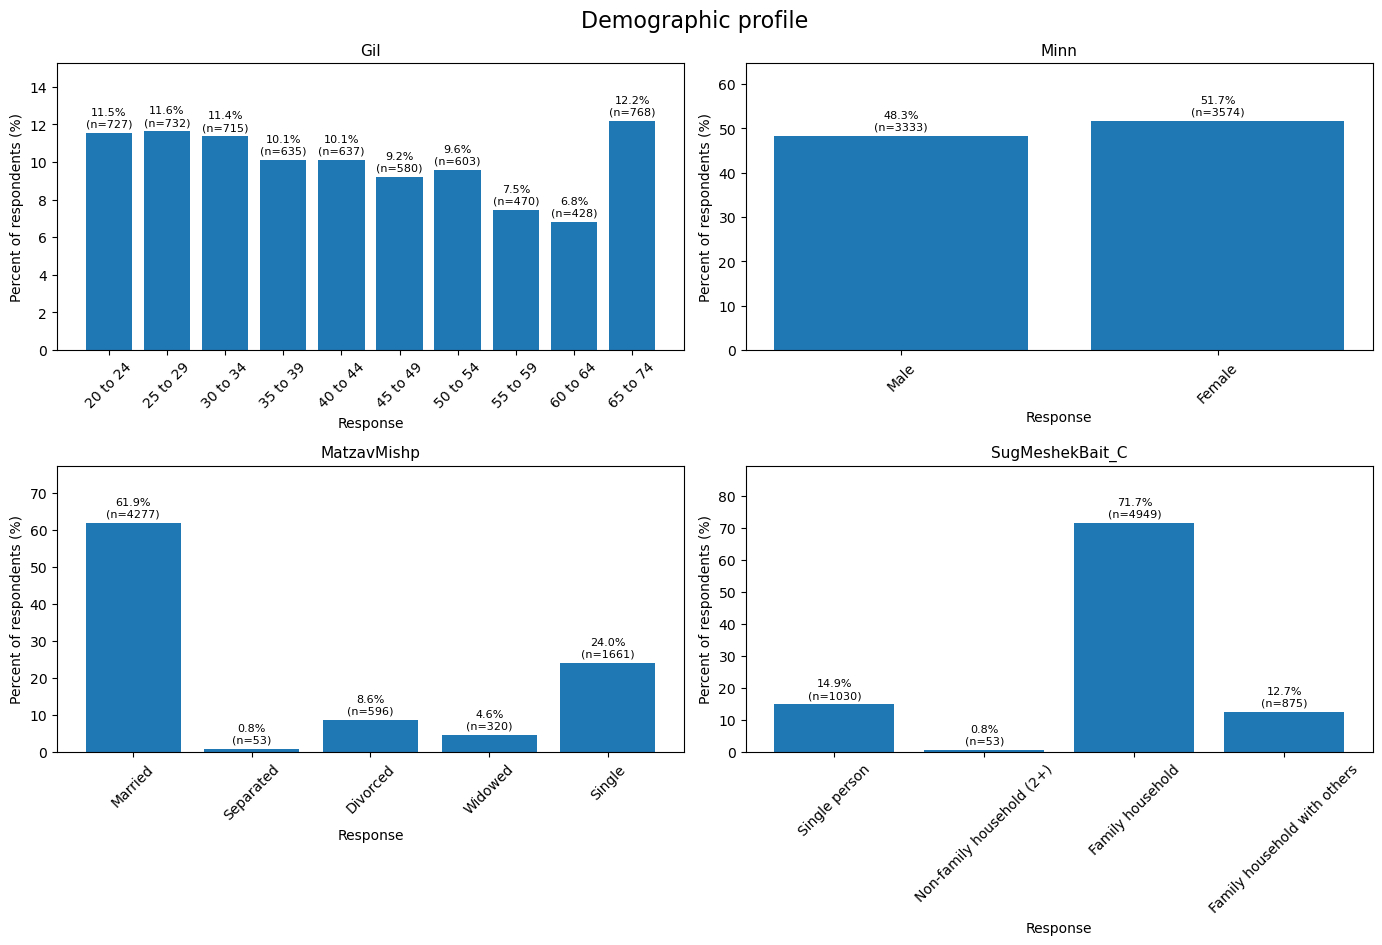

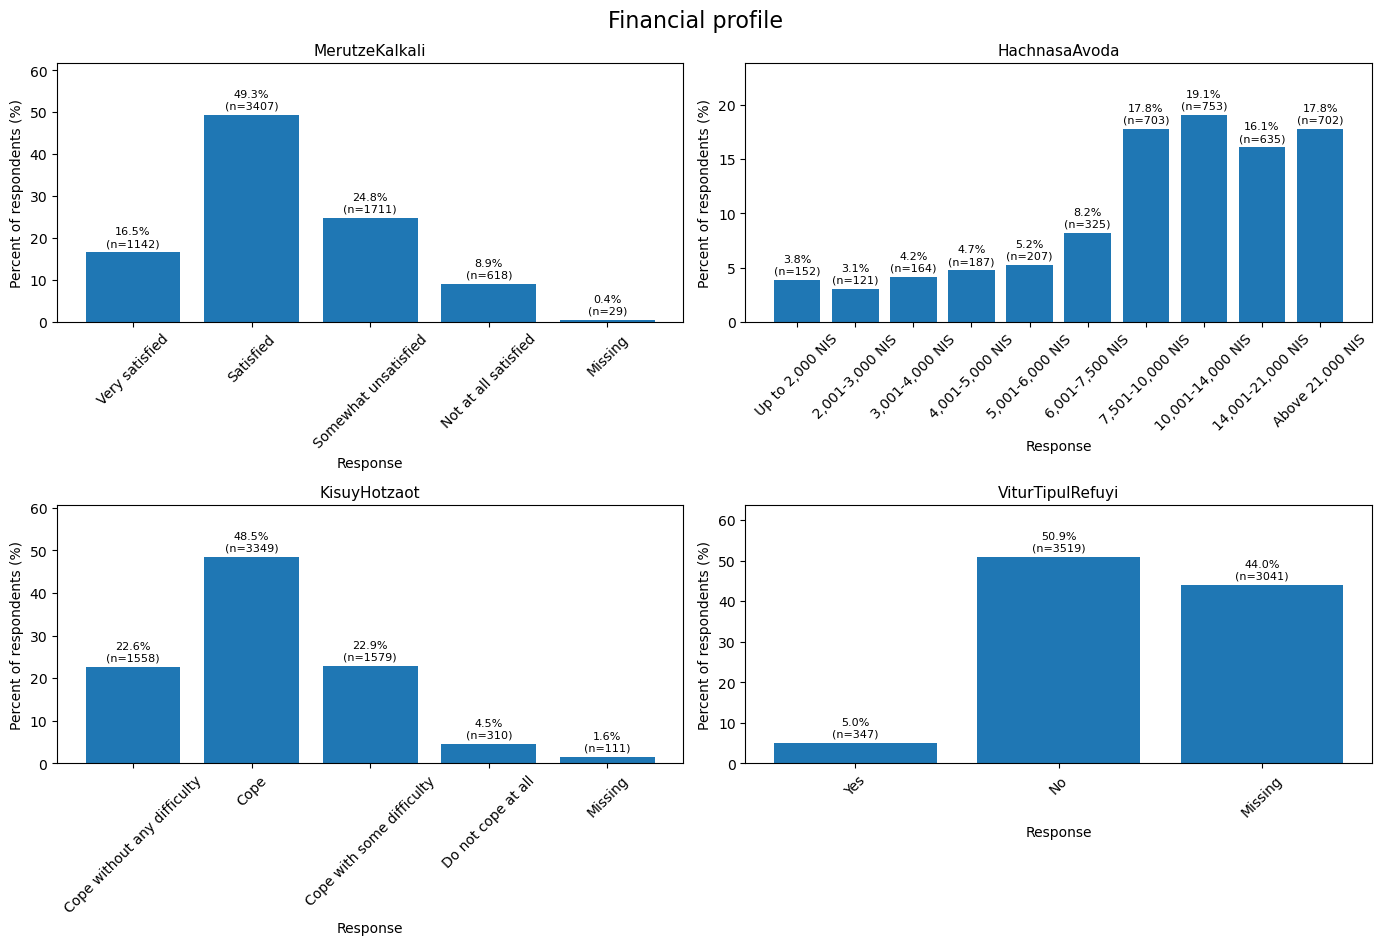

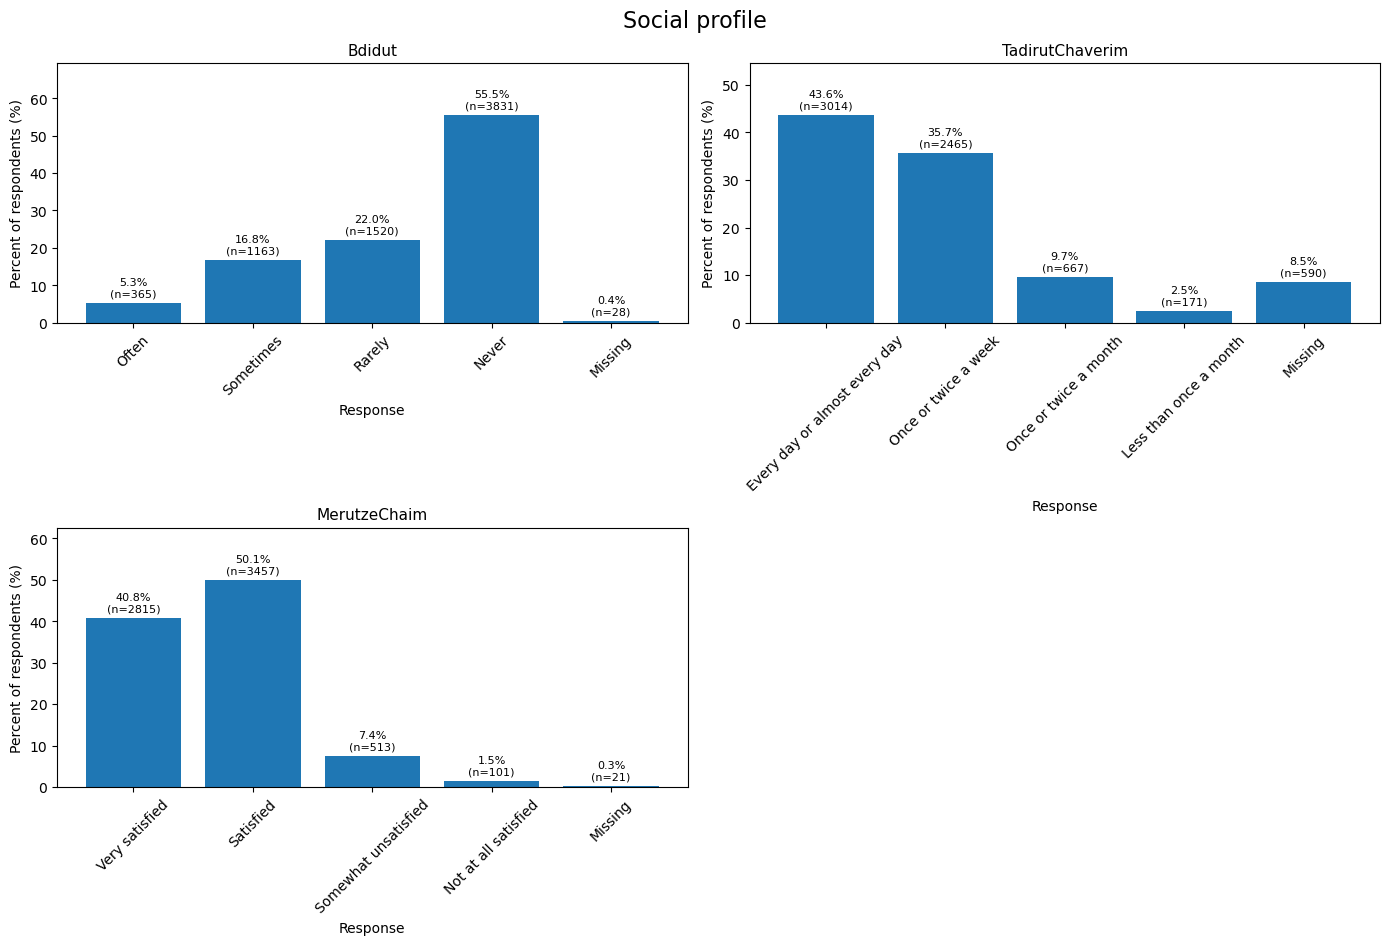

In [19]:
for group_name, variables in eda_groups.items():
    plot_frequency_group(
        data=df,
        variables=variables,
        title=group_name,
        codebook=codebook
    )


## 7. Target Construction and Feature Engineering


### 7.1 Target Variable: Financial Vulnerability
The primary outcome of this study is **financial vulnerability**. Rather than relying on a single survey question, the target variable was constructed from multiple indicators reflecting financial hardship. These indicators capture respondents' ability to meet routine expenses, cope with unexpected costs, and whether financial constraints led them to forgo essential needs such as medical care, medication, dental treatment, or adequate food.

Before constructing the composite target, the distribution of each indicator was examined to verify the coding of the response categories and the extent of missing values.

In [20]:
risk_columns = ["KisuyHotzaot", "ViturTipulRefuyi","ViturTerufot", "ViturTipulShinaim",
                "ViturOchel", "ViturAruchaChama","HotzaaLoTzfuya", "KisuyHotzaotBshana"]

for col in risk_columns:
    print(df[col].value_counts(dropna=False))


KisuyHotzaot
2.0    3349
3.0    1579
1.0    1558
4.0     310
NaN     111
Name: count, dtype: int64
ViturTipulRefuyi
2.0    3519
NaN    3041
1.0     347
Name: count, dtype: int64
ViturTerufot
2.0    4223
NaN    2420
1.0     264
Name: count, dtype: int64
ViturTipulShinaim
NaN    3118
2.0    2898
1.0     891
Name: count, dtype: int64
ViturOchel
2.0    6439
1.0     455
NaN      13
Name: count, dtype: int64
ViturAruchaChama
2.0    6579
1.0     316
NaN      12
Name: count, dtype: int64
HotzaaLoTzfuya
1.0    3756
2.0    2909
NaN     242
Name: count, dtype: int64
KisuyHotzaotBshana
2.0    4070
1.0    2763
NaN      74
Name: count, dtype: int64


In [21]:
# Coverage of expenses
risk_cover_expenses = np.where(
    df["KisuyHotzaot"].isna(),
    np.nan,
    np.where(df["KisuyHotzaot"].isin([3, 4]), 1, 0)
)

# Medical treatment
risk_medical = np.where(
    df["TipulRefuyi"] == 2,  # did not need treatment
    0,
    np.where(
        df["ViturTipulRefuyi"].isna(),
        np.nan,
        np.where(df["ViturTipulRefuyi"] == 1, 1, 0)
    )
)

# Prescription medicine
risk_medicine = np.where(
    df["Terufot"] == 2,  # did not need medicine
    0,
    np.where(
        df["ViturTerufot"].isna(),
        np.nan,
        np.where(df["ViturTerufot"] == 1, 1, 0)
    )
)

# Dental care
risk_dental = np.where(
    df["SHINAIM"] == 2,  # did not need dental treatment
    0,
    np.where(
        df["ViturTipulShinaim"].isna(),
        np.nan,
        np.where(df["ViturTipulShinaim"] == 1, 1, 0)
    )
)

# Food deprivation
risk_food = np.where(
    df["ViturOchel"].isna(),
    np.nan,
    np.where(df["ViturOchel"] == 1, 1, 0)
)

# Hot meal deprivation
risk_hot_meal = np.where(
    df["ViturAruchaChama"].isna(),
    np.nan,
    np.where(df["ViturAruchaChama"] == 1, 1, 0)
)

# Emergency expense
risk_emergency = np.where(
    df["HotzaaLoTzfuya"].isna(),
    np.nan,
    np.where(df["HotzaaLoTzfuya"] == 2, 1, 0)
)

# Income did not cover expenses during the year
risk_yearly_expenses = np.where(
    df["KisuyHotzaotBshana"].isna(),
    np.nan,
    np.where(df["KisuyHotzaotBshana"] == 1, 1, 0)
)

# ---------- Combine ----------

risk_df = pd.DataFrame({
    "risk_cover_expenses": risk_cover_expenses,
    "risk_medical": risk_medical,
    "risk_medicine": risk_medicine,
    "risk_dental": risk_dental,
    "risk_food": risk_food,
    "risk_hot_meal": risk_hot_meal,
    "risk_emergency": risk_emergency,
    "risk_yearly_expenses": risk_yearly_expenses
})

# How many indicators are missing?
risk_df["missing_risks"] = risk_df.isna().sum(axis=1)

# Composite score
risk_df["financial_risk_score"] = risk_df.iloc[:, :8].sum(
    axis=1,
    skipna=True
)

risk_df["missing_risks"].value_counts().sort_index()


missing_risks
0    6515
1     317
2      53
3       7
4       3
5       6
6       3
7       1
8       2
Name: count, dtype: int64

We constructed the financial risk score, which serves as the target variable (y), using eight questionnaire indicators reflecting different forms of financial hardship. Each indicator was coded as 1 when financial hardship was reported and 0 otherwise. Missing responses were retained as missing values, and the composite score was calculated by summing the available indicators, resulting in a theoretical range of 0 to 8. Since more than 94% of respondents had complete information and only a very small number had multiple missing indicators, we considered the score sufficiently reliable for further analysis. We next examine its distribution to determine an appropriate threshold for defining financial vulnerability.


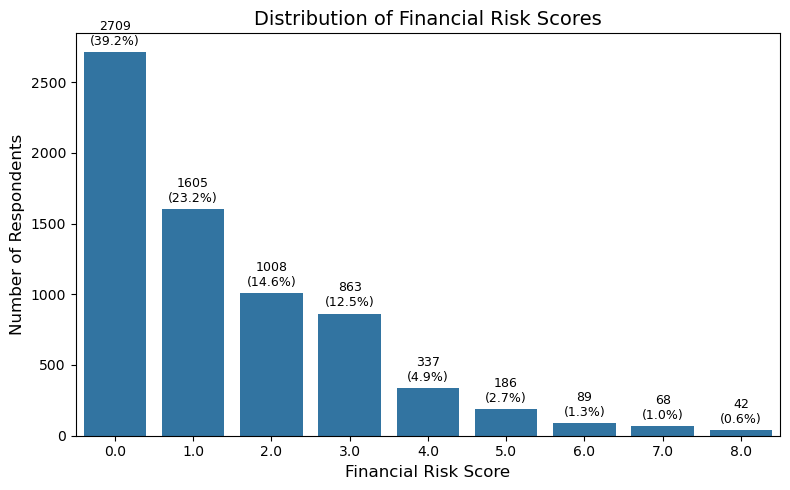

In [22]:

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=risk_df,
    x="financial_risk_score"
)

# Titles and axis labels
plt.title("Distribution of Financial Risk Scores", fontsize=14)
plt.xlabel("Financial Risk Score", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)

# Add count and percentage labels
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f"{count}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


The distribution of the financial risk score is positively skewed, with most respondents reporting few or no indicators of financial hardship. To define the binary target variable, we classified respondents with a financial risk score of 3 or higher as financially vulnerable. This threshold was chosen because it reflects the presence of multiple, co-occurring indicators of financial difficulty rather than isolated financial challenges. A score of three or more suggests a broader pattern of financial vulnerability across different aspects of daily life, while also identifying a meaningful minority of respondents (approximately 23% of the sample), resulting in a balanced and interpretable target variable for subsequent predictive modeling.


In [23]:
# Require at least 5 observed indicators out of 8
valid_target = risk_df["missing_risks"] <= 3

risk_df["financial_vulnerable"] = np.where(
    valid_target,
    (risk_df["financial_risk_score"] >= 3).astype(int),
    np.nan
)

# Add back to original dataframe
df["financial_risk_score"] = risk_df["financial_risk_score"].copy()
df["financial_vulnerable"] = risk_df["financial_vulnerable"].copy()

# Diagnostics
counts = df["financial_vulnerable"].value_counts(dropna=False).sort_index()
percents = df["financial_vulnerable"].value_counts(dropna=False, normalize=True).sort_index() * 100

diagnostics = pd.DataFrame({
    "Count": counts,
    "Percent": percents.round(1)
})

print("Target distribution:")
display(diagnostics)


Target distribution:


,Count,Percent
financial_vulnerable,,
0.0,5309,76.9
1.0,1583,22.9
NaN,15,0.2


### 7.2 Predictor Variables


The helper below summarizes coded survey variables using labels from the official codebook. It is reused across all predictor domains to keep the audit consistent.


In [24]:
def print_value_counts_with_labels(data, columns, codebook):
    
    for col in columns:
        print(f"\n{'=' * 50}")
        print(col)

        if col not in data.columns:
            print("Column not found in dataframe")
            continue

        labels = (
            codebook.loc[
                codebook["variavle_name"] == col,
                ["code", "code_title"]
            ]
            .drop_duplicates(subset="code")
            .set_index("code")["code_title"]
            .to_dict()
        )

        counts = data[col].value_counts(dropna=False).sort_index()

        result = pd.DataFrame({
            "Count": counts.values,
            "Percent": (counts.values / len(data) * 100).round(1),
            "Label": [
                labels.get(value, str(value)) if pd.notna(value)
                else "Missing"
                for value in counts.index
            ]
        }, index=counts.index)

        result.index.name = col

        print(result)


#### 7.2.1 Demographic Variables


In [25]:
demographic_columns = [
    "YelidBrham","Minn", "Gil", "ShnatAliya", "MatzavMishp",
    "BenZugOvad", "MechonitBashana", "NolduYeladim",
    "MispYeladim", "Dat", "SherutTzahal",
    "SherutLeumi", "RishyonNehiga"
]

print_value_counts_with_labels(
    data=df,
    columns=demographic_columns,
    codebook=codebook
)



YelidBrham
            Count  Percent Label
YelidBrham                      
1             947     13.7   Yes
2            5960     86.3    No

Minn
      Count  Percent   Label
Minn                        
1      3333     48.3    Male
2      3574     51.7  Female

Gil
     Count  Percent     Label
Gil                          
1      727     10.5  20 to 24
2      732     10.6  25 to 29
3      715     10.4  30 to 34
4      635      9.2  35 to 39
5      637      9.2  40 to 44
6      580      8.4  45 to 49
7      603      8.7  50 to 54
8      470      6.8  55 to 59
9      428      6.2  60 to 64
10     768     11.1  65 to 74
11     612      8.9       75+

ShnatAliya
            Count  Percent         Label
ShnatAliya                              
1.0            10      0.1       עד 1947
2.0           125      1.8  1948 עד 1954
3.0            75      1.1  1955 עד 1960
4.0           165      2.4  1961 עד 1971
5.0           105      1.5  1972 עד 1979
6.0            99      1.4  1980 עד 1989

In [26]:
# Create a separate dataframe for modeling
model_df = df.copy()


# ============================================================
# Binary variables: recode 1 = Yes, 2 = No into 1/0
# ============================================================

binary_yes_no = [
    "YelidBrham",
    "NolduYeladim",
    "RishyonNehiga",
    "SherutTzahal",
    "SherutLeumi"
]

for col in binary_yes_no:
    model_df[col] = model_df[col].map({
        1: 1,
        2: 0
    })


# Gender: create one binary indicator
# 0 = Male, 1 = Female
model_df["female"] = model_df["Minn"].map({
    1: 0,
    2: 1
})


# ============================================================
# Ordinal / numeric variables
# ============================================================

# Age groups already have a meaningful order:
# 1 = 20–24 ... 11 = 75+
model_df["Gil"] = pd.to_numeric(
    model_df["Gil"],
    errors="coerce"
)

# Number of children:
# 7 represents 7 or more children
model_df["MispYeladim"] = pd.to_numeric(
    model_df["MispYeladim"],
    errors="coerce"
)

# Immigration year is relevant only to respondents
# who were not born in Israel.
# Code 0 represents "Born in Israel / Not applicable".
model_df["ShnatAliya"] = model_df["ShnatAliya"].fillna(0)

# ============================================================
# Nominal categorical variables
# ============================================================

nominal_columns = [
    "MatzavMishp",
    "Dat"
]

for col in nominal_columns:
    model_df[col] = model_df[col].astype("category")

# ============================================================
# Select demographic variables for the initial model
# ============================================================

demographic_model_columns = [
    "YelidBrham",
    "female",
    "Gil",
    "ShnatAliya",
    "MatzavMishp",
    "MispYeladim",
    "Dat",
    "SherutTzahal",
    "SherutLeumi",
    "RishyonNehiga"
]

X_demographic = model_df[demographic_model_columns].copy()


# Check the result
print("Shape:", X_demographic.shape)
print("\nData types:")
print(X_demographic.dtypes)

print("\nMissing values:")
print(
    X_demographic.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 10)

Data types:
YelidBrham          int64
female              int64
Gil                 int64
ShnatAliya        float64
MatzavMishp      category
MispYeladim       float64
Dat              category
SherutTzahal      float64
SherutLeumi       float64
RishyonNehiga     float64
dtype: object

Missing values:
SherutLeumi      3493
SherutTzahal     1210
MispYeladim        14
Dat                12
RishyonNehiga       3
YelidBrham          0
female              0
Gil                 0
ShnatAliya          0
MatzavMishp         0
dtype: int64


#### 7.2.2 Household Variables


In [27]:
household_columns = ["SugMeshekBait_C", "Earners"]

print_value_counts_with_labels(
    data=df,
    columns=household_columns,
    codebook=codebook
)



SugMeshekBait_C
                 Count  Percent                         Label
SugMeshekBait_C                                              
1                 1030     14.9                 Single person
2                   53      0.8     Non-family household (2+)
3                 4949     71.7              Family household
4                  875     12.7  Family household with others

Earners
         Count  Percent Label
Earners                      
0         1175     17.0     0
1         2206     31.9     1
2         2533     36.7     2
3          673      9.7     3
4          249      3.6     4
5           71      1.0    5+


In [28]:
# Household type
model_df["SugMeshekBait_C"] = (
    model_df["SugMeshekBait_C"]
    .astype("category")
)

# Number of earners
model_df["Earners"] = pd.to_numeric(
    model_df["Earners"],
    errors="coerce"
)

X_household = model_df[["SugMeshekBait_C", "Earners"]].copy()

# Check the result
print("Shape:", X_household.shape)
print("\nData types:")
print(X_household.dtypes)

print("\nMissing values:")
print(
    X_household.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
SugMeshekBait_C    category
Earners               int64
dtype: object

Missing values:
SugMeshekBait_C    0
Earners            0
dtype: int64


#### 7.2.3 Health Variables


In [29]:
health_columns = ["BeayaBriut"]

print_value_counts_with_labels(
    data=df,
    columns=health_columns,
    codebook=codebook
)



BeayaBriut
            Count  Percent    Label
BeayaBriut                         
1.0          2210     32.0      Yes
2.0          4667     67.6       No
NaN            30      0.4  Missing


In [30]:
model_df["health_problem"] = model_df["BeayaBriut"].map({
    1: 1,   # Yes
    2: 0    # No
})

X_health = model_df["health_problem"].copy()

# Check the result
print("Shape:", X_health.shape)
print("\nData types:")
print(X_health.dtypes)

print("Missing values:", X_health.isna().sum())


Shape: (6907,)

Data types:
float64
Missing values: 30


#### 7.2.4 Education Variables


In [31]:
education_columns = ["ShnotLimud", "IvritDibur", "IvritKria", "IvritKtiva", ]

print_value_counts_with_labels(
    data=df,
    columns=education_columns,
    codebook=codebook
)



ShnotLimud
            Count  Percent     Label
ShnotLimud                          
1.0           123      1.8    0 עד 4
2.0           274      4.0    5 עד 8
3.0           317      4.6   9 עד 10
4.0          2028     29.4  11 עד 12
5.0          1703     24.7  13 עד 15
6.0          2445     35.4  16 ומעלה
NaN            17      0.2   Missing

IvritDibur
            Count  Percent         Label
IvritDibur                              
1            5024     72.7     טובה מאוד
2             798     11.6          טובה
3             546      7.9       בינונית
4             368      5.3          חלשה
5             171      2.5  לא יודע בכלל

IvritKria
           Count  Percent         Label
IvritKria                              
1           4953     71.7     טובה מאוד
2            721     10.4          טובה
3            511      7.4       בינונית
4            413      6.0          חלשה
5            309      4.5  לא יודע בכלל

IvritKtiva
            Count  Percent         Label
IvritKtiva  

In [32]:
display(model_df[
    [
        "IvritDibur",
        "IvritKria",
        "IvritKtiva"
    ]
].corr(method="spearman"))

hebrew_items = df[
    ["IvritDibur", "IvritKria", "IvritKtiva"]
].dropna()

k = hebrew_items.shape[1]

item_variances = hebrew_items.var(axis=0, ddof=1)
total_variance = hebrew_items.sum(axis=1).var(ddof=1)

cronbach_alpha = (
    k / (k - 1)
) * (
    1 - item_variances.sum() / total_variance
)

print(f"Cronbach's alpha = {cronbach_alpha:.3f}")


,IvritDibur,IvritKria,IvritKtiva
IvritDibur,1.000000,0.904618,0.888983
IvritKria,0.904618,1.000000,0.965273
IvritKtiva,0.888983,0.965273,1.000000


Cronbach's alpha = 0.971


The three Hebrew proficiency items are strongly correlated and measure closely related skills. To reduce redundancy, they are reverse-coded so that higher values indicate better proficiency and combined into a single mean score.


In [33]:
reverse_map = {
    1: 5,
    2: 4,
    3: 3,
    4: 2,
    5: 1
}

hebrew_cols = [
    "IvritDibur",
    "IvritKria",
    "IvritKtiva"
]

for col in hebrew_cols:
    model_df[col] = model_df[col].replace(reverse_map)

model_df["hebrew_proficiency"] = model_df[hebrew_cols].mean(axis=1)

print(model_df["hebrew_proficiency"].value_counts(dropna=False))


hebrew_proficiency
5.000000    4764
4.000000     497
3.000000     322
2.000000     235
4.333333     173
1.000000     161
2.333333     132
4.666667     131
3.666667     130
3.333333     124
1.333333      90
2.666667      89
1.666667      59
Name: count, dtype: int64


In [34]:
X_education = model_df[["ShnotLimud", "hebrew_proficiency"]].copy()

# Check the result
print("Shape:", X_education.shape)
print("\nData types:")
print(X_education.dtypes)

print("\nMissing values:")
print(
    X_education.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
ShnotLimud            float64
hebrew_proficiency    float64
dtype: object

Missing values:
ShnotLimud            17
hebrew_proficiency     0
dtype: int64


#### 7.2.5 Employment Variables


In [35]:
employment_columns = ["MatzavTaasukaM_C", "MispMekomot_C", "Menahel_wp", "MaamadAvoda_C_wp",
                     "AvodaYamim", "Ovad35_wp", "HekefMisra_C_wp",
                     "MerutzeAvoda_wp", "HachnasaAvodaNeto"]

print_value_counts_with_labels(
    data=df,
    columns=employment_columns,
    codebook=codebook
)



MatzavTaasukaM_C
                  Count  Percent                Label
MatzavTaasukaM_C                                     
1                  4676     67.7                מועסק
2                   248      3.6           בלתי מועסק
3                  1983     28.7  לא שייך לכוח העבודה

MispMekomot_C
               Count  Percent                    Label
MispMekomot_C                                         
1.0             4193     60.7     עובד במקום עבודה אחד
2.0              320      4.6  עובד במספר מקומות עבודה
NaN             2394     34.7                  Missing

Menahel_wp
            Count  Percent    Label
Menahel_wp                         
1.0          1203     17.4      Yes
2.0          3283     47.5       No
NaN          2421     35.1  Missing

MaamadAvoda_C_wp
                  Count  Percent                        Label
MaamadAvoda_C_wp                                             
1.0                3891     56.3    שכיר (כולל חבר קואופרטיב)
2.0                 750   

Missing values in several employment variables are largely structural because the questions were asked only of employed respondents. A dedicated **Not employed** category is therefore assigned where appropriate, distinguishing structural non-response from unknown values.


In [36]:
# ============================================================
# Structural missing values in employment-related variables
# ============================================================

# Employment status:
# 1 = Employed
# 2 = Unemployed
# 3 = Not in the labor force

not_employed_mask = model_df["MatzavTaasukaM_C"].isin([2, 3])

# For each variable:
# key   = column name
# value = new code meaning "Not employed / Not applicable"
not_employed_codes = {
    "MispMekomot_C": 3,        # Existing codes: 1–2
    "Menahel_wp": 3,            # Existing codes: 1–2
    "MaamadAvoda_C_wp": 4,      # Existing codes: 1–3
    "AvodaYamim": 99,           # Existing codes: 1–7 and 98
    "Ovad35_wp": 3,             # Existing codes: 1–2
    "HekefMisra_C_wp": 3,       # Existing codes: 1–2
    "MerutzeAvoda_wp": 5,       # Existing codes: 1–4
    "HachnasaAvodaNeto": 12     # Existing codes: 1–11
}

# Fill only structural missing values among non-employed respondents
for col, new_code in not_employed_codes.items():

    if col not in model_df.columns:
        print(f"Warning: {col} was not found in model_df")
        continue

    model_df.loc[
        not_employed_mask & model_df[col].isna(),
        col
    ] = new_code


# ============================================================
# Print distributions with labels from the codebook
# ============================================================

for col, new_code in not_employed_codes.items():

    if col not in model_df.columns:
        continue

    print(f"\n{'=' * 50}")
    print(col)

    # Labels from the original codebook
    labels = (
        codebook.loc[
            codebook["variavle_name"] == col,
            ["code", "code_title"]
        ]
        .drop_duplicates(subset="code")
        .set_index("code")["code_title"]
        .to_dict()
    )

    # Add the new category created during feature engineering
    labels[new_code] = "Not employed"

    counts = (
        model_df[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percent": (counts / len(model_df) * 100).round(1),
        "Label": [
            labels.get(value, str(value))
            if pd.notna(value)
            else "Missing"
            for value in counts.index
        ]
    })

    result.index.name = col

    print(result)



MispMekomot_C
               Count  Percent                    Label
MispMekomot_C                                         
1.0             4193     60.7     עובד במקום עבודה אחד
2.0              320      4.6  עובד במספר מקומות עבודה
3.0             2231     32.3             Not employed
NaN              163      2.4                  Missing

Menahel_wp
            Count  Percent         Label
Menahel_wp                              
1.0          1203     17.4           Yes
2.0          3283     47.5            No
3.0          2231     32.3  Not employed
NaN           190      2.8       Missing

MaamadAvoda_C_wp
                  Count  Percent                        Label
MaamadAvoda_C_wp                                             
1.0                3891     56.3    שכיר (כולל חבר קואופרטיב)
2.0                 750     10.9   עצמאי או מנהל חברה בבעלותו
3.0                  20      0.3                         אחר 
4.0                2231     32.3                 Not employed
NaN    

In [37]:
mapping = {
    11: 0,   # no work income
    12: 0,   # not employed
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    6: 6,
    7: 7,
    8: 8,
    9: 9,
    10: 10
}

model_df["work_income_level"] = (
    model_df["HachnasaAvodaNeto"]
    .replace(mapping)
)

employment_categorical = [
    "MispMekomot_C",
    "Menahel_wp",
    "MaamadAvoda_C_wp",
    "AvodaYamim",
    "HekefMisra_C_wp",
    "MerutzeAvoda_wp"
]

for col in employment_categorical:
    model_df[col] = model_df[col].astype("category")

X_employment = model_df[[
    "MispMekomot_C",
    "Menahel_wp",
    "MaamadAvoda_C_wp",
    "AvodaYamim",
    "HekefMisra_C_wp",
    "MerutzeAvoda_wp",
    "work_income_level"
]].copy()

# Check the result
print("Shape:", X_employment.shape)
print("\nData types:")
print(X_employment.dtypes)

print("\nMissing values:")
print(
    X_employment.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 7)

Data types:
MispMekomot_C        category
Menahel_wp           category
MaamadAvoda_C_wp     category
AvodaYamim           category
HekefMisra_C_wp      category
MerutzeAvoda_wp      category
work_income_level     float64
dtype: object

Missing values:
work_income_level    575
Menahel_wp           190
AvodaYamim           178
HekefMisra_C_wp      177
MispMekomot_C        163
MerutzeAvoda_wp      104
MaamadAvoda_C_wp      15
dtype: int64


#### 7.2.6 Social Participation Variables


In [38]:
hevrati_columns = ["HitnadvutShana", "TrumaShana", "TrumaSchum"]

print_value_counts_with_labels(
    data=df,
    columns=hevrati_columns,
    codebook=codebook
)



HitnadvutShana
                Count  Percent    Label
HitnadvutShana                         
1.0              2086     30.2      Yes
2.0              4809     69.6       No
NaN                12      0.2  Missing

TrumaShana
            Count  Percent    Label
TrumaShana                         
1.0          3855     55.8      Yes
2.0          3021     43.7       No
NaN            31      0.4  Missing

TrumaSchum
            Count  Percent             Label
TrumaSchum                                  
1.0           542      7.8        עד 100 ש"ח
2.0          1298     18.8   בין 500-101 ש"ח
3.0           729     10.6  בין 1000-501 ש"ח
4.0          1117     16.2      מעל 1000 ש"ח
NaN          3221     46.6           Missing


In [39]:
X_hevrati = model_df[["HitnadvutShana", "TrumaShana"]].copy()

# Check the result
print("Shape:", X_hevrati.shape)
print("\nData types:")
print(X_hevrati.dtypes)

print("\nMissing values:")
print(
    X_hevrati.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 2)

Data types:
HitnadvutShana    float64
TrumaShana        float64
dtype: object

Missing values:
TrumaShana        31
HitnadvutShana    12
dtype: int64


#### 7.2.7 Financial Management and Behavior Variables


In [40]:
financial_columns = ["AchrayutKesef", "MenahelTazrim", "MishtameshAppMaakav", "HoraotKeva",
                     "HashkaotBank", "HassachMezuman", "HassachGmach", "HashkaotShukHon",
                     "HashkaotMatbeotVirt", "HashkaotAher",
                     "HotziPachot", "AvadYoter", "MacharParit", "HishtameshHisachon", "EzraMishpHaverim", "PanaLeRevacha", "HalvaaMeAvoda",
                     "HalvaaBank", "HalvaaPrati", "HalvaaGmach", "Overdraft", "LoAmadBatashlumim",
                     "YedaHashkaa", "SikunHashkaot", "LoHosech", "HeshbonotBazman", "MatarotKaspiot", "ShokelKniot"]

print_value_counts_with_labels(
    data=df,
    columns=financial_columns,
    codebook=codebook
)



AchrayutKesef
               Count  Percent                    Label
AchrayutKesef                                         
1.0             1963     28.4                      אני
2.0             3747     54.2  אני בשיתוף עם מישהו אחר
3.0             1170     16.9                מישהו אחר
NaN               27      0.4                  Missing

MenahelTazrim
               Count  Percent    Label
MenahelTazrim                         
1.0             5156     74.6      Yes
2.0             1724     25.0       No
NaN               27      0.4  Missing

MishtameshAppMaakav
                     Count  Percent    Label
MishtameshAppMaakav                         
1.0                   3620     52.4      Yes
2.0                   3257     47.2       No
NaN                     30      0.4  Missing

HoraotKeva
            Count  Percent    Label
HoraotKeva                         
1.0          4821     69.8      Yes
2.0          2032     29.4       No
NaN            54      0.8  Missing

Hashka

Before including the financial behavior items separately, we calculate Cronbach’s alpha to assess whether they form a sufficiently coherent single scale. A low or moderate alpha would support retaining them as distinct predictors rather than summing them.


In [41]:
financial_scale_cols = [
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]

# Keep only complete cases for these items
financial_scale_data = model_df[financial_scale_cols].dropna()

# Number of items
k = financial_scale_data.shape[1]

# Variance of each item
item_variances = financial_scale_data.var(axis=0, ddof=1)

# Variance of the total score
total_score = financial_scale_data.sum(axis=1)
total_variance = total_score.var(ddof=1)

# Cronbach's alpha
cronbach_alpha = (
    k / (k - 1)
) * (
    1 - item_variances.sum() / total_variance
)

print(f"Number of complete cases: {len(financial_scale_data)}")
print(f"Cronbach's alpha: {cronbach_alpha:.3f}")


Number of complete cases: 6371
Cronbach's alpha: 0.363


In [42]:
# ============================================================
# Financial management variables
# ============================================================

# Binary variables
binary_financial_columns = [
    "MenahelTazrim",
    "MishtameshAppMaakav",
    "HoraotKeva",
    "HashkaotBank",
    "HassachMezuman",
    "HassachGmach",
    "HashkaotShukHon",
    "HashkaotMatbeotVirt",
    "HashkaotAher"
]

for col in binary_financial_columns:

    model_df[col] = model_df[col].map({
        1: 1,
        2: 0
    })

# Responsibility for household finances
# Keep as a nominal categorical variable
model_df["AchrayutKesef"] = model_df["AchrayutKesef"].astype("category")


# Ordinal financial behavior variables
financial_ordinal_columns = [
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]

for col in financial_ordinal_columns:

    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )


In [43]:
X_finance = model_df[[
    "AchrayutKesef",
    "MenahelTazrim",
    "MishtameshAppMaakav",
    "HoraotKeva",
    "HashkaotBank",
    "HassachMezuman",
    "HassachGmach",
    "HashkaotShukHon",
    "HashkaotMatbeotVirt",
    "HashkaotAher",
    "YedaHashkaa",
    "SikunHashkaot",
    "LoHosech",
    "HeshbonotBazman",
    "MatarotKaspiot",
    "ShokelKniot"
]]

# Check the result
print("Shape:", X_finance.shape)
print("\nData types:")
print(X_finance.dtypes)

print("\nMissing values:")
print(
    X_finance.isna()
    .sum()
    .sort_values(ascending=False)
)


Shape: (6907, 16)

Data types:
AchrayutKesef          category
MenahelTazrim           float64
MishtameshAppMaakav     float64
HoraotKeva              float64
HashkaotBank            float64
HassachMezuman          float64
HassachGmach            float64
HashkaotShukHon         float64
HashkaotMatbeotVirt     float64
HashkaotAher            float64
YedaHashkaa             float64
SikunHashkaot           float64
LoHosech                float64
HeshbonotBazman         float64
MatarotKaspiot          float64
ShokelKniot             float64
dtype: object

Missing values:
MatarotKaspiot         285
LoHosech               259
YedaHashkaa            182
SikunHashkaot          172
HeshbonotBazman        147
ShokelKniot            147
HashkaotBank            97
HashkaotShukHon         82
HassachMezuman          81
HassachGmach            70
HashkaotAher            68
HashkaotMatbeotVirt     67
HoraotKeva              54
MishtameshAppMaakav     30
AchrayutKesef           27
MenahelTazrim        

#### 7.2.8 Financial Literacy


In [44]:
financial_literacy_columns = ["HishuvInflation", "HishuvRibit100_C", "HishuvRibitShana_C", "HishuvRibit5Shanim",
                             "BituyTsua", "BituyInflation", "BituyShukHahon"]
print_value_counts_with_labels(
    data=df,
    columns=financial_literacy_columns,
    codebook=codebook
)



HishuvInflation
                 Count  Percent                      Label
HishuvInflation                                           
1.0                255      3.7             יותר מאשר היום
2.0                378      5.5          אותו דבר כמו היום
3.0               4152     60.1                 פחות מהיום
4.0                337      4.9  לא ניתן לדעת מהמידע הקיים
NaN               1785     25.8                    Missing

HishuvRibit100_C
                  Count  Percent                                      Label
HishuvRibit100_C                                                           
0.0                5990     86.7                                          0
1.0                  75      1.1  ערך שונה מ-0 או לא ניתן לדעת מהמידע הקיים
NaN                 842     12.2                                    Missing

HishuvRibitShana_C
                    Count  Percent                      Label
HishuvRibitShana_C                                           
1.0                   191   

Financial literacy is operationalized as the number of correct answers across seven objective knowledge questions. Each correct response receives one point, producing a score from 0 to 7.


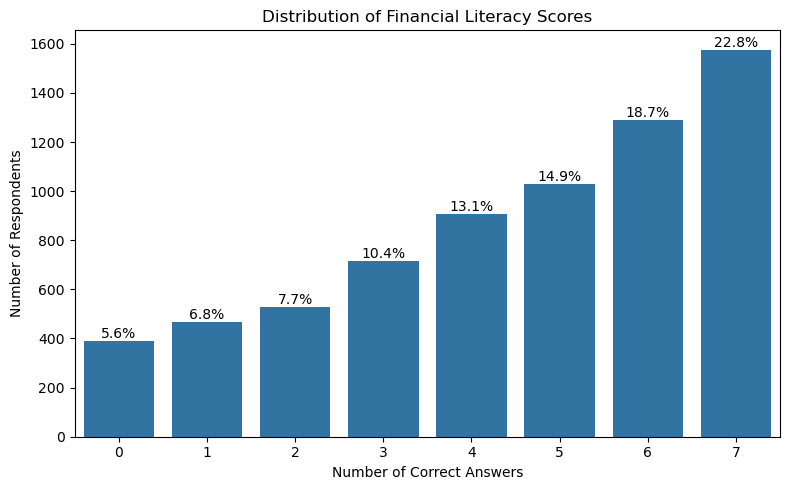

In [45]:
correct_answers = {
    "HishuvInflation": 3,
    "HishuvRibit100_C": 0,
    "HishuvRibitShana_C": 2,
    "HishuvRibit5Shanim": 1,
    "BituyTsua": 1,
    "BituyInflation": 1,
    "BituyShukHahon": 1
}

correct_columns = []

for col, correct_answer in correct_answers.items():

    new_col = f"{col}_Correct"

    # Correct = 1
    # Incorrect or missing = 0
    model_df[new_col] = (
        model_df[col] == correct_answer
    ).astype(int)

    correct_columns.append(new_col)


# Total number of correct answers (0–7)
model_df["FinancialLiteracyScore"] = model_df[
    correct_columns
].sum(axis=1)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=model_df,
    x="FinancialLiteracyScore",
    order=range(8)
)

total = len(model_df)

for bar in ax.patches:
    count = bar.get_height()

    ax.annotate(
        f"{count / total * 100:.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            count
        ),
        ha="center",
        va="bottom"
    )

plt.title("Distribution of Financial Literacy Scores")
plt.xlabel("Number of Correct Answers")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()


In [46]:
X_financial_literacy = model_df["FinancialLiteracyScore"].copy()

# Check the result
print("Shape:", X_financial_literacy.shape)
print("\nData types:")
print(X_financial_literacy.dtypes)

print("Missing values:", X_financial_literacy.isna().sum())


Shape: (6907,)

Data types:
int64
Missing values: 0


### 7.3 Final Modeling Dataset


In [47]:
# ============================================================
# Combine all feature groups into one modeling dataframe
# ============================================================


# Combine all feature tables by their row index
X = pd.concat(
    [
        X_demographic,
        X_household,
        X_health,
        X_education,
        X_employment,
        X_hevrati,
        X_finance,
        X_financial_literacy
    ],
    axis=1
)


# Remove duplicated columns, if the same feature appears more than once
duplicated_columns = X.columns[X.columns.duplicated()].tolist()

if duplicated_columns:
    print("Duplicated columns removed:")
    print(duplicated_columns)

    X = X.loc[:, ~X.columns.duplicated()]


# Add the target variable
model_data = X.copy()

model_data["financial_risk_score"] = (
    model_df["financial_risk_score"]
)


# Keep only rows for which the target is available
model_data = model_data.dropna(
    subset=["financial_risk_score"]
)


# Diagnostics
print("Combined dataframe shape:", model_data.shape)
print("Number of features:", X.shape[1])

print("\nMissing values by column:")
print(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)

print(model_data.columns.to_list())


Combined dataframe shape: (6907, 42)
Number of features: 41

Missing values by column:
SherutLeumi               3493
SherutTzahal              1210
work_income_level          575
MatarotKaspiot             285
LoHosech                   259
Menahel_wp                 190
YedaHashkaa                182
AvodaYamim                 178
HekefMisra_C_wp            177
SikunHashkaot              172
MispMekomot_C              163
ShokelKniot                147
HeshbonotBazman            147
MerutzeAvoda_wp            104
HashkaotBank                97
HashkaotShukHon             82
HassachMezuman              81
HassachGmach                70
HashkaotAher                68
HashkaotMatbeotVirt         67
HoraotKeva                  54
TrumaShana                  31
MishtameshAppMaakav         30
health_problem              30
AchrayutKesef               27
MenahelTazrim               27
ShnotLimud                  17
MaamadAvoda_C_wp            15
MispYeladim                 14
HitnadvutShana

## 8. Multicollinearity Check


In [48]:

# Variables whose numbers are only category codes
nominal_cols = [
    "MatzavMishp", "Dat", "SherutTzahal", "SherutLeumi",
    "SugMeshekBait_C", "MispMekomot_C", "Menahel_wp",
    "MaamadAvoda_C_wp", "AvodaYamim", "HekefMisra_C_wp",
    "MerutzeAvoda_wp", "AchrayutKesef"
]

X_check = X.copy()

# Tell Phi-K that these variables are categorical
X_check[nominal_cols] = X_check[nominal_cols].astype("category")

# Association matrix for all variable types
corr = X_check.phik_matrix(
    interval_cols=[
        col for col in X_check.columns
        if col not in nominal_cols
    ]
)

# Keep each pair only once
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

high_corr.columns = [
    "Variable 1",
    "Variable 2",
    "Association"
]

high_corr = (
    high_corr[high_corr["Association"] >= 0.85]
    .sort_values("Association", ascending=False)
    .reset_index(drop=True)
)

print(high_corr.to_string(index=False))


   Variable 1      Variable 2  Association
   AvodaYamim HekefMisra_C_wp     0.976991
   Menahel_wp HekefMisra_C_wp     0.948447
MispMekomot_C HekefMisra_C_wp     0.942950
MispMekomot_C      Menahel_wp     0.942944
   Menahel_wp      AvodaYamim     0.941262
MispMekomot_C      AvodaYamim     0.939711


To assess multicollinearity among the predictors, we calculated pairwise Phi-K associations, which are suitable for mixed data types (categorical, ordinal, binary, and numerical variables). A threshold of 0.85 was used to identify highly associated variables. Four employment-related variables (MispMekomot_C, Menahel_wp, AvodaYamim, and HekefMisra_C_wp) showed very high associations. This was expected because respondents who were not employed were assigned a dedicated "Not employed" category across these variables during feature engineering, creating substantial overlap. To reduce redundancy while preserving the most informative employment characteristic, we retained HekefMisra_C_wp (employment extent) and excluded MispMekomot_C, Menahel_wp, and AvodaYamim from the final model.


In [49]:
model_data = model_data.drop(
    columns=[
        "MispMekomot_C",
        "Menahel_wp",
        "AvodaYamim"
    ],
    errors="ignore"
)


In [50]:
print("Dataframe shape:", model_data.shape)

print("\nMissing values by column:")
print(
    model_data.isna()
    .sum()
    .sort_values(ascending=False)
)


Dataframe shape: (6907, 39)

Missing values by column:
SherutLeumi               3493
SherutTzahal              1210
work_income_level          575
MatarotKaspiot             285
LoHosech                   259
YedaHashkaa                182
HekefMisra_C_wp            177
SikunHashkaot              172
ShokelKniot                147
HeshbonotBazman            147
MerutzeAvoda_wp            104
HashkaotBank                97
HashkaotShukHon             82
HassachMezuman              81
HassachGmach                70
HashkaotAher                68
HashkaotMatbeotVirt         67
HoraotKeva                  54
TrumaShana                  31
health_problem              30
MishtameshAppMaakav         30
AchrayutKesef               27
MenahelTazrim               27
ShnotLimud                  17
MaamadAvoda_C_wp            15
MispYeladim                 14
Dat                         12
HitnadvutShana              12
RishyonNehiga                3
FinancialLiteracyScore       0
YelidBrham     

## 9. Final Dataset Summary

The final table contains the engineered predictors and the financial vulnerability outcome after removing highly redundant employment variables. The following diagnostics provide a final check before preprocessing and model training.


In [51]:
print(f"Final dataset shape: {model_data.shape}")
print(f"Number of predictors: {model_data.shape[1] - 1}")
print("\nTarget distribution:")
print(model_data["financial_risk_score"].value_counts(normalize=True).sort_index().round(3))

# Optional export
# model_data.to_csv("social_survey_model_data.csv", index=False)


Final dataset shape: (6907, 39)
Number of predictors: 38

Target distribution:
financial_risk_score
0.0    0.392
1.0    0.232
2.0    0.146
3.0    0.125
4.0    0.049
5.0    0.027
6.0    0.013
7.0    0.010
8.0    0.006
Name: proportion, dtype: float64


### Handoff to Part 2 - save `model data.csv`

Writes Shai's cleaned modelling dataframe to disk so Ovad's part can pick it up with a plain `pd.read_csv("model data.csv")` on any environment - local Jupyter or Google Colab, no Drive mount needed.


In [52]:
# Save the cleaned dataframe for the next part.
model_data.to_csv("model data.csv", index=False)
print(f"Saved: model data.csv  ({len(model_data)} rows x {model_data.shape[1]} columns)")

# Cross-part state hand-off (added for Colab Part-3-only support).
# Or's Part 3 needs several DataFrames from Shai's Part 1 that live only
# in memory: raw, structure_summary, data_dictionary, eda_groups, codebook,
# model_data. This pickle lets Part 3 restore them without re-running Part 1.
_shai_state = {
    "raw": raw,
    "structure_summary": structure_summary,
    "data_dictionary": data_dictionary,
    "eda_groups": eda_groups,
    "codebook": codebook,
    "model_data": model_data,
}
joblib.dump(_shai_state, "shai_state.pkl")
print(f"Saved shai_state.pkl ({sum(1 for _ in _shai_state)} objects)")


Saved: model data.csv  (6907 rows x 39 columns)
Saved shai_state.pkl (6 objects)


# Part 2 - Model: GMM (Quick version) (Ovad)

Trains the GMM-derived classification model on top of Shai's `model_data`.

**Two local-run adaptations were applied to Ovad's original notebook:**
- Cell 0 (`from google.colab import drive; drive.mount(...)`) is wrapped in `try/except` so it silently no-ops off Colab.
- Cell 5 replaces `pd.read_csv(path + "model data.csv")` with an in-memory bridge (`datas = model_data`) that pulls Shai's output directly. The original Colab lines are kept commented for reference.

In [53]:
# Colab-only mount. Silently skipped when running off Colab (e.g. local Windows).
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass


##0. Datas

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

In [55]:
# ==========================
# Save Figures Automatically
# ==========================

saved_figures = {}

_original_show = plt.show


def save_and_show(*args, **kwargs):

    fig = plt.gcf()


    # Save only figures that contain real plots

    if len(fig.axes) > 0:

        name = f"Fig_{len(saved_figures)+1}"

        saved_figures[name] = fig


    # Temporarily restore original show
    # to avoid recursive saving

    plt.show = _original_show


    _original_show(*args, **kwargs)


    # Re-enable saving

    plt.show = save_and_show



plt.show = save_and_show

A binary target variable is generated by thresholding the financial risk score at 3:

In [56]:
# Handoff from Part 1 (Shai): read the CSV he wrote at end of his section.
# `path = ""` reads from the current working directory, which works
# identically on local Jupyter and on Google Colab (no Drive mount needed).

path = ""
datas = pd.read_csv(path + "model data.csv")

df = datas

df.describe()

features = df.columns.tolist()
print(features)
dfC = df.copy()
   # Target: 1 = at risk (score 3-7), 0 = otherwise.
dfC["AtRisk"] = (df['financial_risk_score'] >= 3).astype(int)


['YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp', 'MispYeladim', 'Dat', 'SherutTzahal', 'SherutLeumi', 'RishyonNehiga', 'SugMeshekBait_C', 'Earners', 'health_problem', 'ShnotLimud', 'hebrew_proficiency', 'MaamadAvoda_C_wp', 'HekefMisra_C_wp', 'MerutzeAvoda_wp', 'work_income_level', 'HitnadvutShana', 'TrumaShana', 'AchrayutKesef', 'MenahelTazrim', 'MishtameshAppMaakav', 'HoraotKeva', 'HashkaotBank', 'HassachMezuman', 'HassachGmach', 'HashkaotShukHon', 'HashkaotMatbeotVirt', 'HashkaotAher', 'YedaHashkaa', 'SikunHashkaot', 'LoHosech', 'HeshbonotBazman', 'MatarotKaspiot', 'ShokelKniot', 'FinancialLiteracyScore', 'financial_risk_score']


In [57]:
features = [
    'YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp', 'MispYeladim',
    'Dat', 'SherutTzahal', 'SherutLeumi', 'RishyonNehiga', 'SugMeshekBait_C',
    'Earners', 'health_problem', 'ShnotLimud', 'hebrew_proficiency',
    'MaamadAvoda_C_wp', 'HekefMisra_C_wp', 'MerutzeAvoda_wp',
    'work_income_level', 'HitnadvutShana', 'TrumaShana', 'AchrayutKesef',
    'MenahelTazrim', 'MishtameshAppMaakav', 'HoraotKeva', 'HashkaotBank',
    'HassachMezuman', 'HassachGmach', 'HashkaotShukHon',
    'HashkaotMatbeotVirt', 'HashkaotAher', 'YedaHashkaa',
    'SikunHashkaot', 'LoHosech', 'HeshbonotBazman',
    'MatarotKaspiot', 'ShokelKniot'
]

In [58]:
X = dfC[features]
y = dfC["AtRisk"]


In [59]:
#splitting for train and test for dumber classifier
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

##1. Baseline Model Evaluation

This section evaluates a baseline classifier with a uniform random prediction strategy.  
Performance is measured on the independent test set using Accuracy, Recall, and F1-score.  
The results provide a reference benchmark for comparison with the trained supervised models.

In [60]:
from sklearn.metrics import f1_score, recall_score, accuracy_score

# Dummy baseline, strategy="uniform" (random 50%-50% prediction)
# chosen to obtain non-zero F1 and Recall values
baseline = DummyClassifier(
    strategy="uniform",
    random_state=42
).fit(
    X_train,
    y_train
)

baseline_pred = baseline.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)

baseline_recall = recall_score(
    y_test,
    baseline_pred
)


# Create results table with one row for the Dummy Classifier

results_table = pd.DataFrame({
    "Model": ["DummyClass. ('uniform')"],
    "Accuracy": [round(baseline_accuracy, 3)],
    "F1 Score": [round(baseline_f1, 3)],
    "Recall": [round(baseline_recall, 3)]
})


# Display the table

print(results_table)

                     Model  Accuracy  F1 Score  Recall
0  DummyClass. ('uniform')     0.504     0.312   0.489


# 2. Supervised Classification Using GMM-Derived Features

## Overview

This approach combines unsupervised and supervised learning by applying a Gaussian Mixture Model (GMM) as an unsupervised feature generation step within the classification pipeline.

The GMM is used to learn the underlying data distribution without using class labels and generates additional features based on soft cluster membership probabilities. These probability-based features represent the degree of association of each observation with the learned Gaussian components and may capture hidden patterns, latent structures, and complex relationships within the data.

The GMM-derived features are not used instead of the original variables. Instead, they are concatenated with the existing features inside the Pipeline:

**Original Features + GMM-Derived Features → Classification Model**

The resulting expanded feature representation is then provided as the input to the supervised classification models, allowing them to utilize both the original characteristics of the observations and additional distribution-based information learned by the GMM.

## Modeling Approach

The combined feature space, consisting of the original features together with the GMM-derived features, is evaluated using three supervised classification algorithms:

- Logistic Regression
- Random Forest
- Gradient Boosting

The complete workflow is optimized using `GridSearchCV` with cross-validation.

The optimization process evaluates different configurations of:

- GMM parameters, including the number of components, covariance structure, and initialization settings
- Classifier hyperparameters
- Classification decision thresholds

For each classifier, models using the original feature set alone are compared with models using the augmented feature space containing both original and GMM-derived features.

The optimal configuration is selected according to the highest cross-validation F1 score.

## Data Leakage Prevention

All data-dependent operations are included inside the Pipeline:

- Missing value imputation
- Feature scaling
- GMM fitting and generation of GMM-derived features
- Model training

Each cross-validation fold learns these transformations exclusively from its training subset. The GMM is fitted only on the training portion of each fold, and the resulting GMM-derived features for validation data are generated using this fitted model.

This procedure prevents Data Leakage and ensures that validation performance reflects the expected model behavior on previously unseen data.

After selecting the best configuration, the complete pipeline is retrained on the full training dataset and evaluated on an independent test set.

In [61]:
print(r"""
                         Training Data
                              |
                              v
                    +-------------------+
                    |   GridSearchCV    |
                    |       CV = 3      |
                    +-------------------+
                              |
                              v
                  Repeat for each CV Fold

        +-----------------------------------------+
        |              Pipeline                   |
        |                                         |
        |  Training Fold Only                     |
        |                                         |
        |  1. Missing Value Imputation            |
        |     (Median learned from Train Fold)    |
        |              |                          |
        |              v                          |
        |  2. Feature Scaling                     |
        |     (Parameters learned from Train Fold)|
        |              |                          |
        |              v                          |
        |  3. GMM Fitting                         |
        |     (Distribution learned from          |
        |      Train Fold only)                   |
        |              |                          |
        |              v                          |
        |  GMM-Derived Features                   |
        |                                         |
        +-----------------------------------------+
                              |
                              v

        +-----------------------------------------+
        |        Feature Augmentation             |
        |                                         |
        | Original Features + GMM Features        |
        |                                         |
        +-----------------------------------------+
                              |
                              v

        +-----------------------------------------+
        |     Supervised Classification           |
        |                                         |
        | Logistic Regression                     |
        | Random Forest                           |
        | Gradient Boosting                       |
        +-----------------------------------------+
                              |
                              v

                 Validation Fold Evaluation
                         (F1 Score)


        Data Leakage Prevention
---------------------------------------------------------
Imputer, Scaler, GMM and Classifier are fitted only on
the training portion of each CV fold.

Validation data and test data are only transformed using
the fitted pipeline and never influence model fitting.
---------------------------------------------------------
""")


                         Training Data
                              |
                              v
                    +-------------------+
                    |   GridSearchCV    |
                    |       CV = 3      |
                    +-------------------+
                              |
                              v
                  Repeat for each CV Fold

        +-----------------------------------------+
        |              Pipeline                   |
        |                                         |
        |  Training Fold Only                     |
        |                                         |
        |  1. Missing Value Imputation            |
        |     (Median learned from Train Fold)    |
        |              |                          |
        |              v                          |
        |  2. Feature Scaling                     |
        |     (Parameters learned from Train Fold)|
        |              |                         

In [62]:
# ==========================
# Imports
# ==========================

import numpy as np                                      # Numerical operations

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin

from sklearn.mixture import GaussianMixture             # GMM clustering model

from sklearn.pipeline import Pipeline                  # Combine preprocessing and model steps

from sklearn.impute import SimpleImputer               # Missing values handling

from sklearn.preprocessing import StandardScaler       # Feature normalization

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, f1_score



# ==========================
# Configuration
# ==========================

RANDOM_STATE = 42                                      # Reproducibility seed

N_GMM_COMPONENTS = [5, 7]                          # Number of Gaussian clusters to test

GMM_COVARIANCE_TYPES = ["full"]                        # GMM covariance structure

GMM_N_INIT = [5]

GMM_WARM_START = [ True]

CLASSIFICATION_THRESHOLDS = [ 0.3]                      # Classification decision thresholds

LR_C_VALUES = [0.01]                                   # Logistic Regression regularization

RF_N_ESTIMATORS = [90]                             # Number of trees

RF_MAX_DEPTH = [5, 7]                                   # Maximum tree depth

GB_N_ESTIMATORS = [90]                             # Number of boosting stages

GB_LEARNING_RATE = [0.07]                  # Gradient boosting learning rates

GB_MAX_DEPTH = [5, 7]                              # Tree depth for boosting



# ==========================
# Train/Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)                                                       # Split raw data before any learned transformation



# ==========================
# GMM Feature Generator
# ==========================

class GMMFeatureGenerator(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        n_components=10,
        covariance_type="full",
        n_init=1,
        warm_start=False,
        random_state=RANDOM_STATE
    ):

        self.n_components = n_components
        self.covariance_type = covariance_type
        self.n_init = n_init
        self.warm_start = warm_start
        self.random_state = random_state

    def fit(self, X, y=None):

        self.gmm_ = GaussianMixture(
             n_components=self.n_components,
             covariance_type=self.covariance_type,
             n_init=self.n_init,
             warm_start=self.warm_start,
             random_state=self.random_state
)                                              # Create GMM model with selected parameters

        self.gmm_.fit(X)                                # Learn Gaussian distributions from training fold only

        return self


    def transform(self, X):

        gmm_features = self.gmm_.predict_proba(X)        # Generate soft cluster probabilities as new features

        return np.hstack(
            (
                X,
                gmm_features
            )
        )                                               # Combine original features with GMM features



# ==========================
# Threshold Wrapper
# ==========================

class ThresholdClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self,
        model=None,
        threshold=0.5
    ):
        self.model = model
        self.threshold = threshold


    def fit(self, X, y):

        self.model.fit(
            X,
            y
        )                                               # Train selected classifier

        self.classes_ = self.model.classes_             # Required sklearn classifier attribute

        return self


    def predict(self, X):

        probabilities = self.model.predict_proba(X)[:, 1] # Get probability of positive class

        return (
            probabilities >= self.threshold
        ).astype(int)                                   # Convert probabilities into class labels


    def predict_proba(self, X):

        return self.model.predict_proba(X)              # Return original model probabilities



# ==========================
# Pipeline
# ==========================

pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")                # Learn missing value replacement inside each CV fold
    ),

    (
        "scaler",
        StandardScaler()                                # Learn scaling parameters inside each CV fold
    ),

    (
        "gmm",
        GMMFeatureGenerator()                           # Create additional GMM based features
    ),

    (
        "model",
        ThresholdClassifier()                           # Train classifier using transformed features
    )

])



# ==========================
# Grid Search Parameters
# ==========================

param_grid = [

    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        ],

        "model__model__C": LR_C_VALUES,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "gmm__n_init": GMM_N_INIT,

        "gmm__warm_start": GMM_WARM_START,

        "model__model": [
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        ],

        "model__model__C": LR_C_VALUES,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": RF_N_ESTIMATORS,

        "model__model__max_depth": RF_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],                                              # Switch ON GMM: compare model using GMM generated features

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "model__model": [
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": RF_N_ESTIMATORS,

        "model__model__max_depth": RF_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": ["passthrough"],                         # Switch OFF GMM: compare model using original features only

        "model__model": [
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": GB_N_ESTIMATORS,

        "model__model__learning_rate": GB_LEARNING_RATE,

        "model__model__max_depth": GB_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    },


    {
        "gmm": [
            GMMFeatureGenerator()
        ],                                              # Switch ON GMM: compare model using GMM generated features

        "gmm__n_components": N_GMM_COMPONENTS,

        "gmm__covariance_type": GMM_COVARIANCE_TYPES,

        "model__model": [
            GradientBoostingClassifier(
                random_state=RANDOM_STATE
            )
        ],

        "model__model__n_estimators": GB_N_ESTIMATORS,

        "model__model__learning_rate": GB_LEARNING_RATE,

        "model__model__max_depth": GB_MAX_DEPTH,

        "model__threshold": CLASSIFICATION_THRESHOLDS
    }

]
# ==========================
# GridSearchCV
# ==========================

# No Data Leakage: Pipeline fits all learned transformations only inside each CV training fold

grid = GridSearchCV(
    estimator=pipeline,                                # Optimize preprocessing + feature generation + classifier together
    param_grid=param_grid,                             # Test all selected hyperparameter combinations
    cv=3,                                              # Use three train/validation splits
    scoring="f1",                                      # Select best model according to F1 score
    n_jobs=-1,                                         # Use all available CPU cores
    refit=True                                         # Retrain best pipeline on complete X_train
)



# ==========================
# Model Training
# ==========================

grid.fit(
    X_train,
    y_train
)                                                     # Raw data enters pipeline; preprocessing happens automatically








GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('gmm', GMMFeatureGenerator()),
                                       ('model', ThresholdClassifier())]),
             n_jobs=-1,
             param_grid=[{'gmm': ['passthrough'],
                          'model__model': [LogisticRegression(max_iter=1000,
                                                              random_state=42)],
                          'model__model__C': [0.01],
                          'model__threshold': [0.3]},
                         {'gmm'...
                          'model__model__n_estimators': [90],
                          'model__threshold': [0.3]},
                         {'gmm': [GMMFeatureGenerator()],
                          'gmm__covariance_type': ['full'],
                          'gmm__n_components': [5, 7],
                          'model__model': [GradientBoostingClassifier(random_state=42)],
                          'model__model__learning_rate': [0.07],
                          'model__model__max_depth': [5, 7],
                          'model__model__n_estimators': [90],
                          'model__threshold': [0.3]}],
             scoring='f1')

##3. Summary of Final Model Evaluation With and Without GMM Features

This section summarizes the final evaluation results of the selected supervised models, chosen according to their highest cross-validation (CV) performance with GMM features enabled.  
Each selected model is compared against an identical configuration without GMM features, while preserving the same supervised model hyperparameters.  
The evaluation is conducted exclusively on the independent test set using Accuracy, Recall, and F1-score metrics.  
The results provide an overall assessment of the contribution of GMM-based feature generation to the final predictive performance.

In [63]:
print(r"""
                 GRIDSEARCHCV RESULTS
                        |
                        v
             +----------------------+
             |   CV Results Table   |
             +----------------------+
                        |
                        v
          +---------------------------+
          |  For Each Classifier      |
          |---------------------------|
          | Logistic Regression       |
          | Random Forest             |
          | Gradient Boosting         |
          +---------------------------+
                        |
                        v
     Select Best GMM Configuration
                        |
                        v
             Create Two Pipelines
                        |
               +--------+--------+
               |                 |
               v                 v
         With GMM         Without GMM
     (same parameters) (same parameters)
               |                 |
               +--------+--------+
                        |
                        v
      Train on X_train & Evaluate on X_test
          (Accuracy, Recall, F1)
                        |
                        v
         Build Comparison Results Table
                        |
                        v
      Highlight Best CV & Best Test Model
""")


                 GRIDSEARCHCV RESULTS
                        |
                        v
             +----------------------+
             |   CV Results Table   |
             +----------------------+
                        |
                        v
          +---------------------------+
          |  For Each Classifier      |
          |---------------------------|
          | Logistic Regression       |
          | Random Forest             |
          | Gradient Boosting         |
          +---------------------------+
                        |
                        v
     Select Best GMM Configuration
                        |
                        v
             Create Two Pipelines
                        |
               +--------+--------+
               |                 |
               v                 v
         With GMM         Without GMM
     (same parameters) (same parameters)
               |                 |
               +--------+--------+
          

In [64]:
# ==========================
# Best Model Results By Classifier
# ==========================

from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.base import clone
import pandas as pd
from tabulate import tabulate


# ==========================
# Convert CV Results
# ==========================

cv_results = pd.DataFrame(
    grid.cv_results_
)


best_models = []


# ==========================
# Extract Hyperparameters
# ==========================

def extract_parameters(params):

    return {
        "GMM_N": params.get("gmm__n_components", "-"),
        "Cov": params.get("gmm__covariance_type", "-"),
        "Threshold": params.get("model__threshold", "-"),
        "C": params.get("model__model__C", "-"),
        "Trees": params.get("model__model__n_estimators", "-"),
        "Depth": params.get("model__model__max_depth", "-"),
        "LR": params.get("model__model__learning_rate", "-")
    }



# ==========================
# Evaluate Each Classifier
# ==========================

for classifier_name in [
    "LogisticRegression",
    "RandomForestClassifier",
    "GradientBoostingClassifier"
]:


    classifier_results = cv_results[
        cv_results["param_model__model"]
        .apply(
            lambda x: type(x).__name__ == classifier_name
        )
    ]


    # ==========================
    # Best WITH GMM
    # ==========================

    gmm_results = classifier_results[
        classifier_results["param_gmm"]
        .apply(
            lambda x: x != "passthrough"
        )
    ]


    best_index = gmm_results[
        "mean_test_score"
    ].idxmax()


    best_parameters = cv_results.loc[
        best_index,
        "params"
    ]


    cv_f1 = cv_results.loc[
        best_index,
        "mean_test_score"
    ]


    # ==========================
    # Train WITH GMM
    # ==========================

    model_with_gmm = clone(
        pipeline
    )


    model_with_gmm.set_params(
        **best_parameters
    )


    model_with_gmm.fit(
        X_train,
        y_train
    )


    y_pred = model_with_gmm.predict(
        X_test
    )


    params_display = extract_parameters(
        best_parameters
    )


    best_models.append(
        {
            "Model": classifier_name.replace(
                "Classifier",
                ""
            ),

            "GMM": "With GMM",

            **params_display,

            "CV_F1": round(
                cv_f1,
                4
            ),

            "Accuracy": round(
                accuracy_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "Recall": round(
                recall_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "F1": round(
                f1_score(
                    y_test,
                    y_pred
                ),
                4
            )
        }
    )



    # ==========================
    # Train WITHOUT GMM
    # ==========================

    without_gmm_parameters = best_parameters.copy()


    without_gmm_parameters.pop(
        "gmm__n_components",
        None
    )


    without_gmm_parameters.pop(
        "gmm__covariance_type",
        None
    )


    model_without_gmm = clone(
        pipeline
    )


    model_without_gmm.set_params(
        **without_gmm_parameters
    )


    model_without_gmm.steps[2] = (
        "gmm",
        "passthrough"
    )


    model_without_gmm.fit(
        X_train,
        y_train
    )


    y_pred = model_without_gmm.predict(
        X_test
    )


    params_display = extract_parameters(
        best_parameters
    )


    params_display["GMM_N"] = "-"
    params_display["Cov"] = "-"


    best_models.append(
        {
            "Model": classifier_name.replace(
                "Classifier",
                ""
            ),

            "GMM": "Without GMM",

            **params_display,

            "CV_F1": "-",

            "Accuracy": round(
                accuracy_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "Recall": round(
                recall_score(
                    y_test,
                    y_pred
                ),
                4
            ),

            "F1": round(
                f1_score(
                    y_test,
                    y_pred
                ),
                4
            )
        }
    )



# ==========================
# Create Comparison Table
# ==========================

results_table = pd.DataFrame(
    best_models
)

# Order models by their WITH GMM Test F1

model_order = (
    results_table[
        results_table["GMM"] == "With GMM"
    ]
    .sort_values(
        by="F1",
        ascending=False
    )["Model"]
    .tolist()
)

results_table["Model"] = pd.Categorical(
    results_table["Model"],
    categories=model_order,
    ordered=True
)

results_table["GMM"] = pd.Categorical(
    results_table["GMM"],
    categories=[
        "With GMM",
        "Without GMM"
    ],
    ordered=True
)

results_table = results_table.sort_values(
    by=[
        "Model",
        "GMM"
    ]
).reset_index(
    drop=True
)


# ==========================
# Highlight Best Models
# ==========================

results_table_marked = results_table.astype(str).copy()


# Best model according to GridSearchCV (highest CV_F1)

cv_rows = results_table[
    results_table["CV_F1"] != "-"
]

best_cv_index = cv_rows["CV_F1"].astype(float).idxmax()


# Best model according to Test F1

best_test_index = results_table["F1"].idxmax()



# Same model wins both criteria

if best_cv_index == best_test_index:

    for column in results_table.columns:

        value = results_table_marked.loc[
            best_cv_index,
            column
        ]

        results_table_marked.loc[
            best_cv_index,
            column
        ] = (
            "***"
            + value
            + "***"
        )


# Different models win

else:

    for column in results_table.columns:

        value = results_table_marked.loc[
            best_cv_index,
            column
        ]

        results_table_marked.loc[
            best_cv_index,
            column
        ] = (
            "*"
            + value
            + "*"
        )


    for column in results_table.columns:

        value = results_table_marked.loc[
            best_test_index,
            column
        ]

        results_table_marked.loc[
            best_test_index,
            column
        ] = (
            "**"
            + value
            + "**"
        )

# ==========================
# Display Table
# ==========================


print(
    "\n"
    "For each classifier, the displayed hyperparameters were selected from the\n"
    "Cross-Validation results with GMM enabled.\n"
    "The corresponding 'Without GMM' model uses exactly the same hyperparameters,\n"
    "with only the GMM feature generation stage removed, allowing a direct\n"
    "comparison of the contribution of the GMM features.\n"
    "The CV_F1 column reports the Cross-Validation F1 score of the selected "
    "'With GMM' configuration.\nSince the 'Without GMM' models were not selected "
    "through Cross-Validation,\nno CV_F1 value is reported for those rows.\n"
    "Accuracy, Recall and F1 were computed on the independent test set after\n"
    "retraining each pipeline on the complete training data.\n"
    "* indicates the model selected by GridSearchCV according to the highest\n"
    "Cross-Validation F1 score (CV_F1).\n"
    "** indicates the model that achieved the highest Test F1 score.\n"
    "*** indicates the model that achieved both the highest Cross-Validation\n"
    "F1 score (CV_F1) and the highest Test F1 score."
)

print("\nBEST MODEL COMPARISON: WITH GMM vs WITHOUT GMM")
print("=" * 160)


print(
    tabulate(
        results_table_marked,
        headers="keys",
        tablefmt="github",
        showindex=False,
        stralign="center",
        numalign="center"
    )
)


print("=" * 160)


For each classifier, the displayed hyperparameters were selected from the
Cross-Validation results with GMM enabled.
The corresponding 'Without GMM' model uses exactly the same hyperparameters,
with only the GMM feature generation stage removed, allowing a direct
comparison of the contribution of the GMM features.
The CV_F1 column reports the Cross-Validation F1 score of the selected 'With GMM' configuration.
Since the 'Without GMM' models were not selected through Cross-Validation,
no CV_F1 value is reported for those rows.
Accuracy, Recall and F1 were computed on the independent test set after
retraining each pipeline on the complete training data.
* indicates the model selected by GridSearchCV according to the highest
Cross-Validation F1 score (CV_F1).
** indicates the model that achieved the highest Test F1 score.
*** indicates the model that achieved both the highest Cross-Validation
F1 score (CV_F1) and the highest Test F1 score.

BEST MODEL COMPARISON: WITH GMM vs WITHOUT GMM
|

##4. Final Test Evaluation

This section evaluates the best-performing model selected through cross-validation (CV) on the independent test set.  
Performance is assessed using Accuracy, F1-score, and a classification report to summarize the model's predictive performance.

In [65]:
# ==========================
# Final Test Evaluation
# ==========================

from sklearn.metrics import accuracy_score, f1_score, classification_report


# Retrieve fully fitted best pipeline

best_model = grid.best_estimator_


# ==========================
# Selected Model Name
# ==========================

selected_model = (
    best_model
    .named_steps["model"]
    .model
)

model_name = type(selected_model).__name__


print("\nSelected Model:")
print(model_name)


# ==========================
# Test Prediction
# ==========================

y_pred = best_model.predict(
    X_test
)


# ==========================
# Evaluation Metrics
# ==========================

print("\nTest Accuracy:")

print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nTest F1:")

print(
    f1_score(
        y_test,
        y_pred
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Selected Model:
GradientBoostingClassifier

Test Accuracy:
0.7706222865412445

Test F1:
0.5289747399702823

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1065
           1       0.50      0.56      0.53       317

    accuracy                           0.77      1382
   macro avg       0.68      0.70      0.69      1382
weighted avg       0.78      0.77      0.78      1382



### Handoff to Part 3 - save `xgb_model.pkl`

Persists the trained best-of-GridSearchCV pipeline so Or's dashboard part can load it (`joblib.load("xgb_model.pkl")`) and drive the Model tab.


In [66]:
# Persist the trained pipeline for Part 3.
import joblib
joblib.dump(best_model, "xgb_model.pkl")
print(f"Saved: xgb_model.pkl  ({type(best_model).__name__})")

# Cross-part state hand-off (added for Colab Part-3-only support).
# Or's Part 3 needs Ovad's in-memory objects for the Model tabs:
# features (list), cv_results (DataFrame), saved_figures (dict of Figures).
_ovad_state = {
    "features": features,
    "cv_results": cv_results,
    "saved_figures": saved_figures,
}
joblib.dump(_ovad_state, "ovad_state.pkl")
print(f"Saved ovad_state.pkl ({sum(1 for _ in _ovad_state)} objects)")


Saved: xgb_model.pkl  (Pipeline)
Saved ovad_state.pkl (3 objects)


##5. Hyperparameter Sensitivity Analysis

This section evaluates the impact of individual hyperparameter variations on model performance.  
The initial model configuration is selected based on the highest cross-validation (CV) performance obtained during model selection, and is subsequently retrained on the complete training dataset.  
For each sensitivity analysis, a single hyperparameter is modified while all remaining parameters are fixed according to this selected configuration.  
The visualizations illustrate the effect of parameter changes on Accuracy, Recall, and F1 score, with the red dashed line indicating the original CV-selected parameter value.  
Model performance is evaluated on the complete independent test dataset, and a summary table presents the final selected model configuration and its corresponding parameters.

In [67]:
print(r"""
                 Best Model Selected by GridSearchCV
                              |
                              v

+--------------------------------+     +--------------------------------+
| Test Hyperparameter Values     | --> | Change One Hyperparameter      |
|                                |     |                                |
| n_estimators | learning_rate   |     | Keep Remaining Parameters Fixed|
| max_depth    | threshold | C   |     |                                |
+--------------------------------+     +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Retrain Model on X_train       |
                                      +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Evaluate Model on X_test       |
                                      | Accuracy | Recall | F1-score   |
                                      +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Generate Performance Plots     |
                                      | Hyperparameter vs Metrics      |
                                      +--------------------------------+
""")


                 Best Model Selected by GridSearchCV
                              |
                              v

+--------------------------------+     +--------------------------------+
| Test Hyperparameter Values     | --> | Change One Hyperparameter      |
|                                |     |                                |
| n_estimators | learning_rate   |     | Keep Remaining Parameters Fixed|
| max_depth    | threshold | C   |     |                                |
+--------------------------------+     +--------------------------------+
                                                   |
                                                   v
                                      +--------------------------------+
                                      | Retrain Model on X_train       |
                                      +--------------------------------+
                                                   |
                                                   v
      

Selected model:
GradientBoostingClassifier

Best Model Parameters:
               Parameter                      Value
             --- GMM ---                           
                     GMM                        Off
--- Supervised Model ---                           
                   Model GradientBoostingClassifier
                   Trees                         90
                      LR                       0.07
                   Depth                          5
               Threshold                        0.3


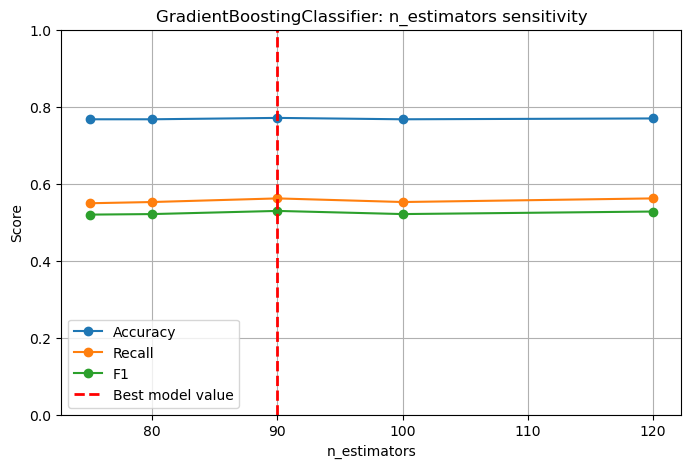

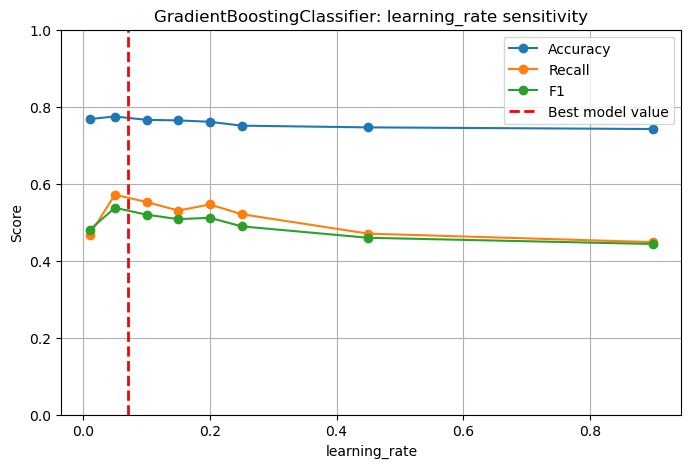

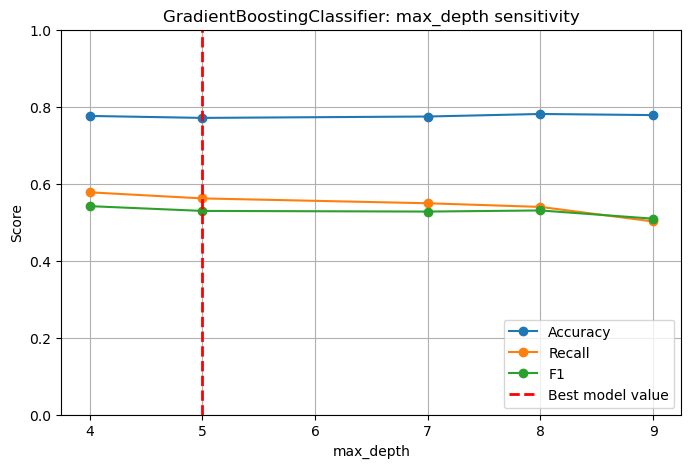

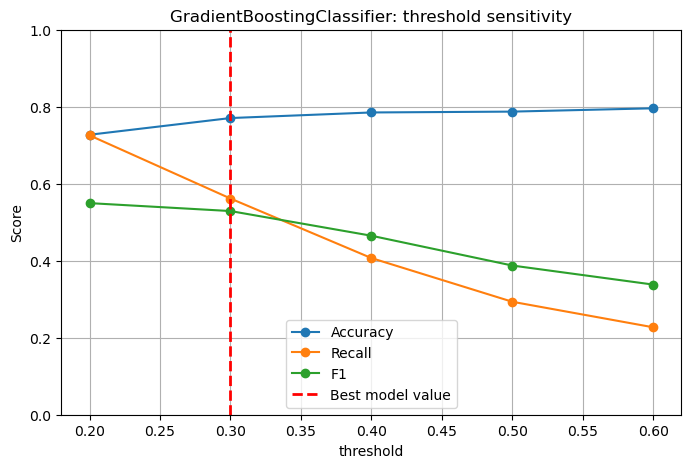

In [68]:
# ==========================
# Imports
# ==========================

from sklearn.base import clone
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# Parameters To Test
# ==========================

PARAMETER_TESTS = {
    "n_estimators": [75, 80, 90, 100, 120],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.45, 0.9],
    "max_depth": [4, 5, 7, 8, 9],
    "threshold": [0.2, 0.3, 0.4, 0.5, 0.6]
}


# ==========================
# Select Best Model From Grid
# ==========================

best_model = grid.best_estimator_


inner_model = (
    best_model
    .named_steps["model"]
    .model
)


model_name = type(inner_model).__name__


available_parameters = inner_model.get_params()


print("Selected model:")
print(model_name)



# ==========================
# Save Best Model Parameters
# ==========================

best_model_parameters = best_model.get_params()


# ==========================
# Display Best Model Parameters
# ==========================

best_parameters_display = {}


# --------------------------
# GMM
# --------------------------

best_parameters_display["--- GMM ---"] = ""


if best_model_parameters.get("gmm") == "passthrough":

    best_parameters_display["GMM"] = "Off"

else:

    best_parameters_display["GMM"] = "On"


    if "gmm__n_components" in best_model_parameters:

        best_parameters_display["Components"] = (
            best_model_parameters["gmm__n_components"]
        )


    if "gmm__covariance_type" in best_model_parameters:

        best_parameters_display["Cov"] = (
            best_model_parameters["gmm__covariance_type"]
        )



# --------------------------
# Supervised Model
# --------------------------

best_parameters_display["--- Supervised Model ---"] = ""

best_parameters_display["Model"] = model_name



parameter_mapping = {

    "n_estimators": "Trees",

    "learning_rate": "LR",

    "max_depth": "Depth",

    "C": "C",

    "threshold": "Threshold"

}



for param, short_name in parameter_mapping.items():


    if param == "threshold":

        key = "model__threshold"

    else:

        key = f"model__model__{param}"


    if key in best_model_parameters:


        value = best_model_parameters[key]


        if isinstance(value, float):

            value = round(
                value,
                3
            )

            if value.is_integer():

                value = int(value)


        best_parameters_display[short_name] = value



best_parameters_table = pd.DataFrame(
    list(best_parameters_display.items()),
    columns=[
        "Parameter",
        "Value"
    ]
)


print(
    "\nBest Model Parameters:"
)


print(
    best_parameters_table.to_string(
        index=False
    )
)

# ==========================
# Add Logistic Regression Parameter
# ==========================

if model_name == "LogisticRegression":

    PARAMETER_TESTS.update(
        {
            "C": [
                0.001,
                0.005,
                0.01,
                0.02,
                0.03,
                0.1,
                0.2,
                0.5,
                0.7
            ]
        }
    )



# ==========================
# Evaluation Function
# ==========================

def evaluate_parameter(
    model,
    parameter_name,
    parameter_value
):

    test_model = clone(model)


    # Threshold belongs to wrapper

    if parameter_name == "threshold":

        test_model.set_params(
            model__threshold=parameter_value
        )


    # Model parameters

    else:

        test_model.set_params(
            **{
                f"model__model__{parameter_name}":
                parameter_value
            }
        )


    test_model.fit(
        X_train,
        y_train
    )


    y_pred = test_model.predict(
        X_test
    )


    return {
        parameter_name: parameter_value,

        "Accuracy": round(
            accuracy_score(
                y_test,
                y_pred
            ),
            4
        ),

        "Recall": round(
            recall_score(
                y_test,
                y_pred
            ),
            4
        ),

        "F1": round(
            f1_score(
                y_test,
                y_pred
            ),
            4
        )
    }



# ==========================
# Run Sensitivity Tests
# ==========================

for parameter_name, values in PARAMETER_TESTS.items():


    # Check if parameter belongs to model

    if (
        parameter_name != "threshold"
        and parameter_name not in available_parameters
    ):

        print(
            f"Skipping {parameter_name} "
            f"(not available for {model_name})"
        )

        continue



    # ==========================
    # Original Best Model Value
    # ==========================

    if parameter_name == "threshold":

        original_value = best_model_parameters[
            "model__threshold"
        ]

    else:

        original_value = best_model_parameters[
            f"model__model__{parameter_name}"
        ]



    results = []


    for value in values:

        results.append(
            evaluate_parameter(
                best_model,
                parameter_name,
                value
            )
        )



    results_table = pd.DataFrame(
        results
    )



    # ==========================
    # Plot
    # ==========================

    plt.figure(
        figsize=(8, 5)
    )


    plt.plot(
        results_table[parameter_name],
        results_table["Accuracy"],
        marker="o",
        label="Accuracy"
    )


    plt.plot(
        results_table[parameter_name],
        results_table["Recall"],
        marker="o",
        label="Recall"
    )


    plt.plot(
        results_table[parameter_name],
        results_table["F1"],
        marker="o",
        label="F1"
    )


    # Best model value marker

    plt.axvline(
        x=original_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Best model value"
    )


    plt.xlabel(
        parameter_name
    )


    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1
    )


    plt.title(
        f"{model_name}: {parameter_name} sensitivity"
    )


    plt.legend()

    plt.grid()

    plt.show()

##6. Model Performance Evaluation on Test Set

This section evaluates the final CV-selected model on the independent test set using complementary classification metrics.  
The analysis includes confusion matrix, ROC-AUC, and Precision-Recall curve to assess classification performance and predictive discrimination.  

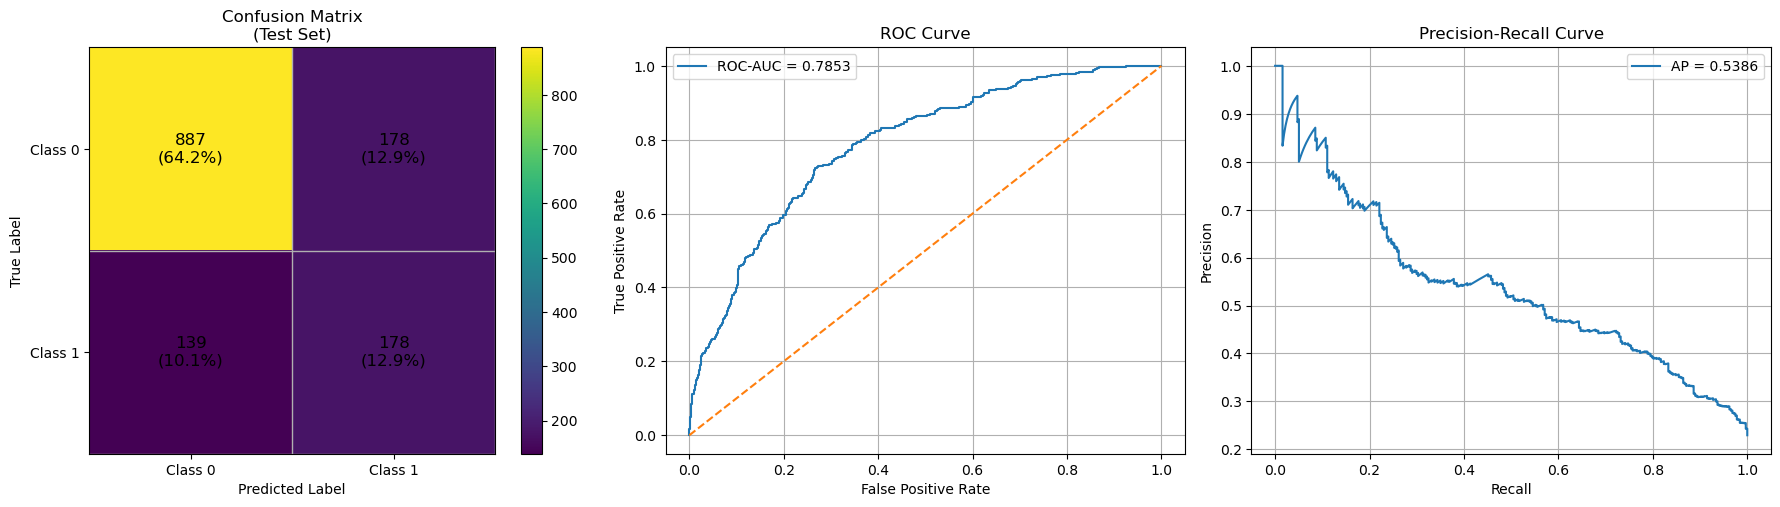


Total test samples:
1382

ROC-AUC:
0.7853

Average Precision (PR-AUC):
0.5386


In [69]:
# ==========================
# Confusion Matrix + ROC-AUC + PR Curve
# ==========================

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt



# ==========================
# Predictions
# ==========================

y_pred = best_model.predict(
    X_test
)


y_pred_proba = best_model.predict_proba(
    X_test
)[:, 1]



# ==========================
# Metrics Calculation
# ==========================

cm = confusion_matrix(
    y_test,
    y_pred
)


fpr, tpr, _ = roc_curve(
    y_test,
    y_pred_proba
)


roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)


precision, recall, _ = precision_recall_curve(
    y_test,
    y_pred_proba
)


average_precision = average_precision_score(
    y_test,
    y_pred_proba
)



# ==========================
# Create 1x3 Subplots
# ==========================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)



# ==========================
# 1. Confusion Matrix
# ==========================

im = axes[0].imshow(
    cm,
    interpolation="nearest"
)


# Add colorbar

fig.colorbar(
    im,
    ax=axes[0]
)


axes[0].set_title(
    "Confusion Matrix\n(Test Set)"
)


axes[0].set_xlabel(
    "Predicted Label"
)


axes[0].set_ylabel(
    "True Label"
)


axes[0].set_xticks(
    [0, 1]
)


axes[0].set_yticks(
    [0, 1]
)


axes[0].set_xticklabels(
    [
        "Class 0",
        "Class 1"
    ]
)


axes[0].set_yticklabels(
    [
        "Class 0",
        "Class 1"
    ]
)



# Add values and percentages

total = cm.sum()


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        value = cm[i, j]

        percentage = (
            value / total * 100
        )

        axes[0].text(
            j,
            i,
            f"{value}\n({percentage:.1f}%)",
            ha="center",
            va="center",
            fontsize=12
        )



# Grid between cells

axes[0].set_xticks(
    [
        0.5,
        1.5
    ],
    minor=True
)


axes[0].set_yticks(
    [
        0.5,
        1.5
    ],
    minor=True
)


axes[0].grid(
    which="minor",
    linewidth=1
)


axes[0].tick_params(
    which="minor",
    bottom=False,
    left=False
)



# ==========================
# 2. ROC Curve
# ==========================

axes[1].plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)


axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


axes[1].set_xlabel(
    "False Positive Rate"
)


axes[1].set_ylabel(
    "True Positive Rate"
)


axes[1].set_title(
    "ROC Curve"
)


axes[1].legend()

axes[1].grid()



# ==========================
# 3. Precision-Recall Curve
# ==========================

axes[2].plot(
    recall,
    precision,
    label=f"AP = {average_precision:.4f}"
)


axes[2].set_xlabel(
    "Recall"
)


axes[2].set_ylabel(
    "Precision"
)


axes[2].set_title(
    "Precision-Recall Curve"
)


axes[2].legend()

axes[2].grid()



# ==========================
# Display Plots
# ==========================

plt.tight_layout()

plt.show()



# ==========================
# Print Metrics
# ==========================


print("\nTotal test samples:")
print(cm.sum())


print("\nROC-AUC:")
print(round(roc_auc, 4))


print("\nAverage Precision (PR-AUC):")
print(round(average_precision, 4))

##7. SHAP Model Interpretation

The SHAP analysis is performed on the final model configuration selected according to the highest cross-validation (CV) performance.  
Following model selection, the chosen pipeline is retrained on the complete training dataset and interpreted using SHAP values on the independent test dataset.  
The analysis quantifies the contribution and importance of individual features in the final predictive model.

In [70]:
# ==========================
# SHAP Analysis - Full Model Features
# Compatible with LogisticRegression,
# RandomForestClassifier and GradientBoostingClassifier
# ==========================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# ==========================
# Extract Final Model
# ==========================

best_model = grid.best_estimator_


final_classifier = (
    best_model
    .named_steps["model"]
    .model
)


model_name = type(final_classifier).__name__


# ==========================
# Transform Test Data Through Pipeline
# (Imputer + Scaler + GMM)
# ==========================

X_test_shap = best_model[:-1].transform(
    X_test
)


# ==========================
# Feature Names
# ==========================

original_features = [
    'YelidBrham', 'female', 'Gil', 'ShnatAliya', 'MatzavMishp',
    'MispYeladim', 'Dat', 'SherutTzahal', 'SherutLeumi',
    'RishyonNehiga', 'SugMeshekBait_C', 'Earners',
    'health_problem', 'ShnotLimud', 'hebrew_proficiency',
    'MaamadAvoda_C_wp', 'HekefMisra_C_wp',
    'MerutzeAvoda_wp', 'work_income_level',
    'HitnadvutShana', 'TrumaShana', 'AchrayutKesef',
    'MenahelTazrim', 'MishtameshAppMaakav',
    'HoraotKeva', 'HashkaotBank', 'HassachMezuman',
    'HassachGmach', 'HashkaotShukHon',
    'HashkaotMatbeotVirt', 'HashkaotAher',
    'YedaHashkaa', 'SikunHashkaot',
    'LoHosech', 'HeshbonotBazman',
    'MatarotKaspiot', 'ShokelKniot'
]


try:

    processed_features = (
        best_model[:-2]
        .get_feature_names_out()
        .tolist()
    )

except AttributeError:

    processed_features = original_features



# ==========================
# Add GMM Feature Names
# ==========================

gmm_step = best_model.named_steps["gmm"]


if gmm_step != "passthrough":

    n_gmm_features = gmm_step.n_components

    gmm_features = [
        f"GMM_{i}"
        for i in range(n_gmm_features)
    ]

else:

    gmm_features = []



feature_names = (
    processed_features
    +
    gmm_features
)



print(
    "Transformed SHAP data shape:",
    X_test_shap.shape
)

print(
    "Number of feature names:",
    len(feature_names)
)



# Convert to DataFrame

X_test_shap = pd.DataFrame(
    X_test_shap,
    columns=feature_names
)



# ==========================
# Select SHAP Explainer
# ==========================

if isinstance(
    final_classifier,
    (
        RandomForestClassifier,
        GradientBoostingClassifier
    )
):

    explainer = shap.TreeExplainer(
        final_classifier
    )


elif isinstance(
    final_classifier,
    LogisticRegression
):

    explainer = shap.LinearExplainer(
        final_classifier,
        X_test_shap
    )


else:

    explainer = shap.Explainer(
        final_classifier,
        X_test_shap
    )



# ==========================
# Calculate SHAP Values
# ==========================

shap_values = explainer.shap_values(
    X_test_shap
)


# ==========================
# Normalize SHAP Output Format
# ==========================

# Old SHAP:
# list[class] -> select positive class

if isinstance(
    shap_values,
    list
):

    shap_values = shap_values[1]


# New SHAP:
# (samples, features, classes)

elif (
    isinstance(shap_values, np.ndarray)
    and shap_values.ndim == 3
):

    shap_values = shap_values[:, :, 1]


print(
    "Final SHAP values shape:",
    shap_values.shape
)

Transformed SHAP data shape: (1382, 37)
Number of feature names: 37
Final SHAP values shape: (1382, 37)



SHAP Analysis for: GradientBoostingClassifier

Top SHAP Features:
          Feature  Mean_SHAP
     HashkaotBank   0.590201
              Gil   0.343645
      ShokelKniot   0.234282
  HashkaotShukHon   0.233576
      MispYeladim   0.229116
  HeshbonotBazman   0.228436
work_income_level   0.209903
      YedaHashkaa   0.176735
         LoHosech   0.151380
   health_problem   0.144358

Top 5 SHAP Features Selected:
HashkaotBank
Gil
ShokelKniot
HashkaotShukHon
MispYeladim


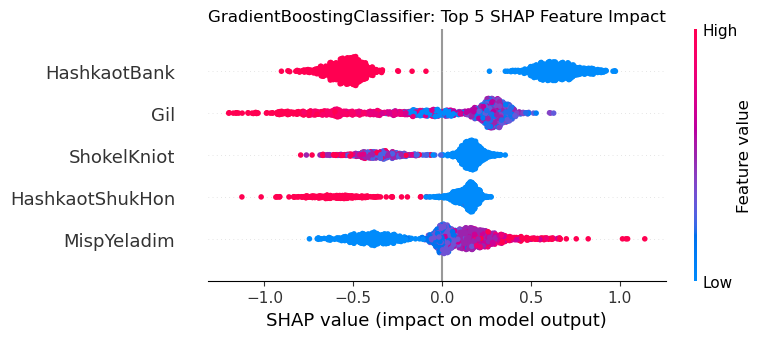

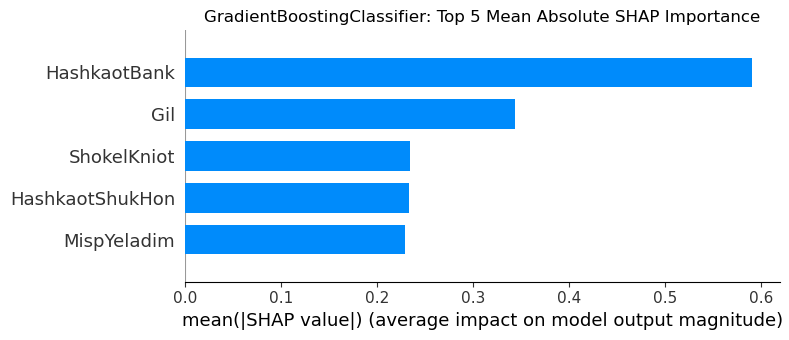

In [71]:
# ==========================
# SHAP Importance Table
# ==========================

mean_shap = (
    np.abs(shap_values)
    .mean(axis=0)
)


shap_importance = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Mean_SHAP": mean_shap
        }
    )
    .sort_values(
        by="Mean_SHAP",
        ascending=False
    )
)


print(
    f"\nSHAP Analysis for: {model_name}"
)


print(
    "\nTop SHAP Features:"
)


print(
    shap_importance
    .head(10)
    .to_string(
        index=False
    )
)



# ==========================
# Select Top 5 Features
# ==========================

top_features = (
    shap_importance
    .head(5)["Feature"]
    .tolist()
)


top_indices = [
    feature_names.index(feature)
    for feature in top_features
]


shap_values_top5 = (
    shap_values[
        :,
        top_indices
    ]
)


X_test_top5 = (
    X_test_shap[
        top_features
    ]
)



print(
    "\nTop 5 SHAP Features Selected:"
)

for feature in top_features:
    print(feature)



# ==========================
# SHAP Beeswarm Plot
# ==========================

plt.figure(
    figsize=(10, 6)
)


shap.summary_plot(
    shap_values_top5,
    X_test_top5,
    max_display=5,
    show=False
)


plt.title(
    f"{model_name}: Top 5 SHAP Feature Impact"
)


plt.tight_layout()

plt.show()



# ==========================
# SHAP Bar Plot
# ==========================

plt.figure(
    figsize=(10, 6)
)


shap.summary_plot(
    shap_values_top5,
    X_test_top5,
    plot_type="bar",
    max_display=5,
    show=False
)


plt.title(
    f"{model_name}: Top 5 Mean Absolute SHAP Importance"
)


plt.tight_layout()

plt.show()

In [72]:
print(saved_figures.keys())

dict_keys(['Fig_1', 'Fig_2', 'Fig_3', 'Fig_4', 'Fig_5', 'Fig_6', 'Fig_7'])


Saved figures: 7
Fig_1


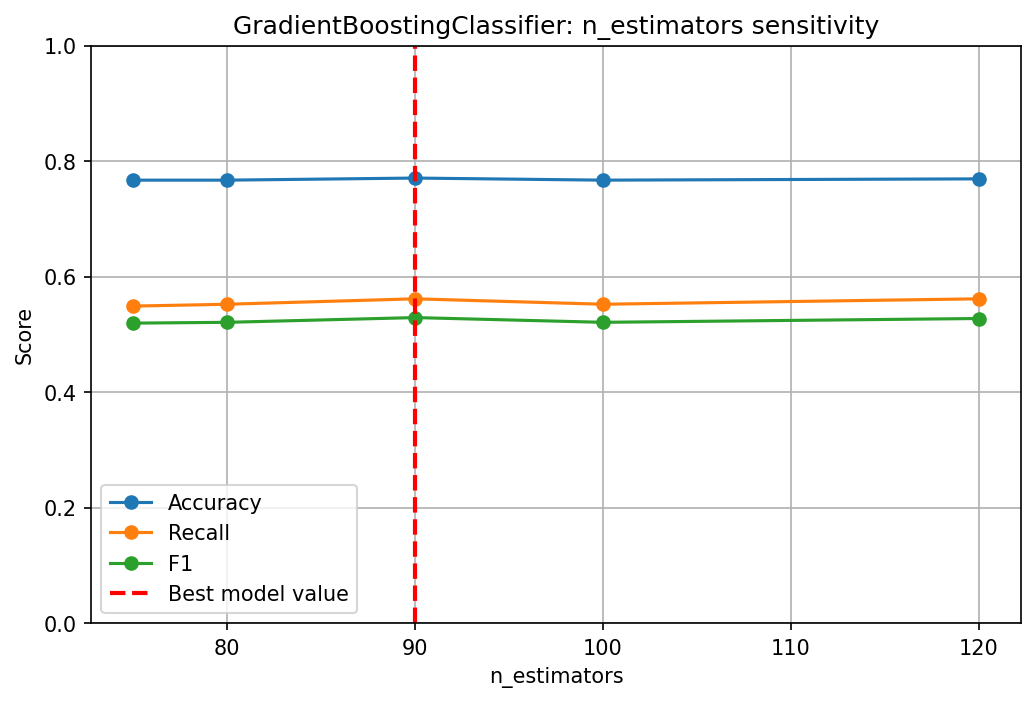

Fig_2


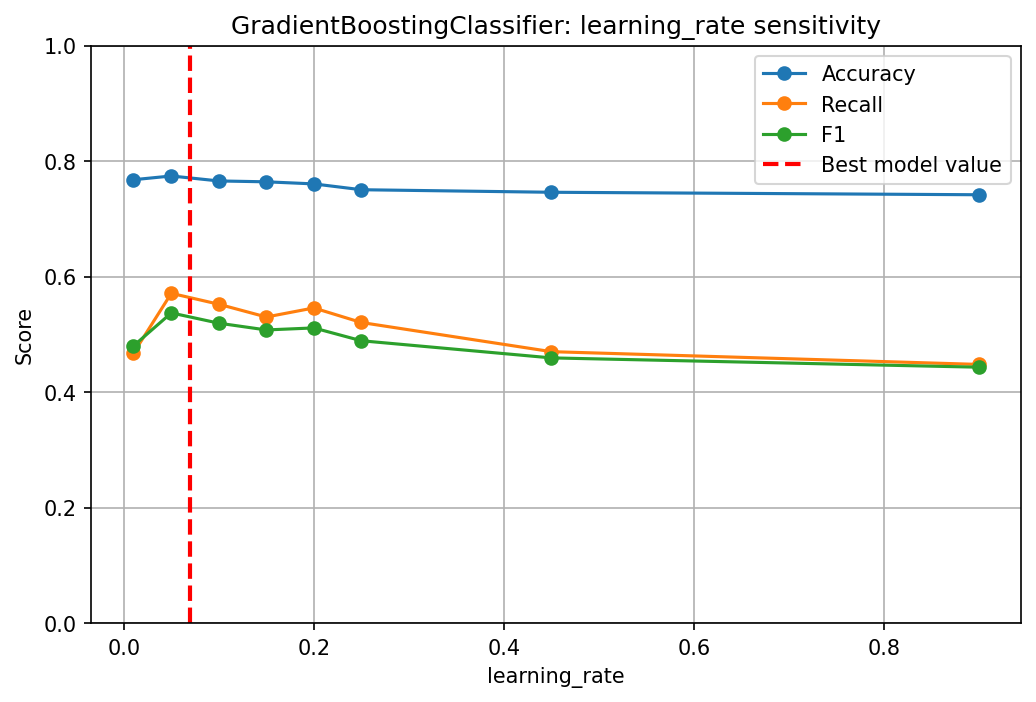

Fig_3


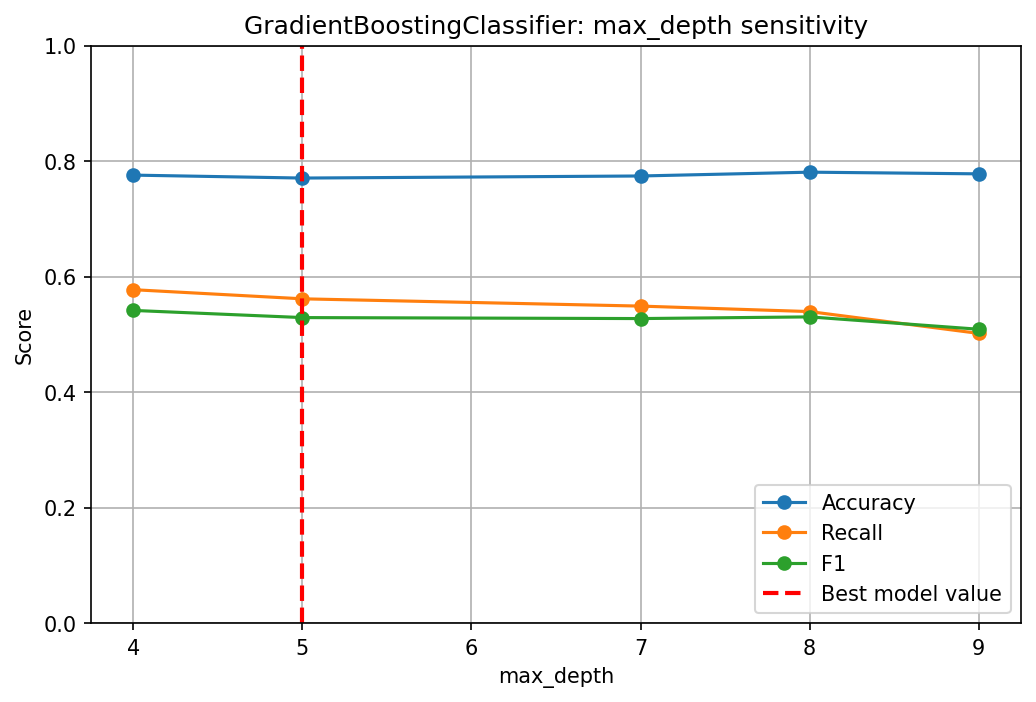

Fig_4


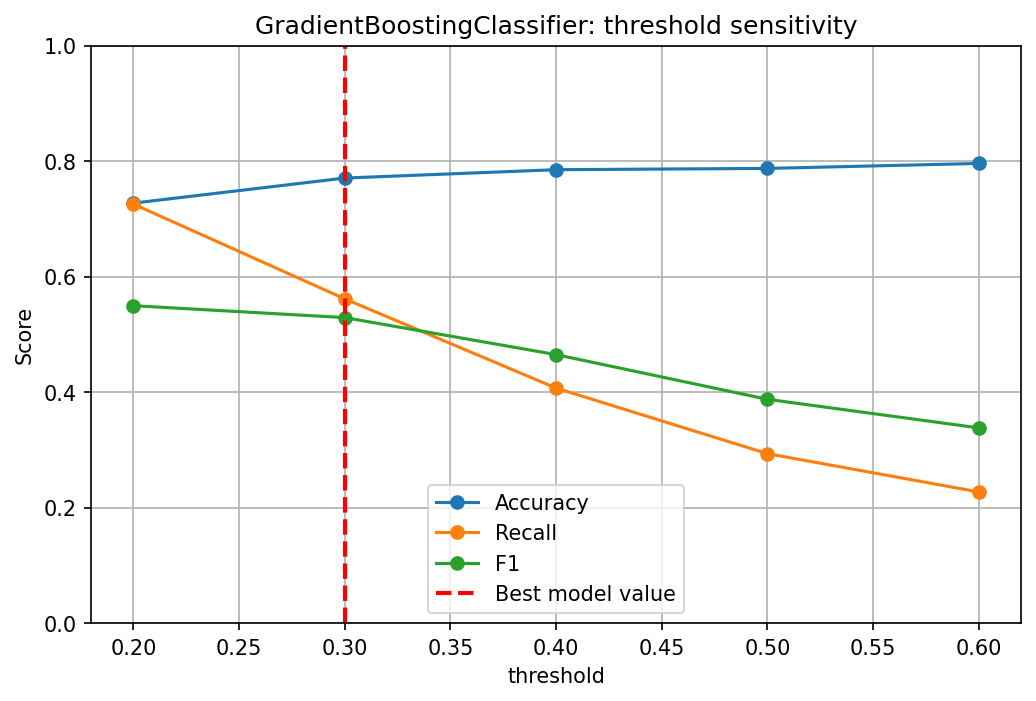

Fig_5


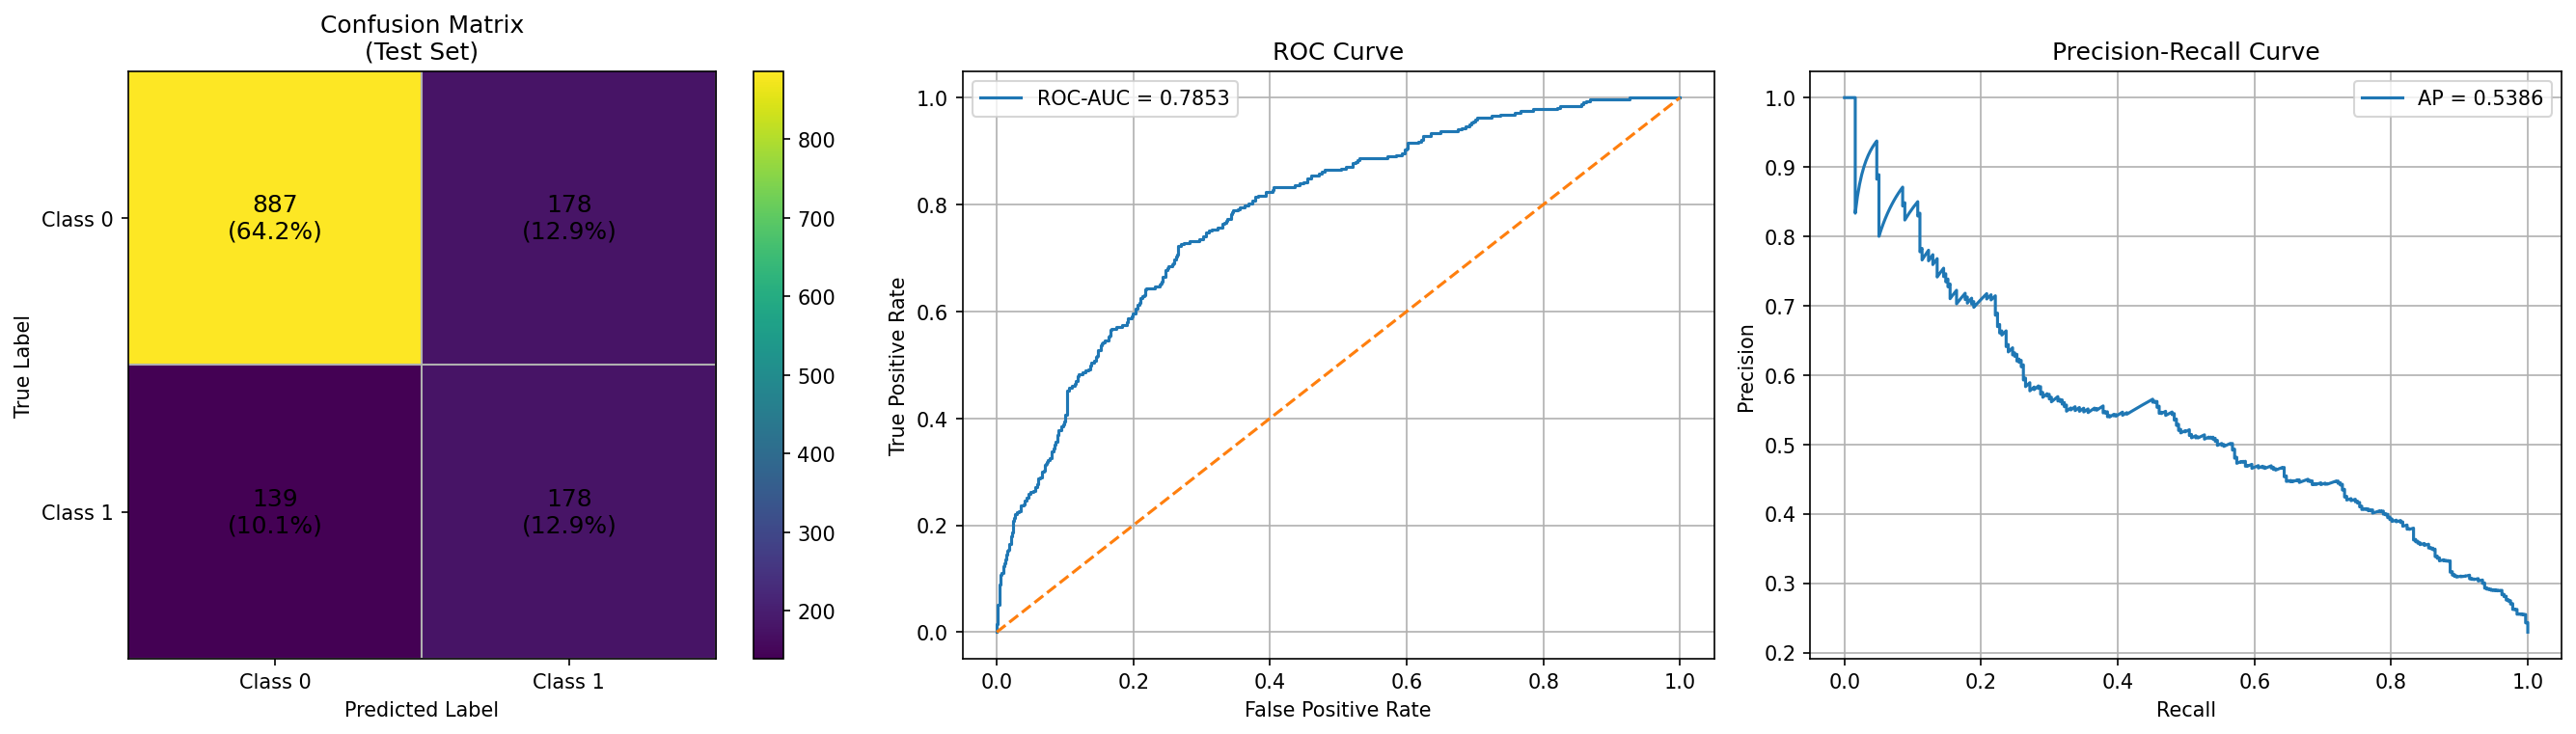

Fig_6


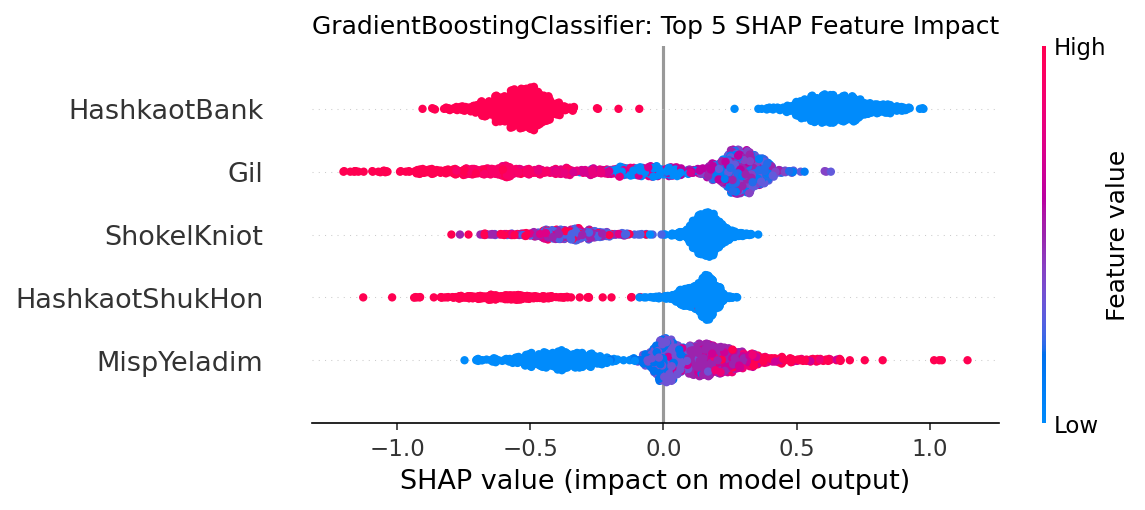

Fig_7


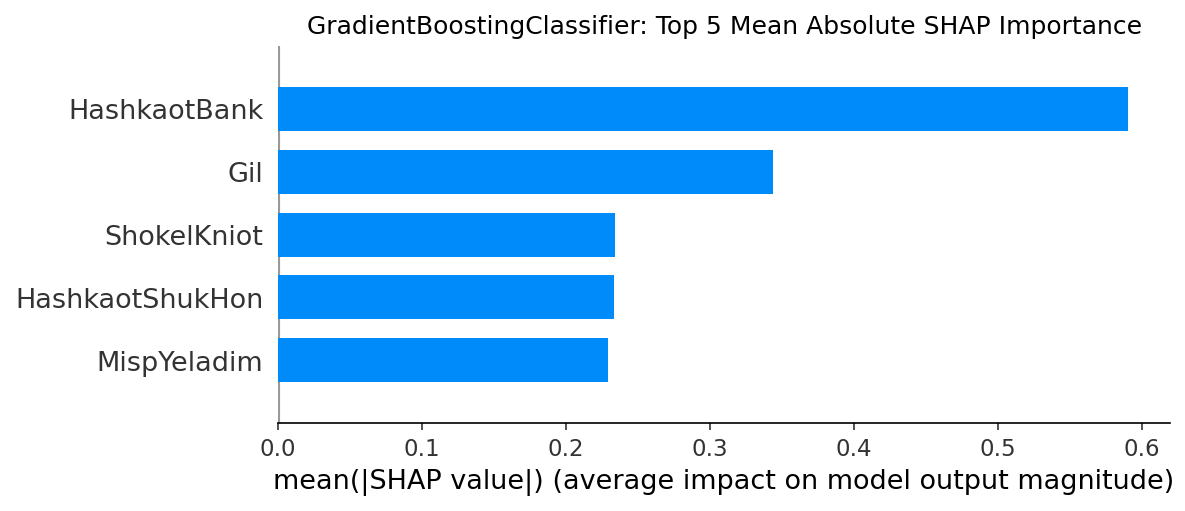

In [73]:
# ==========================
# Display Saved Figures Safely
# As Images
# ==========================

from IPython.display import display, Image
import io


print(
    "Saved figures:",
    len(saved_figures)
)


for name, fig in saved_figures.items():

    if len(fig.axes) == 0:
        continue


    print(name)


    # Save figure to memory buffer
    # without changing original figure

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight"
    )

    buffer.seek(0)


    # Display image with variable name

    display(
        Image(
            data=buffer.read(),
            width=350
        )
    )

# Part 3 - Interactive Dashboard (Or)

Reads the raw Social Survey again, runs the 10-question financial-literacy quiz gate, and builds the full multi-tab Plotly dashboard, then writes `index.html` to disk.

### Handoff from Part 2 - load `xgb_model.pkl`

Loads Ovad's trained pipeline so the dashboard's Model tab can display predictions, metrics, and SHAP explanations for the current session.


In [74]:
# Load the trained pipeline produced by Part 2.
#
# In a full Restart & Run All, Parts 1 and 2 have already populated the
# cross-part globals (model_data, features, saved_figures, etc.).  If we are
# starting fresh from Part 3 (e.g. Colab session restart), those globals do
# not exist and we restore them from the pickles that Parts 1 and 2 saved.
import joblib
import os

_PART3_REQUIRED = ["xgb_model.pkl", "shai_state.pkl", "ovad_state.pkl"]

def _need(v):
    return v not in globals()

_stale = any(_need(v) for v in
             ["model_data", "features", "saved_figures", "codebook",
              "structure_summary", "data_dictionary", "eda_groups", "raw"])

if _stale:
    _missing = [f for f in _PART3_REQUIRED if not os.path.exists(f)]
    if _missing and IN_COLAB:
        print(f"Missing handoff files on Colab: {_missing}")
        print("Upload them now (multi-select allowed):")
        from google.colab import files
        _uploaded = files.upload()
        _missing = [f for f in _PART3_REQUIRED if not os.path.exists(f)]
    if _missing:
        raise FileNotFoundError(
            f"Cannot run Part 3 alone without: {_missing}. "
            "Either run Parts 1 and 2 first in this session, or provide the "
            "three handoff files (xgb_model.pkl, shai_state.pkl, ovad_state.pkl)."
        )
    _shai_state = joblib.load("shai_state.pkl")
    _ovad_state = joblib.load("ovad_state.pkl")
    globals().update(_shai_state)
    globals().update(_ovad_state)
    print(f"Restored from pickles: {list(_shai_state.keys()) + list(_ovad_state.keys())}")

model = joblib.load("xgb_model.pkl")
print(f"Loaded xgb_model.pkl -> {type(model).__name__}")


Loaded xgb_model.pkl -> Pipeline


In [75]:
# 1. Environment check and imports
import sys
import importlib

print(f"Python {sys.version.split()[0]}")
REQUIRED = ["numpy", "pandas", "plotly", "openpyxl", "folium", "wordcloud",
            "PIL", "matplotlib"]
OPTIONAL = ["pyarrow"]  # pyarrow: fast data cache
missing = []
for pkg in REQUIRED + OPTIONAL:
    try:
        mod = importlib.import_module(pkg)
        tag = " (optional)" if pkg in OPTIONAL else ""
        print(f"  {pkg:<10} {getattr(mod, '__version__', 'installed')}{tag}")
    except ImportError:
        if pkg in REQUIRED:
            missing.append(pkg)
            print(f"  {pkg:<10} MISSING (required)")
        else:
            print(f"  {pkg:<10} not installed (optional)")
if missing:
    raise ImportError("Missing required packages. Run: pip install " + " ".join(missing))

import os
import io
import json
import base64
import webbrowser
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import get_plotlyjs
import folium
from wordcloud import WordCloud

px.defaults.template = "plotly_white"

Python 3.13.9
  numpy      2.3.5
  pandas     2.3.3
  plotly     6.3.0
  openpyxl   3.1.5
  folium     0.20.0
  wordcloud  1.9.6
  PIL        12.0.0
  matplotlib 3.10.6
  pyarrow    21.0.0 (optional)


In [76]:
# 2. Load data and define code -> label maps (used only for axis labels; raw values kept)

DATA_PATH = "data_24.xlsx"
CACHE_PATH = "data_24_cache.parquet"

if os.path.exists(CACHE_PATH):
    df = pd.read_parquet(CACHE_PATH)
else:
    df = pd.read_excel(DATA_PATH)
    try:
        df.to_parquet(CACHE_PATH)
    except Exception:
        pass
print(f"Social Survey 2024 loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

AGE_LABELS = {1: "20-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44", 6: "45-49",
              7: "50-54", 8: "55-59", 9: "60-64", 10: "65-74", 11: "75+"}
INCOME_LABELS = {1: "up to 2,000", 2: "2,001-4,000", 3: "4,001-6,000", 4: "6,001-8,000",
                 5: "8,001-10,000", 6: "10,001-14,000", 7: "14,001-19,000",
                 8: "19,001-27,000", 9: "27,001-40,000", 10: "40,001+"}
SAT_LABELS = {1: "Very satisfied", 2: "Satisfied", 3: "Not so satisfied", 4: "Not satisfied at all"}
LEFTOVER_LABELS = {1: "A lot is left over", 2: "Some is left over", 3: "Roughly breaks even",
                   4: "Runs short some months", 5: "Runs short every month"}
OPTIMISM_LABELS = {1: "Better off", 2: "About the same", 3: "Worse off"}

# CBS Nafa (subdistrict) codes + approximate center coordinates for the Israel map
NAFA = {
    11: {"name": "Jerusalem",           "lat": 31.7683, "lon": 35.2137},
    21: {"name": "Safed (Tzfat)",       "lat": 32.9646, "lon": 35.4960},
    22: {"name": "Kinneret",            "lat": 32.7196, "lon": 35.5497},
    23: {"name": "Yizrael",             "lat": 32.6111, "lon": 35.2892},
    24: {"name": "Akko",                "lat": 32.9281, "lon": 35.0817},
    29: {"name": "Golan",               "lat": 32.9915, "lon": 35.6952},
    31: {"name": "Haifa",               "lat": 32.7940, "lon": 34.9896},
    32: {"name": "Hadera",              "lat": 32.4380, "lon": 34.9195},
    41: {"name": "Sharon",              "lat": 32.3216, "lon": 34.8532},
    42: {"name": "Petah Tikva",         "lat": 32.0870, "lon": 34.8878},
    43: {"name": "Ramla",               "lat": 31.9293, "lon": 34.8664},
    44: {"name": "Rehovot",             "lat": 31.8942, "lon": 34.8103},
    51: {"name": "Tel Aviv",            "lat": 32.0853, "lon": 34.7818},
    61: {"name": "Ashkelon",            "lat": 31.6688, "lon": 34.5748},
    62: {"name": "Beer Sheva",          "lat": 31.2530, "lon": 34.7915},
    71: {"name": "Judea and Samaria",   "lat": 32.0857, "lon": 35.1000},
}

BEHAVIOR_ITEMS = [
    ("HisachonPensyoni", "Has a pension savings account"),
    ("HatavaKHishtalmut_wp", "Has Study Fund through employer"),
    ("HashkaotBank", "Invests through a bank"),
    ("HalvaaBank", "Has a bank loan"),
    ("InternetDohPensia", "Checks pension statement online"),
    ("InternetDohAshrai", "Checks credit report online"),
    ("InternetShilemMatbeaDig", "Paid with digital currency (crypto)"),
]

Social Survey 2024 loaded: 6,907 rows x 324 columns


In [77]:
# 3. Quiz definition. Population Yes-share attached to each behavior question is the
# share among ALL 6,907 respondents (raw), not among a filtered subset.

QUIZ = [
    {"id": "Q1", "kind": "knowledge",
     "text": "What is a typical annual management fee (dmei nihul) on a Study Fund (Keren Hishtalmut) in Israel?",
     "options": ["0.05% to 0.3%", "0.5% to 1%", "2% to 3%", "5% to 10%"], "correct": 1},
    {"id": "Q2", "kind": "knowledge",
     "text": "After how many years can a Study Fund be withdrawn tax free in the standard case (not retirement)?",
     "options": ["3 years", "5 years", "6 years", "10 years"], "correct": 2},
    {"id": "Q3", "kind": "behavior", "survey_var": "HisachonPensyoni", "yes_code": 1,
     "text": "Do you currently have a pension savings account?", "options": ["Yes", "No"]},
    {"id": "Q4", "kind": "behavior", "survey_var": "HatavaKHishtalmut_wp", "yes_code": 1,
     "text": "Do you have a Study Fund (Keren Hishtalmut) through your employer?", "options": ["Yes", "No"]},
    {"id": "Q5", "kind": "knowledge",
     "text": "What is Bitcoin?",
     "options": ["An Israeli technology stock", "A digital, decentralized currency",
                 "A government-issued bond", "A commodity ETF"], "correct": 1},
    {"id": "Q6", "kind": "behavior", "survey_var": "InternetShilemMatbeaDig", "yes_code": 1,
     "text": "Have you ever paid for something using a digital currency (for example Bitcoin)?",
     "options": ["Yes", "No"]},
    {"id": "Q7", "kind": "behavior", "survey_var": "HashkaotBank", "yes_code": 1,
     "text": "Do you invest through a bank (stocks, bonds, mutual funds)?", "options": ["Yes", "No"]},
    {"id": "Q8", "kind": "knowledge",
     "text": "If annual inflation is 5% and your savings account pays 3% interest, your real return is:",
     "options": ["+8%", "+2%", "minus 2%", "0%"], "correct": 2},
    {"id": "Q9", "kind": "behavior", "survey_var": "InternetDohPensia", "yes_code": 1,
     "text": "Do you check your pension statement online at least once a year?", "options": ["Yes", "No"]},
    {"id": "Q10", "kind": "knowledge",
     "text": "What best describes compound interest?",
     "options": ["Interest deducted from the principal each year",
                 "Interest earned also earns interest over time",
                 "A fixed dollar amount added yearly",
                 "A one time bonus paid at maturity"], "correct": 1},
]
for q in QUIZ:
    if q["kind"] == "behavior":
        # Raw share of Yes among ALL respondents (denominator = total N).
        q["popYes"] = round(float((df[q["survey_var"]] == q["yes_code"]).mean() * 100), 1)

print("Quiz ready:", len(QUIZ), "questions")

Quiz ready: 10 questions


In [78]:
# 4. Shared helpers used by remaining Part 3 cells.
#
# The original notebook had three tabs (Demographics, Behavior, Retirement) whose
# figures lived in this cell. Those tabs were removed during the merge. This cell
# now keeps only the pieces the surviving code needs:
#   - FIGS dict (populated by the Young Generation cell)
#   - _clean() / _label_v() styling helpers
#   - register() function
#   - age_order (used by the Young Generation cell)

FIGS = {}

def _clean(fig, height=430):
    """Remove all gridlines and zero-lines; set consistent typography and margins."""
    fig.update_layout(
        height=height, margin=dict(t=70, r=30, b=70, l=60),
        font=dict(family="Segoe UI, Arial", size=13),
        title=dict(font=dict(size=17), x=0.5, xanchor="center"),
        plot_bgcolor="white", paper_bgcolor="white",
    )
    fig.update_xaxes(showgrid=False, zeroline=False, showline=True,
                     linecolor="#d1d5db", ticks="outside", tickcolor="#d1d5db")
    fig.update_yaxes(showgrid=False, zeroline=False, showline=True,
                     linecolor="#d1d5db", ticks="outside", tickcolor="#d1d5db")
    return fig

def _label_v(fig, series):
    """Attach value labels above vertical bars."""
    fig.update_traces(text=[f"{int(v):,}" for v in series], textposition="outside",
                      cliponaxis=False, textfont=dict(size=12))
    return fig

def register(key, fig):
    """Save fig in FIGS memory AND display it inline in the notebook."""
    FIGS[key] = fig
    fig.show()
    return fig

age_order = [AGE_LABELS[k] for k in sorted(AGE_LABELS)]


In [79]:
# 4a. Young Generation tab (20-24 and 25-29): educational focus.
# All values are computed from the raw survey data - no cleaning applied.

young_mask = df["Gil"].isin([1, 2])         # 20-24 + 25-29
older_mask = df["Gil"] >= 3                 # 30+
n_young = int(young_mask.sum())
n_older = int(older_mask.sum())
print(f"Young cohort (20-29): {n_young:,} respondents")
print(f"Older cohort (30+):   {n_older:,} respondents")

# --- 1. Crypto & digital finance adoption by age (line chart)
crypto_by_age = df.groupby(df["Gil"].map(AGE_LABELS))["InternetShilemMatbeaDig"].apply(
    lambda s: (s == 1).mean() * 100).reindex(age_order)
credit_by_age = df.groupby(df["Gil"].map(AGE_LABELS))["InternetDohAshrai"].apply(
    lambda s: (s == 1).mean() * 100).reindex(age_order)
pension_online_by_age = df.groupby(df["Gil"].map(AGE_LABELS))["InternetDohPensia"].apply(
    lambda s: (s == 1).mean() * 100).reindex(age_order)

fig = go.Figure()
for series, name, color in [
    (crypto_by_age,          "Paid with crypto",           "#e55353"),
    (credit_by_age,          "Checks credit report online","#f6b73c"),
    (pension_online_by_age,  "Checks pension online",      "#2c7be5"),
]:
    fig.add_trace(go.Scatter(
        x=age_order, y=series.values, mode="lines+markers+text",
        text=[f"{v:.0f}%" for v in series.values], textposition="top center",
        name=name, line=dict(width=3, color=color), marker=dict(size=9),
        textfont=dict(size=11)))
fig.update_layout(
    title=dict(text="Digital finance adoption by age", x=0.5, xanchor="center",
               font=dict(size=17)),
    height=470, yaxis=dict(ticksuffix="%", range=[0, 60]),
    paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=80, r=30, b=60, l=60),
    legend=dict(x=0.5, xanchor="center", y=-0.15, orientation="h"))
fig.update_xaxes(showgrid=False, zeroline=False, showline=True, linecolor="#d1d5db")
fig.update_yaxes(showgrid=False, zeroline=False, showline=True, linecolor="#d1d5db")
register("fig-young-digital", fig)

# --- 2. Retirement planning satisfaction, 20-29 only
sat_young_series = df.loc[young_mask, "MerutzeTichnunFinPrisha"].map(
    {**SAT_LABELS, 888888: "Don't know (888888)"}).value_counts().reindex(
    [SAT_LABELS[k] for k in sorted(SAT_LABELS)] + ["Don't know (888888)"])
sat_young_df = sat_young_series.rename_axis("Satisfaction").reset_index(name="Respondents")
fig = px.bar(sat_young_df, x="Satisfaction", y="Respondents",
             title=f"Retirement planning satisfaction, 20-29 cohort only "
                   f"(n = {n_young:,})",
             color="Respondents", color_continuous_scale="RdYlGn_r")
fig.update_traces(text=[f"{int(v):,}" if pd.notna(v) else ""
                          for v in sat_young_df["Respondents"]],
                  textposition="outside", cliponaxis=False)
fig.update_layout(coloraxis_showscale=False)
register("fig-young-satisfaction", _clean(fig))

print(f"Young Generation figures added: {sum(1 for k in FIGS if k.startswith('fig-young'))}")

Young cohort (20-29): 1,459 respondents
Older cohort (30+):   5,448 respondents


Young Generation figures added: 2


In [80]:
# 4b. Word cloud (financial context only)

# Each token appears in the cloud with a weight equal to its raw count in the survey.
# Tokens are drawn from finance-related variables only; no non-financial content is included.

def yes_count(var):
    return int((df[var] == 1).sum())

def nonmissing_count(var):
    return int(len(df) - (df[var].isin([888888, 999999])).sum())

FIN_WEIGHTS = {
    "Pension":               yes_count("HisachonPensyoni"),
    "Study Fund":            yes_count("HatavaKHishtalmut_wp"),
    "Keren Hishtalmut":      yes_count("HatavaKHishtalmut_wp"),
    "Retirement":            nonmissing_count("MerutzeTichnunFinPrisha"),
    "Bank":                  yes_count("HashkaotBank") + yes_count("HalvaaBank"),
    "Investments":           yes_count("HashkaotBank"),
    "Stocks":                yes_count("HashkaotBank"),
    "Bonds":                 yes_count("HashkaotBank"),
    "Loan":                  yes_count("HalvaaBank"),
    "Mortgage":              yes_count("HalvaaBank"),
    "Credit":                yes_count("InternetDohAshrai"),
    "Bitcoin":               yes_count("InternetShilemMatbeaDig"),
    "Crypto":                yes_count("InternetShilemMatbeaDig"),
    "Digital Currency":      yes_count("InternetShilemMatbeaDig"),
    "Income":                nonmissing_count("HachnasaKoleletNeto"),
    "Salary":                nonmissing_count("HachnasaAvoda"),
    "Savings":               yes_count("HishtameshHisachon"),
    "Management Fees":       nonmissing_count("HatavaKHishtalmut_wp"),
    "Compound Interest":     nonmissing_count("MerutzeTichnunFinPrisha"),
    "Inflation":             nonmissing_count("MerutzeKalkali"),
    "Budget":                nonmissing_count("NisharKesef"),
    "Household Expenses":    nonmissing_count("MichyaHachnasaMineches"),
    "Financial Planning":    nonmissing_count("MerutzeTichnunFinPrisha"),
    "Financial Decisions":   nonmissing_count("DerechHachlataFin"),
    "Economic Optimism":     nonmissing_count("OptimiyutKalkalit"),
    "Wealth":                nonmissing_count("MerutzeKalkali"),
    "Debt":                  yes_count("HalvaaBank"),
    "Tax":                   nonmissing_count("HachnasaAvoda"),
    "Portfolio":             yes_count("HashkaotBank"),
    "Diversification":       yes_count("HashkaotBank"),
    "Passive Income":        yes_count("HashkaotBank"),
    "Provident Fund":        yes_count("HatavaKHishtalmut_wp"),
}

wc = WordCloud(width=1200, height=520, background_color="white",
               colormap="viridis", prefer_horizontal=0.85,
               relative_scaling=0.55, min_font_size=14,
               max_words=len(FIN_WEIGHTS)).generate_from_frequencies(FIN_WEIGHTS)
buf = io.BytesIO()
wc.to_image().save(buf, format="PNG")
WORDCLOUD_B64 = base64.b64encode(buf.getvalue()).decode("ascii")
print("Word cloud generated,", len(WORDCLOUD_B64), "chars b64,", len(FIN_WEIGHTS), "financial terms")

Word cloud generated, 153028 chars b64, 32 financial terms


In [81]:
# 4c. Folium map of Israel: respondent counts per Nafa subdistrict (raw, no cleaning).

nafa_counts = df["nafa"].value_counts().to_dict()

# Fixed center + zoom sized so the whole surveyed area (Golan -> Beer Sheva)
# is visible in the 600px iframe. No fit_bounds - it over-zooms in some browsers.
m = folium.Map(location=[31.85, 35.10], zoom_start=8,
               tiles="cartodbpositron", control_scale=True, prefer_canvas=False,
               min_zoom=7, max_zoom=12,
               max_bounds=True)

# Bubbles: linear scaling but capped so the largest bubble (Tel Aviv, 1,093) doesn't
# swallow smaller neighbors like Ashkelon.
max_c = max(nafa_counts.values()) if nafa_counts else 1
counts_present = []

for code_val, meta in NAFA.items():
    n = int(nafa_counts.get(code_val, 0))
    if n == 0:
        continue
    # sqrt scaling: bubble AREA proportional to count (visually more accurate)
    radius = 6 + 22 * (n / max_c) ** 0.5
    popup_html = (
        f"<div style='font-size:13px;padding:2px 4px'>"
        f"<b style='font-size:14px;color:#1f4e9e'>{meta['name']}</b><br>"
        f"<span style='color:#6b7280'>Nafa code: {code_val}</span><br>"
        f"Respondents: <b>{n:,}</b><br>"
        f"Share of survey: <b>{n / len(df) * 100:.1f}%</b>"
        f"</div>"
    )
    folium.CircleMarker(
        location=[meta["lat"], meta["lon"]],
        radius=radius,
        color="#1f5fc4", weight=1.5,
        fill=True, fill_color="#2c7be5", fill_opacity=0.55,
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=folium.Tooltip(
            f"<b>{meta['name']}</b>: {n:,} respondents "
            f"({n / len(df) * 100:.1f}%)",
            sticky=True,
        ),
    ).add_to(m)
    counts_present.append((meta["lat"], meta["lon"]))

# Do NOT call fit_bounds - Folium 0.20 tends to over-zoom to the tightest
# level that fits, which for a small country like Israel hits max_zoom.
# The zoom_start=8 above frames Golan through Beer Sheva at 600px height.

# Small legend anchored to the top-right corner of the map (Leaflet native).
legend_html = """
<div style="
  position:absolute; top:12px; right:12px; z-index:1000;
  background:#fff; padding:10px 14px; border-radius:8px;
  border:1px solid #e3e8ee; box-shadow:0 2px 6px rgba(0,0,0,.08);
  font-family:-apple-system,'Segoe UI',Arial,sans-serif; font-size:12px;
  color:#111827; max-width:220px;">
  <div style="font-weight:700;margin-bottom:4px;color:#1f4e9e">
    Respondents per subdistrict
  </div>
  <div style="color:#4b5563">Bubble size = respondent count (sqrt scale).
  Hover for the exact number, click for details.</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_html_full = m.get_root().render()
MAP_SRCDOC = map_html_full
print("Folium map rendered:", len(MAP_SRCDOC), "chars for",
      len(counts_present), "subdistricts, max count:", max_c)

Folium map rendered: 27964 chars for 16 subdistricts, max count: 1093


### Assemble content for the redesigned 7-tab dashboard

Uses Shai's + Ovad's in-memory dataframes and Ovad's `saved_figures` dict to build the HTML blocks that the tab panels below will show. Or's original raw-data charts (gender donut, folium map, word cloud, etc.) are dropped by design.

New tabs:
- **Overview** - KPI cards + Working principles + Structure summary + raw.head() after cleaning + 37 features
- **Data Quality** - Missing report + Data dictionary + Drop candidates + Codebook (Shai)
- **Descriptives** - 3 EDA group figures + value counts + risk-score distribution + Phi-K heatmap (Shai)
- **Model Performance** - Baseline comparison + 3 baselines + CM+ROC+PR + hyperparam sensitivity (Ovad)
- **Model Interpretation** - 6 SHAP figures (Ovad)
- **Your Profile** - gauge + you-vs-population + quiz answers (Or, kept)
- **Young Generation** - the whole existing tab (Or, kept)


In [ ]:
# ============================================================
# Assemble HTML blocks for each new tab
# ============================================================
# Reads Shai + Ovad data from memory and builds:
#   - OVERVIEW_HTML        (new content replaces old Overview)
#   - DATA_QUALITY_HTML    (new tab)
#   - DESCRIPTIVES_HTML    (new tab)
#   - MODEL_PERF_HTML      (new tab)
#   - MODEL_INTERP_HTML    (new tab)
# Kept memory-light: no phik matrix, tables capped, figures closed after encode.

import io
import base64
import matplotlib.pyplot as plt


def _fig_to_img(fig, alt="figure", max_width_px=1000):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=90, bbox_inches="tight", facecolor="white")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    buf.close()
    return (f'<img src="data:image/png;base64,{b64}" alt="{alt}" '
            f'style="max-width:100%;width:{max_width_px}px;height:auto;'
            f'display:block;margin:12px auto;border:1px solid #e3e8ee;'
            f'border-radius:8px;background:#fff">')


def _df_to_html(df, max_rows=None, classes="datatable"):
    if max_rows is not None and len(df) > max_rows:
        note = f'<div class="table-note">Showing first {max_rows} of {len(df):,} rows</div>'
        html = df.head(max_rows).to_html(classes=classes, index=False,
                                          na_rep="", border=0, escape=True)
        return note + html
    return df.to_html(classes=classes, index=False, na_rep="", border=0, escape=True)


# ------------------------------------------------------------
# OVERVIEW tab
# ------------------------------------------------------------
_working_principles_html = """
<h3>Working principles (Shai)</h3>
<ol class="lead-list">
  <li>Keep the raw file unchanged.</li>
  <li>Convert survey-specific non-response codes such as <code>888888</code>
      and <code>999999</code> into real missing values (<code>NaN</code>).</li>
  <li>Document missingness instead of silently deleting many rows.</li>
  <li>Do not scale features here; scaling belongs to the modeling pipeline.</li>
  <li>Preserve provenance: every derived variable can be traced back to the codebook.</li>
</ol>
"""

try:
    _structure_summary_html = _df_to_html(structure_summary, max_rows=10)
except NameError:
    _structure_summary_html = '<p class="lead">structure_summary not defined.</p>'

_raw_after_cleaning_html = _df_to_html(df.head(10), max_rows=10)

try:
    _features_list = features
except NameError:
    _features_list = list(model_data.columns)

_features_html = (
    "<h3>Features selected for the model (Ovad)</h3>"
    "<div class=\"features-grid\">"
    + "".join(f'<span class="feature-chip">{f}</span>' for f in _features_list)
    + "</div>"
)

_kpi_cards_html = f"""
<div class="kpi-row">
  <div class="kpi-card"><div class="kpi-num">{len(raw):,}</div>
       <div class="kpi-label">Respondents</div></div>
  <div class="kpi-card"><div class="kpi-num">{raw.shape[1]:,}</div>
       <div class="kpi-label">Variables (raw)</div></div>
  <div class="kpi-card"><div class="kpi-num">{model_data.shape[1] - 1:,}</div>
       <div class="kpi-label">Predictors used</div></div>
  <div class="kpi-card"><div class="kpi-num">2024</div>
       <div class="kpi-label">Survey year</div></div>
</div>
"""

_wordcloud_html = (
    "<h3>Financial themes in the survey</h3>"
    '<p class="lead">Word cloud built from finance-related survey items. '
    'Size scales with respondent count.</p>'
    f'<div class="wc-box">'
    f'<img src="data:image/png;base64,{WORDCLOUD_B64}" '
    f'alt="Financial terms word cloud">'
    f'</div>'
)

OVERVIEW_HTML = (
    _kpi_cards_html
    + _working_principles_html
    + "<h3>Structure summary (Shai)</h3>"
    + f'<div class="table-wrap">{_structure_summary_html}</div>'
    + "<h3>Raw data after cleaning (df.head(10))</h3>"
    + f'<div class="table-wrap">{_raw_after_cleaning_html}</div>'
    + _features_html
    + _wordcloud_html
)


# ------------------------------------------------------------
# DATA QUALITY tab
# ------------------------------------------------------------
try:
    _missing_report_df = structure_summary.loc[
        :, [c for c in ["column", "missing_pct"] if c in structure_summary.columns]
    ]
    if "missing_pct" in _missing_report_df.columns:
        _missing_report_df = _missing_report_df.sort_values("missing_pct", ascending=False)
    # Compact multi-column grid: each variable = one small tile.
    _tiles = []
    for _, _row in _missing_report_df.iterrows():
        _col = str(_row.get("column", ""))
        _pct = _row.get("missing_pct", 0.0)
        try:
            _pct_num = float(_pct)
        except (TypeError, ValueError):
            _pct_num = 0.0
        if _pct_num >= 50:
            _pct_color = "#e55353"
        elif _pct_num >= 20:
            _pct_color = "#f6b73c"
        else:
            _pct_color = "#2fb380"
        _tiles.append(
            f'<div style="display:flex;justify-content:space-between;align-items:center;'
            f'padding:7px 11px;background:#f8f9fc;border:1px solid #eef1f5;'
            f'border-radius:6px;font-size:12.5px;gap:8px">'
            f'<span style="color:#111827;font-weight:500;overflow:hidden;'
            f'text-overflow:ellipsis;white-space:nowrap">{_col}</span>'
            f'<span style="color:{_pct_color};font-weight:600;font-variant-numeric:tabular-nums">'
            f'{_pct_num:.1f}%</span></div>'
        )
    _missing_report_html = (
        '<div style="display:grid;'
        'grid-template-columns:repeat(auto-fill,minmax(220px,1fr));'
        'gap:6px;margin-top:8px">'
        + "".join(_tiles) +
        '</div>'
    )
except NameError:
    _missing_report_html = '<p class="lead">structure_summary not available.</p>'

try:
    _data_dictionary_html = _df_to_html(data_dictionary, max_rows=10)
except NameError:
    _data_dictionary_html = '<p class="lead">data_dictionary not available.</p>'

try:
    _drop_df = data_dictionary.query(
        "decision == 'Drop candidate' or variable.isna()"
    )
    _keep_cols = [c for c in ["column", "missing_pct", "variable", "description",
                               "note", "decision", "reason"] if c in _drop_df.columns]
    _drop_candidates_html = _df_to_html(_drop_df[_keep_cols], max_rows=10)
except Exception:
    _drop_candidates_html = '<p class="lead">Drop candidates list not available.</p>'

try:
    _codebook_html = _df_to_html(codebook, max_rows=30)
except NameError:
    _codebook_html = '<p class="lead">codebook not available.</p>'

DATA_QUALITY_HTML = (
    "<h3>Missing values report per column</h3>"
    + f'<div class="table-wrap">{_missing_report_html}</div>'
    + "<h3>Data dictionary (enriched with CBS codebook)</h3>"
    + f'<div class="table-wrap">{_data_dictionary_html}</div>'
    + "<h3>Drop candidates flagged by Shai</h3>"
    + f'<div class="table-wrap">{_drop_candidates_html}</div>'
    + "<h3>CBS codebook (preprocessed for the merged notebook)</h3>"
    + f'<div class="table-wrap">{_codebook_html}</div>'
)


# ------------------------------------------------------------
# DESCRIPTIVES tab (lightweight - no phik, capped groups)
# ------------------------------------------------------------
def _lookup_label(_var, _code):
    """Return the (English) code_title for a (variable, code) pair from the codebook,
    falling back to the raw code if no label is available."""
    try:
        _match = codebook.loc[
            (codebook["variavle_name"] == _var) & (codebook["code"] == _code),
            "code_title",
        ]
        if len(_match) and pd.notna(_match.iloc[0]):
            return str(_match.iloc[0]).strip()
    except Exception:
        pass
    return str(_code)

_descriptives_blocks = ""
try:
    for group_name, variables in list(eda_groups.items()):
        sub_html = ""
        for var in variables[:5]:
            if var not in df.columns:
                continue
            counts = df[var].value_counts().sort_index().head(15)
            if len(counts) == 0:
                continue
            top = counts.max()
            sub_html += f'<h4>{var}</h4><div class="mini-bar-plot">'
            for idx, v in counts.items():
                pct = max(1, int(v / top * 100))
                label = _lookup_label(var, idx)[:36]
                sub_html += (f'<div class="bar-row"><span class="bar-label">{label}</span>'
                             f'<span class="bar-fill" style="width:{pct}%"></span>'
                             f'<span class="bar-count">{int(v):,}</span></div>')
            sub_html += '</div>'
        _descriptives_blocks += (
            f'<div class="group-block">'
            f'<h3>{group_name.replace("_", " ").title()}</h3>{sub_html}</div>'
        )
except (NameError, AttributeError):
    _descriptives_blocks = '<p class="lead">EDA groups not available.</p>'

try:
    _risk_series = model_data["financial_risk_score"].value_counts().sort_index()
    _top = _risk_series.max() or 1
    _risk_html = '<h3>Distribution of financial_risk_score</h3><div class="mini-bar-plot">'
    for idx, v in _risk_series.items():
        pct = int(v / _top * 100)
        _risk_html += (f'<div class="bar-row"><span class="bar-label">Score {int(idx)}</span>'
                       f'<span class="bar-fill risk-bar" style="width:{pct}%"></span>'
                       f'<span class="bar-count">{int(v):,}</span></div>')
    _risk_html += '</div>'
except Exception:
    _risk_html = '<p class="lead">financial_risk_score not available.</p>'

DESCRIPTIVES_HTML = (
    "<h3>Descriptive breakdowns per variable group (Shai)</h3>"
    + _descriptives_blocks
    + _risk_html
    + '<p class="lead" style="margin-top:20px;color:#7a7a7a;font-size:12.5px">'
    + 'Phi-K multicollinearity matrix omitted from this build to keep the kernel light.</p>'
)


# ------------------------------------------------------------
# MODEL PERFORMANCE + INTERPRETATION tabs
# ------------------------------------------------------------
_saved_names = list(saved_figures.keys()) if "saved_figures" in dir() else []

def _embed_figs(names):
    if not names:
        return '<p class="lead">No captured figures.</p>'
    parts = []
    for n in names:
        if n in saved_figures:
            fig = saved_figures[n]
            parts.append(f'<div class="chart-wrap">{_fig_to_img(fig, alt=n)}</div>')
            # Close it to release memory
            try:
                plt.close(fig)
            except Exception:
                pass
    return "".join(parts)

_perf_names = _saved_names[:6]
_interp_names = _saved_names[6:12]

try:
    _baseline_table = _df_to_html(cv_results.round(3), max_rows=30)
    _baseline_html = ('<h3>Baseline model comparison (Ovad)</h3>'
                      f'<div class="table-wrap">{_baseline_table}</div>')
except (NameError, AttributeError):
    _baseline_html = '<p class="lead">Baseline comparison table not available.</p>'

MODEL_PERF_HTML = _baseline_html + "<h3>Performance figures</h3>" + _embed_figs(_perf_names)

MODEL_INTERP_HTML = (
    "<h3>SHAP interpretation (Ovad)</h3>"
    + '<p class="lead">Contribution of each feature to the model\'s predictions.</p>'
    + _embed_figs(_interp_names)
)


# ------------------------------------------------------------
# Sanity print
# ------------------------------------------------------------
print(f"OVERVIEW_HTML       : {len(OVERVIEW_HTML):>7,} chars")
print(f"DATA_QUALITY_HTML   : {len(DATA_QUALITY_HTML):>7,} chars")
print(f"DESCRIPTIVES_HTML   : {len(DESCRIPTIVES_HTML):>7,} chars")
print(f"MODEL_PERF_HTML     : {len(MODEL_PERF_HTML):>7,} chars")
print(f"MODEL_INTERP_HTML   : {len(MODEL_INTERP_HTML):>7,} chars")
print(f"saved_figures       : {len(saved_figures) if 'saved_figures' in dir() else 0} figures captured")


In [83]:
# 5. Generate index.html (standalone dashboard page) and open it

HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">
<meta name="apple-mobile-web-app-capable" content="yes">
<meta name="apple-mobile-web-app-status-bar-style" content="black-translucent">
<meta name="theme-color" content="#1f4e9e">
<title>Financial Literacy and Retirement Readiness</title>
<script>__PLOTLYJS__</script>
<style>
:root {
  --blue:#2c7be5; --blue-d:#1f5fc4; --green:#2fb380; --red:#e55353;
  --amber:#f6b73c; --bg:#f5f7fa; --card:#ffffff;
  --border:#e3e8ee; --text:#111827; --muted:#4b5563;
}
* { box-sizing:border-box; -webkit-tap-highlight-color:transparent; }
html, body { margin:0; padding:0; }
html { -webkit-text-size-adjust:100%; text-size-adjust:100%; }
body {
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI','Helvetica Neue',Arial,sans-serif;
  background:var(--bg); color:var(--text); line-height:1.5; font-size:15px;
  overflow-x:hidden;
}

/* Top bar */
.topbar {
  background:linear-gradient(135deg,#1f4e9e 0%,#2c7be5 100%);
  color:#fff; padding:24px 20px;
  padding-top:calc(24px + env(safe-area-inset-top));
  padding-left:calc(20px + env(safe-area-inset-left));
  padding-right:calc(20px + env(safe-area-inset-right));
  box-shadow:0 2px 8px rgba(31,78,158,.18);
  position:relative;
}
.topbar-inner {
  max-width:1180px; margin:0 auto;
  display:flex; align-items:center; gap:16px;
  justify-content:center;
}
.topbar-titles { flex:1; text-align:center; min-width:0; }
.topbar h1 { margin:0; font-size:24px; font-weight:700; letter-spacing:.2px; }
.topbar .sub { opacity:.9; font-size:14px; margin-top:4px; }
.topbar .home-btn {
  background:rgba(255,255,255,.16); border-color:rgba(255,255,255,.55);
  color:#fff; flex-shrink:0;
}
.topbar .home-btn:hover { background:#fff; color:#1f5fc4; }
@media (max-width:640px) {
  .topbar-inner { flex-direction:column; gap:12px; }
  .topbar h1 { font-size:20px; }
  .topbar .sub { font-size:12.5px; }
}

/* Layout */
.wrap { max-width:1180px; margin:0 auto; padding:24px 16px 60px; }
.card {
  background:var(--card); border:1px solid var(--border); border-radius:12px;
  padding:22px 22px; margin-bottom:18px; box-shadow:0 1px 3px rgba(16,24,40,.05);
}
.card h2 { margin:0 0 6px 0; font-size:20px; color:var(--text); font-weight:700; text-align:center; }
.card h3 { margin:22px 0 8px 0; font-size:16px; color:var(--text); font-weight:600; text-align:center; }
.card .lead { color:var(--muted); font-size:14px; margin:0 0 16px 0; text-align:center; }
.hint { background:#eef4ff; border-left:4px solid var(--blue);
        padding:12px 14px; border-radius:8px; margin:16px 0; color:#1f2937; font-size:14px; }

/* Quiz */
.quiz-intro { background:var(--blue); color:#fff; border:none; }
.quiz-intro h2 { color:#fff; }
.quiz-intro .lead { color:rgba(255,255,255,.9); }
.quiz-body { max-width:760px; margin:0 auto; }
.question { margin:20px 0 6px 0; }
.qtext { font-weight:600; margin-bottom:10px; color:var(--text); font-size:15px; }
.opt { display:block; padding:12px 14px; margin:6px 0; border:1.5px solid var(--border);
       border-radius:10px; cursor:pointer; background:#fbfcfe; transition:all .12s ease;
       user-select:none; min-height:44px; /* iOS tap target */ }
.opt:active { background:#e8f1ff; }
.opt:hover { border-color:var(--blue); background:#f0f6ff; }
.opt input { margin-right:11px; vertical-align:middle; transform:scale(1.15); }
.opt input:checked ~ span { font-weight:600; }
.opt:has(input:checked) { border-color:var(--blue); background:#e8f1ff; }
#progress { font-weight:600; color:var(--muted); margin:18px 0 12px 0;
            font-size:14px; text-align:center; }
.btn-row { text-align:center; }
.btn {
  background:var(--blue); color:#fff; border:none; border-radius:10px;
  padding:14px 36px; font-size:15px; font-weight:600; cursor:pointer;
  transition:background .12s ease; box-shadow:0 2px 6px rgba(44,123,229,.25);
  min-height:48px; /* iOS tap target */
}
.btn:hover { background:var(--blue-d); }
.btn:active { background:var(--blue-d); }
.errbox {
  display:none; margin-top:14px; padding:12px 16px;
  border-left:4px solid var(--red); background:#fdf1f1; border-radius:8px;
  color:#7f1d1d; font-size:14px; text-align:left;
}
.banner {
  padding:14px 18px; border-left:4px solid var(--green); background:#eefaf5;
  border-radius:10px; margin-bottom:20px; font-size:15px; color:#065f46;
  text-align:center;
  display:flex; flex-wrap:wrap; align-items:center; justify-content:center; gap:14px;
}
.banner .banner-text { flex:1 1 auto; min-width:200px; }

/* Back-to-quiz pill button */
.home-btn {
  background:#fff; border:1.5px solid var(--green); color:#065f46;
  border-radius:999px; padding:9px 18px; font-size:14px; font-weight:600;
  cursor:pointer; transition:all .12s ease; min-height:40px;
  display:inline-flex; align-items:center; gap:8px; flex-shrink:0;
}
.home-btn:hover { background:var(--green); color:#fff; }
.home-btn:active { background:#207f5b; color:#fff; }
.home-btn svg { width:16px; height:16px; }

/* Tabs - horizontally scrollable on mobile, centered on desktop */
.tabs {
  position:sticky; top:0; z-index:20; background:var(--bg);
  padding:12px 0 8px; display:flex; gap:8px;
  border-bottom:1px solid var(--border); margin-bottom:14px;
  overflow-x:auto; overflow-y:hidden;
  scrollbar-width:none; -ms-overflow-style:none;
  -webkit-overflow-scrolling:touch;
  justify-content:flex-start;
}
.tabs::-webkit-scrollbar { display:none; }
@media (min-width: 780px) { .tabs { flex-wrap:wrap; justify-content:center; overflow:visible; } }
.tabbtn {
  background:#fff; border:1.5px solid var(--border); border-radius:10px;
  padding:12px 18px; font-size:14px; cursor:pointer; color:#374151;
  transition:all .12s ease; font-weight:500; flex-shrink:0;
  min-height:44px; white-space:nowrap;
}
.tabbtn:hover { border-color:var(--blue); color:var(--blue); }
.tabbtn.active {
  background:var(--blue); border-color:var(--blue); color:#fff; font-weight:600;
  box-shadow:0 2px 6px rgba(44,123,229,.3);
}
.panel { display:none; }

/* KPIs - centered */
.kpis { display:flex; gap:14px; flex-wrap:wrap; margin-bottom:14px; justify-content:center; }
.kpi {
  flex:1 1 200px; max-width:260px; padding:16px 22px; background:#f0f6ff;
  border-left:4px solid var(--blue); border-radius:10px; text-align:center;
}
.kpi-v { font-size:24px; font-weight:700; color:var(--text); }
.kpi-k { color:var(--muted); font-size:13px; margin-top:2px; }

/* Tables */
.tablebox {
  overflow-x:auto; max-height:360px; overflow-y:auto;
  border:1px solid var(--border); border-radius:10px; margin-bottom:14px;
  -webkit-overflow-scrolling:touch;
}
table.dataframe { border-collapse:collapse; font-size:13px; width:100%; }
table.dataframe th, table.dataframe td {
  border:1px solid #e5e7eb; padding:6px 10px; text-align:left; white-space:nowrap;
}
table.dataframe th { background:#f3f6fa; position:sticky; top:0; font-weight:600; }
.ktable { border-collapse:collapse; font-size:14px; width:100%; }
.ktable th, .ktable td { border:1px solid #e5e7eb; padding:9px 12px; text-align:left; }
.ktable th { background:#f3f6fa; font-weight:600; }
.ok { color:var(--green); font-weight:700; }
.qbadge { display:inline-block; padding:3px 9px; border-radius:999px; font-size:11px; font-weight:600; letter-spacing:.2px; white-space:nowrap; }
.qbadge.survey { background:#e0f5ec; color:#0f7f4c; border:1px solid #b7e6d0; }
.qbadge.knowl  { background:#e5efff; color:#1f4e9e; border:1px solid #bfd4f5; }

.bad { color:var(--red); font-weight:700; }

/* Chart wrapper: CENTERED and FULL-WIDTH so no bars/labels get clipped */
.chart-wrap {
  margin:14px auto 24px;
  max-width:1100px;
  display:flex; flex-direction:column; align-items:stretch;
}
.chart-wrap .caption {
  color:var(--muted); font-size:13px; margin-top:4px; padding:0 4px; text-align:center;
}
.chart { width:100%; min-height:430px; }

/* Word cloud & map */
.wc-box { text-align:center; margin:6px auto 12px; max-width:1100px; }
.wc-box img { max-width:100%; height:auto; border-radius:10px; display:block; margin:0 auto; }
.map-box {
  border:1px solid var(--border); border-radius:10px; overflow:hidden;
  background:#fff; margin:0 auto; width:100%; max-width:1100px;
}
.map-box iframe { width:100%; min-width:100%; height:560px; border:0; display:block; }

/* Two-column layout - kept for legacy but now single-column everywhere so
   charts have enough room and never clip axis labels. */
.two-col { display:block; }

/* Young Generation - Years to Retirement card */
.yr-card {
  background:linear-gradient(135deg,#2fb380 0%,#207f5b 100%);
  color:#fff; border-radius:14px; padding:26px 30px; margin:8px auto 24px;
  max-width:1100px; text-align:center; box-shadow:0 4px 14px rgba(47,179,128,.22);
}
.yr-headline { font-size:22px; font-weight:600; line-height:1.35; }
.yr-num { font-size:34px; font-weight:800; padding:0 8px;
          background:rgba(255,255,255,.18); border-radius:8px; }
.yr-sub { margin-top:8px; opacity:.94; font-size:14.5px; }

/* Compound interest simulator */
.sim-box {
  border:1px solid var(--border); border-radius:12px; background:#fbfcfe;
  padding:20px 22px; max-width:1100px; margin:0 auto;
}
.sim-inputs {
  display:grid; grid-template-columns:repeat(auto-fit,minmax(220px,1fr));
  gap:16px; margin-bottom:16px;
}
.sim-inputs label {
  display:flex; flex-direction:column; gap:6px; font-size:13.5px;
  color:var(--muted); font-weight:600;
}
.sim-inputs input[type=range] {
  width:100%; accent-color:var(--blue); height:24px;
}
.sim-val {
  align-self:flex-end; background:#e8f1ff; color:#1f4e9e;
  padding:3px 10px; border-radius:999px; font-size:13px; font-weight:700;
  min-width:60px; text-align:center;
}
.sim-result {
  border-top:1px solid var(--border); padding-top:14px; text-align:center;
}
.sim-total { font-size:22px; margin-bottom:6px; color:var(--text); }
.sim-total b { color:var(--green); font-size:26px; }
.sim-detail { color:var(--muted); font-size:14px; display:flex; justify-content:center;
              gap:26px; flex-wrap:wrap; }
.sim-detail b { color:var(--text); }
@media (max-width:640px) {
  .yr-headline { font-size:18px; }
  .yr-num { font-size:28px; }
  .sim-total { font-size:18px; }
  .sim-total b { font-size:22px; }
}

/* Model tab */
.dashed {
  border:2px dashed #9ca3af; border-radius:12px; background:#fafafa;
  padding:18px 22px; margin:12px auto; max-width:820px;
}
.dashed h3 { margin-top:0; color:var(--text); text-align:center; }

footer {
  color:var(--muted); font-size:13px; padding:14px 20px 32px;
  padding-bottom:calc(32px + env(safe-area-inset-bottom));
  text-align:center; background:var(--bg);
}

/* MOBILE tuning (iOS/Android portrait) */
@media (max-width: 640px) {
  body { font-size:14px; }
  .topbar { padding:20px 16px; padding-top:calc(20px + env(safe-area-inset-top)); }
  .topbar h1 { font-size:20px; }
  .topbar .sub { font-size:12.5px; }
  .wrap { padding:16px 12px 40px; }
  .card { padding:18px 14px; border-radius:10px; }
  .card h2 { font-size:18px; }
  .kpi { padding:14px 16px; }
  .kpi-v { font-size:20px; }
  .tabbtn { padding:11px 14px; font-size:13.5px; }
  .btn { width:100%; }
  .btn-row { text-align:stretch; }
  .chart { min-height:340px; }
  .map-box iframe { height:420px; }
  table.dataframe th, table.dataframe td { padding:5px 8px; font-size:12px; }
  .ktable th, .ktable td { padding:8px 8px; font-size:13px; }
}

/* --- new dashboard elements (Data Quality / Descriptives / Model tabs) --- */
.kpi-row {
  display:grid; grid-template-columns:repeat(auto-fit,minmax(180px,1fr));
  gap:16px; margin-bottom:20px;
}
.kpi-card {
  background:linear-gradient(135deg,#f5f9ff 0%,#ffffff 100%);
  border:1px solid var(--border); border-radius:12px;
  padding:18px; text-align:center;
  box-shadow:0 1px 3px rgba(31,78,158,.06);
}
.kpi-num {
  font-size:26px; font-weight:700; color:var(--blue-d); line-height:1.1;
}
.kpi-label {
  font-size:13px; color:var(--muted); margin-top:6px; letter-spacing:.2px;
  text-transform:uppercase;
}

.lead-list { padding-left:20px; margin:8px 0 20px 0; }
.lead-list li { margin:6px 0; color:var(--text); }
.lead-list code {
  background:#f0f4fa; padding:1px 6px; border-radius:4px;
  font-family:'Menlo','Monaco','Consolas',monospace; font-size:13px;
}

.features-grid {
  display:flex; flex-wrap:wrap; gap:6px; margin:12px 0 20px 0;
}
.feature-chip {
  background:#eef4fc; color:var(--blue-d); padding:5px 10px;
  border-radius:16px; font-size:12px; font-weight:500;
  border:1px solid #d5e3f5;
}

.table-wrap {
  overflow-x:auto; margin:12px 0 20px 0;
  border:1px solid var(--border); border-radius:8px;
}
.table-wrap table.datatable {
  width:100%; border-collapse:collapse; font-size:13px;
}
.table-wrap table.datatable th,
.table-wrap table.datatable td {
  padding:8px 12px; text-align:left; border-bottom:1px solid #eef1f5;
  vertical-align:top;
}
.table-wrap table.datatable th {
  background:#f7f9fc; color:var(--text); font-weight:600;
  position:sticky; top:0; z-index:2;
}
.table-wrap table.datatable tr:hover td { background:#fafbfd; }
.table-note {
  padding:6px 12px; background:#fffbe6; border-bottom:1px solid #f0e6b3;
  font-size:12px; color:#7a5b00;
}

.mini-bar-plot { margin:8px 0 20px 0; }
.bar-row {
  display:grid; grid-template-columns:150px 1fr 90px;
  align-items:center; gap:10px; margin:3px 0; font-size:13px;
}
.bar-label {
  text-align:right; color:var(--muted); font-size:12px;
  white-space:nowrap; overflow:hidden; text-overflow:ellipsis;
}
.bar-fill {
  height:16px; background:linear-gradient(90deg,var(--blue) 0%,var(--blue-d) 100%);
  border-radius:3px; display:block;
}
.bar-fill.risk-bar {
  background:linear-gradient(90deg,var(--amber) 0%,var(--red) 100%);
}
.bar-count { text-align:right; font-weight:600; color:var(--text); font-size:12px; }

.group-block {
  margin:16px 0 24px 0; padding:14px 16px;
  background:#fafbfd; border:1px solid var(--border); border-radius:8px;
}
.group-block h3 {
  margin:0 0 10px 0; font-size:16px; color:var(--blue-d);
  border-bottom:1px solid var(--border); padding-bottom:6px;
}
.group-block h4 {
  margin:12px 0 4px 0; font-size:13px; color:var(--muted);
  font-weight:600; text-transform:uppercase; letter-spacing:.4px;
}
</style>
</head>
<body>
<div class="topbar">
  <div class="topbar-inner">
    <div class="topbar-titles">
      <h1>Financial Literacy and Retirement Readiness</h1>
      <div class="sub">Social Survey 2024 - Israel - 6,907 respondents - Mid-project dashboard</div>
    </div>
    <button id="topbar-back" class="home-btn" style="display:none" onclick="backToQuiz()">
      <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2.2"
           stroke-linecap="round" stroke-linejoin="round">
        <path d="M3 12L12 3l9 9"/><path d="M5 10v10h14V10"/>
      </svg> Back to quiz
    </button>
  </div>
</div>
<div class="wrap">

  <!-- QUIZ ENTRY -->
  <div id="quiz-screen">
    <div class="card quiz-intro">
      <h2>Financial Literacy Quiz</h2>
      <p class="lead">Answer all 10 questions to enter the dashboard. Your answers also
      feed the Your Profile tab, which compares you against the 6,907 survey respondents.</p>
    </div>
    <div class="card">
      <div class="quiz-body">
        <div id="questions"></div>
        <hr style="border:none;border-top:1px solid var(--border);margin:20px 0 4px 0">
        <div id="progress"></div>
        <div class="btn-row"><button class="btn" onclick="submitQuiz()">Submit answers</button></div>
        <div id="quiz-error" class="errbox"></div>
      </div>
    </div>
  </div>

  <!-- DASHBOARD -->
  <div id="dashboard" style="display:none">
    <div class="tabs">
      <button class="tabbtn" data-tab="overview" onclick="showTab('overview')">Overview</button>
      <button class="tabbtn" data-tab="dataquality" onclick="showTab('dataquality')">Data Quality</button>
      <button class="tabbtn" data-tab="descriptives" onclick="showTab('descriptives')">Descriptives</button>
      <button class="tabbtn" data-tab="modelperf" onclick="showTab('modelperf')">Model Performance</button>
      <button class="tabbtn" data-tab="modelinterp" onclick="showTab('modelinterp')">Model Interpretation</button>
      <button class="tabbtn" data-tab="young" onclick="showTab('young')">Young Generation</button>
      <button class="tabbtn" data-tab="geography" onclick="showTab('geography')">Geography</button>
      <button class="tabbtn" data-tab="profile" onclick="showTab('profile')">Your Profile</button>
    </div>

    <div id="panel-overview" class="panel card">
      <h2>Overview</h2>
      <p class="lead">Structural view of the raw Social Survey 2024 data. Reserved codes
      (888888 and 999999) are kept as-is throughout the dashboard.</p>
      __OVERVIEW__
    </div>

    <div id="panel-dataquality" class="panel card">
      <h2>Data Quality</h2>
      <p class="lead">Missing values, data dictionary, drop decisions, and the preprocessed CBS codebook - straight from Shai's Part 1.</p>
      __DATA_QUALITY__
    </div>

    <div id="panel-descriptives" class="panel card">
      <h2>Descriptives</h2>
      <p class="lead">Distributions per variable group, target distribution, and multicollinearity - Shai's exploratory pass.</p>
      __DESCRIPTIVES__
    </div>

    <div id="panel-modelperf" class="panel card">
      <h2>Model Performance</h2>
      <p class="lead">Baseline comparison, confusion matrix, ROC/PR curves and hyperparameter sensitivity from Ovad's GMM-Quick pipeline.</p>
      __MODEL_PERF__
    </div>

    <div id="panel-modelinterp" class="panel card">
      <h2>Model Interpretation</h2>
      <p class="lead">SHAP breakdowns showing how each feature drives the model's predictions.</p>
      __MODEL_INTERP__
    </div>

    <div id="panel-young" class="panel card">
      <h2>Young Generation focus (20-24 &amp; 25-29)</h2>
      <p class="lead">Where the young cohort stands today, and why compound interest is
      their biggest advantage. All numbers are from the raw survey data.</p>

      <!-- Years to retirement card -->
      <div class="yr-card">
        <div class="yr-headline">A 25-year-old has <span class="yr-num">~42 years</span> until retirement (age 67)</div>
        <div class="yr-sub">Every extra decade of saving triples the outcome. See the simulator below.</div>
      </div>

      <!-- Compound interest simulator -->
      <div class="chart-wrap">
        <h3>Compound interest simulator</h3>
        <div class="caption" style="margin:0 0 12px 0">Change the sliders. See how starting
        early beats starting big.</div>
        <div class="sim-box">
          <div class="sim-inputs">
            <label>Monthly deposit (NIS)
              <input type="range" min="100" max="3000" step="100" value="500" id="sim-dep">
              <span id="sim-dep-val" class="sim-val">500</span>
            </label>
            <label>Start age
              <input type="range" min="18" max="60" step="1" value="25" id="sim-start">
              <span id="sim-start-val" class="sim-val">25</span>
            </label>
            <label>Retirement age
              <input type="range" min="55" max="75" step="1" value="67" id="sim-end">
              <span id="sim-end-val" class="sim-val">67</span>
            </label>
            <label>Annual return %
              <input type="range" min="1" max="12" step="0.5" value="6" id="sim-rate">
              <span id="sim-rate-val" class="sim-val">6</span>
            </label>
          </div>
          <div class="sim-result">
            <div class="sim-total">Final balance: <b id="sim-fv">-</b></div>
            <div class="sim-detail">
              <span>Deposited: <b id="sim-invested">-</b></span>
              <span>Interest earned: <b id="sim-interest">-</b></span>
            </div>
          </div>
        </div>
        <div id="fig-sim" style="min-height:390px;margin-top:8px"></div>
      </div>

      <div class="chart-wrap"><div id="fig-young-digital" class="chart" style="min-height:470px"></div>
        <div class="caption">Where young adults actually LEAD: digital finance adoption is
        significantly higher for the 20-29 cohort. A signal that they will adopt digital
        planning tools faster than older cohorts.</div>
      </div>

      <div class="chart-wrap"><div id="fig-young-satisfaction" class="chart" style="min-height:430px"></div>
        <div class="caption">How the 20-29 cohort themselves rate their retirement financial
        planning. The share that is not satisfied is the wake-up call.</div>
      </div>
    </div>

    <div id="panel-geography" class="panel card" style="display:none">
      <h2>Geography of respondents</h2>
      <p class="lead">Respondent counts per subdistrict (Nafa) from the raw 2024 Social Survey. Hover a bubble for the exact count, click for details.</p>
      <div class="map-box"><div id="fig-map"></div></div>
    </div>

    <div id="panel-profile" class="panel card">
      <h2>Your Profile</h2>
      <p class="lead">Built from your quiz answers. Compares you against the 6,907 raw
      survey respondents.</p>

      <div class="chart-wrap"><div id="fig-gauge" class="chart" style="min-height:360px"></div></div>
      <div class="chart-wrap"><div id="fig-profile" class="chart" style="min-height:480px"></div></div>

      <h3>Quiz answers breakdown</h3>
      <p class="lead" style="margin:-2px 0 12px 0;font-size:13px">
        <span class="qbadge survey">From social survey</span> - question is asked in the CBS Social Survey 2024 (population Yes-share shown).
        &nbsp;&nbsp;<span class="qbadge knowl">Knowledge check</span> - added by us to test financial literacy (has a correct answer).
      </p>
      <div class="tablebox"><table class="ktable" id="ktable">
        <thead><tr><th>Type</th><th>Question</th><th>Your answer</th><th>Reference</th><th>Result</th></tr></thead>
        <tbody></tbody>
      </table></div>
    </div>

    </div>

</div>
<script>
var FIGS = __FIGS__;
var QUIZ = __QUIZ__;
var MAP_SRCDOC = __MAP_SRCDOC__;
var userAnswers = null;
var rendered = {};

var TAB_FIGS = {
  young: ["fig-young-digital", "fig-young-satisfaction"],
  geography: [],  // Folium map is injected by buildMap(), not by Plotly
  profile: ["fig-gauge", "fig-profile"]
};

function el(id) { return document.getElementById(id); }

function backToQuiz() {
  // Clear all radio selections
  document.querySelectorAll("#questions input[type=radio]").forEach(function (r) {
    r.checked = false;
  });
  // Reset state
  userAnswers = null;
  window.userScore = null;
  window.userKtot = null;
  rendered = {};
  // Clear error box and refresh progress counter
  var err = el("quiz-error"); if (err) { err.style.display = "none"; err.innerHTML = ""; }
  updateProgress();
  // Swap screens + hide topbar back button
  el("dashboard").style.display = "none";
  el("quiz-screen").style.display = "block";
  el("topbar-back").style.display = "none";
  window.scrollTo({ top: 0, behavior: "smooth" });
}

function buildQuiz() {
  var box = el("questions");
  QUIZ.forEach(function (q, i) {
    var d = document.createElement("div"); d.className = "question";
    var t = document.createElement("div"); t.className = "qtext";
    t.textContent = (i + 1) + ". " + q.text; d.appendChild(t);
    q.options.forEach(function (opt, oi) {
      var lab = document.createElement("label"); lab.className = "opt";
      var inp = document.createElement("input");
      inp.type = "radio"; inp.name = q.id; inp.value = oi;
      inp.addEventListener("change", updateProgress);
      lab.appendChild(inp);
      var sp = document.createElement("span"); sp.textContent = opt; lab.appendChild(sp);
      d.appendChild(lab);
    });
    box.appendChild(d);
  });
  updateProgress();
}

function currentAnswers() {
  var a = {};
  QUIZ.forEach(function (q) {
    var sel = document.querySelector("input[name='" + q.id + "']:checked");
    a[q.id] = sel ? parseInt(sel.value, 10) : null;
  });
  return a;
}

function updateProgress() {
  var a = currentAnswers(), n = 0;
  QUIZ.forEach(function (q) { if (a[q.id] !== null) n++; });
  var p = el("progress");
  p.textContent = "Answered: " + n + " / " + QUIZ.length;
  p.style.color = (n === QUIZ.length) ? "#2fb380" : "#4b5563";
}

function submitQuiz() {
  var a = currentAnswers(), missing = [];
  QUIZ.forEach(function (q, i) { if (a[q.id] === null) missing.push(i + 1); });
  var err = el("quiz-error");
  if (missing.length) {
    err.style.display = "block";
    err.innerHTML = "<b>Cannot enter the dashboard yet.</b> Please answer question" +
      (missing.length > 1 ? "s" : "") + " " + missing.join(", ") + ".";
    return;
  }
  err.style.display = "none";
  userAnswers = a;
  var score = 0, ktot = 0;
  QUIZ.forEach(function (q) {
    if (q.kind === "knowledge") { ktot++; if (a[q.id] === q.correct) score++; }
  });
  window.userScore = score;
  window.userKtot = ktot;
  el("quiz-screen").style.display = "none";
  el("dashboard").style.display = "block";
  el("topbar-back").style.display = "inline-flex";
  buildKnowledgeTable(a);
  buildMap();
  rendered = {};  // Reset render cache so profile/gauge draw fresh with the current score
  showTab("overview");
  window.scrollTo(0, 0);
}

function showTab(name) {
  document.querySelectorAll(".tabbtn").forEach(function (b) {
    b.classList.toggle("active", b.dataset.tab === name);
  });
  document.querySelectorAll(".panel").forEach(function (p) {
    p.style.display = (p.id === "panel-" + name) ? "block" : "none";
  });
  (TAB_FIGS[name] || []).forEach(function (fid) {
    if (!rendered[fid]) {
      if (fid === "fig-profile") { buildProfileChart(); }
      else if (fid === "fig-gauge") { buildGauge(); }
      else {
        var f = FIGS[fid];
        Plotly.newPlot(fid, f.data, f.layout, { responsive: true, displaylogo: false });
      }
      rendered[fid] = true;
    } else {
      try { Plotly.Plots.resize(fid); } catch (e) {}
    }
  });
  // The Folium map lives inside an iframe; every time Demographics is shown
  // (including on tab switches after the container was resized), nudge Leaflet
  // to fit the new box width.
  if (name === "geography") { buildMap(); setTimeout(refreshMap, 80); }
  if (name === "young") { setTimeout(initSimulator, 80); }
}

// ---- Compound interest simulator ----
var simInit = false;
function initSimulator() {
  if (simInit) { renderSim(); return; }
  simInit = true;
  ["sim-dep", "sim-start", "sim-end", "sim-rate"].forEach(function (id) {
    el(id).addEventListener("input", renderSim);
  });
  renderSim();
}

function fmtNIS(v) {
  return "₪ " + Math.round(v).toLocaleString("en-US");
}

function renderSim() {
  var dep = parseFloat(el("sim-dep").value);
  var startAge = parseInt(el("sim-start").value, 10);
  var endAge = parseInt(el("sim-end").value, 10);
  var rate = parseFloat(el("sim-rate").value);
  el("sim-dep-val").textContent = dep.toLocaleString();
  el("sim-start-val").textContent = startAge;
  el("sim-end-val").textContent = endAge;
  el("sim-rate-val").textContent = rate;

  if (endAge <= startAge) {
    el("sim-fv").textContent = "-";
    el("sim-invested").textContent = "-";
    el("sim-interest").textContent = "-";
    return;
  }

  var years = endAge - startAge;
  var months = years * 12;
  var mRate = rate / 100 / 12;
  var balance = 0;
  var xs = [], ys = [], invested = [];
  var invSum = 0;
  for (var t = 0; t <= months; t++) {
    if (t > 0) { balance = balance * (1 + mRate) + dep; invSum += dep; }
    if (t % 12 === 0) {
      xs.push(startAge + t / 12);
      ys.push(balance);
      invested.push(invSum);
    }
  }

  el("sim-fv").textContent = fmtNIS(balance);
  el("sim-invested").textContent = fmtNIS(invSum);
  el("sim-interest").textContent = fmtNIS(balance - invSum);

  Plotly.newPlot("fig-sim", [
    {
      x: xs, y: ys, mode: "lines", name: "Balance",
      line: { color: "#2fb380", width: 3 },
      fill: "tozeroy", fillcolor: "rgba(47,179,128,0.15)",
      hovertemplate: "Age %{x}<br>Balance: ₪ %{y:,.0f}<extra></extra>"
    },
    {
      x: xs, y: invested, mode: "lines", name: "Total deposited",
      line: { color: "#2c7be5", width: 2, dash: "dash" },
      hovertemplate: "Age %{x}<br>Deposited: ₪ %{y:,.0f}<extra></extra>"
    }
  ], {
    title: {
      text: "Balance vs total deposited over time",
      x: 0.5, xanchor: "center", font: { size: 15 }
    },
    height: 390,
    margin: { t: 60, b: 60, l: 70, r: 30 },
    xaxis: { title: "Age", showgrid: false, zeroline: false, showline: true,
             linecolor: "#d1d5db" },
    yaxis: { title: "NIS", showgrid: false, zeroline: false, showline: true,
             linecolor: "#d1d5db", tickprefix: "₪ " },
    paper_bgcolor: "white", plot_bgcolor: "white",
    legend: { x: 0.02, y: 0.98, bgcolor: "rgba(255,255,255,0.85)" }
  }, { responsive: true, displaylogo: false });
}

// Also refresh on window resize (rotate on mobile)
window.addEventListener("resize", function () { setTimeout(refreshMap, 80); });

function refreshMap() {
  // Force Leaflet to recalculate its container size (the iframe starts hidden
  // at the initial small size then expands with CSS - Leaflet needs a nudge).
  var iframe = document.querySelector('#fig-map iframe');
  if (!iframe || !iframe.contentWindow) return;
  var win = iframe.contentWindow;
  var mapKey = Object.keys(win).find(function (k) { return k.indexOf('map_') === 0; });
  var m = mapKey && win[mapKey];
  if (m && m.invalidateSize) { m.invalidateSize(); }
}

function buildMap() {
  var box = el("fig-map");
  if (box && !box.querySelector("iframe")) {
    var iframe = document.createElement("iframe");
    iframe.setAttribute("srcdoc", MAP_SRCDOC);
    iframe.setAttribute("loading", "eager");
    iframe.onload = function () {
      // Give Leaflet a beat, then force a resize so it fits the wide box.
      setTimeout(refreshMap, 60);
      setTimeout(refreshMap, 350);
    };
    box.appendChild(iframe);
  } else {
    refreshMap();
  }
}

function buildGauge() {
  var score = window.userScore, ktot = window.userKtot;
  if (!ktot) return;  // guard: only meaningful after quiz submission
  var pct = score / ktot * 100;
  var color = pct >= 80 ? "#2fb380" : pct >= 50 ? "#f6b73c" : "#e55353";
  var band = pct >= 80 ? "Excellent" : pct >= 50 ? "Good" : "Needs improvement";
  Plotly.newPlot("fig-gauge", [{
    type: "indicator", mode: "gauge+number",
    value: score,
    number: { suffix: " / " + ktot, font: { size: 44 } },
    title: { text: "<b>Financial Knowledge</b><br><span style='font-size:14px;color:" +
                    color + "'>" + band + "</span>",
             font: { size: 18 } },
    gauge: {
      axis: { range: [0, ktot], tickwidth: 1, tickcolor: "#374151" },
      bar: { color: color, thickness: 0.75 },
      bgcolor: "white", borderwidth: 1, bordercolor: "#e3e8ee",
      steps: [
        { range: [0, ktot * 0.5], color: "#fde8e8" },
        { range: [ktot * 0.5, ktot * 0.8], color: "#fff4dc" },
        { range: [ktot * 0.8, ktot], color: "#e2f5ec" }
      ]
    }
  }], { height: 340, margin: { t: 60, b: 20, l: 30, r: 30 },
        paper_bgcolor: "white", plot_bgcolor: "white" },
     { responsive: true, displaylogo: false });
}

function buildProfileChart() {
  if (!userAnswers) return;  // guard: only meaningful after quiz submission
  var beh = QUIZ.filter(function (q) { return q.kind === "behavior"; });
  var colors = beh.map(function (q) { return userAnswers[q.id] === 0 ? "#2c7be5" : "#e55353"; });
  Plotly.newPlot("fig-profile", [{
    type: "bar", orientation: "h",
    x: beh.map(function (q) { return q.popYes; }),
    y: beh.map(function (q) { return q.text; }),
    marker: { color: colors },
    text: beh.map(function (q) { return q.popYes.toFixed(1) + "%"; }),
    textposition: "outside",
    textfont: { size: 12 },
    cliponaxis: false
  }], {
    title: {
      text: "<b>You vs the population</b><br>" +
            "<span style='font-size:12px;color:#4b5563'>Bar = share of Yes among all 6,907 " +
            "respondents (raw). Blue = you answered Yes, red = you answered No.</span>",
      x: 0.5, xanchor: "center"
    },
    height: 480, margin: { t: 90, r: 60, b: 60 },  // let automargin size the left
    xaxis: { range: [0, 105], ticksuffix: "%",
             showgrid: false, zeroline: false, showline: true, linecolor: "#d1d5db",
             ticks: "outside", tickcolor: "#d1d5db" },
    yaxis: { autorange: "reversed", automargin: true,
             showgrid: false, zeroline: false, showline: false,
             ticks: "outside", tickcolor: "#d1d5db" },
    paper_bgcolor: "white", plot_bgcolor: "white"
  }, { responsive: true, displaylogo: false });
}

function buildKnowledgeTable(a) {
  var tbody = el("ktable").querySelector("tbody");
  tbody.innerHTML = "";
  QUIZ.forEach(function (q) {
    var tr = document.createElement("tr");
    var isSurvey = (q.kind === "behavior");

    var tdType = document.createElement("td");
    var badge = document.createElement("span");
    badge.className = "qbadge " + (isSurvey ? "survey" : "knowl");
    badge.textContent = isSurvey ? "From social survey" : "Knowledge check";
    tdType.appendChild(badge);
    tr.appendChild(tdType);

    var tdQ = document.createElement("td"); tdQ.textContent = q.text; tr.appendChild(tdQ);

    var tdYour = document.createElement("td");
    tdYour.textContent = q.options[a[q.id]];
    tr.appendChild(tdYour);

    var tdRef = document.createElement("td");
    if (isSurvey) {
      tdRef.textContent = (q.popYes != null)
        ? ("Yes in population: " + q.popYes.toFixed(1) + "%")
        : "-";
    } else {
      tdRef.textContent = q.options[q.correct];
    }
    tr.appendChild(tdRef);

    var tdRes = document.createElement("td");
    if (isSurvey) {
      tdRes.textContent = "-";
    } else {
      var ok = a[q.id] === q.correct;
      tdRes.textContent = ok ? "Correct" : "Wrong";
      tdRes.className = ok ? "ok" : "bad";
    }
    tr.appendChild(tdRes);

    tbody.appendChild(tr);
  });
}

buildQuiz();
</script>
</body>
</html>
"""

figs_payload = {name: json.loads(fig.to_json()) for name, fig in FIGS.items()}

def js_safe(s):
    # Neutralize any '</script>' inside a JSON string embedded in a <script> block.
    return s.replace("</script>", "<\\/script>").replace("</Script>", "<\\/Script>")

html = (HTML_TEMPLATE
        .replace("__PLOTLYJS__", get_plotlyjs())
        .replace("__OVERVIEW__", OVERVIEW_HTML)
        .replace("__FIGS__", js_safe(json.dumps(figs_payload)))
        .replace("__QUIZ__", js_safe(json.dumps(QUIZ)))
        .replace("__MAP_SRCDOC__", js_safe(json.dumps(MAP_SRCDOC)))
        .replace("__DATA_QUALITY__", DATA_QUALITY_HTML)
        .replace("__DESCRIPTIVES__", DESCRIPTIVES_HTML)
        .replace("__MODEL_PERF__", MODEL_PERF_HTML)
        .replace("__MODEL_INTERP__", MODEL_INTERP_HTML))

OUT_HTML = os.path.abspath("index.html")
with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html)
print(f"Wrote {OUT_HTML} ({os.path.getsize(OUT_HTML) / 1024**2:.1f} MB)")
print(f"Figures held in memory (FIGS dict): {len(FIGS)}")

Wrote C:\Users\OR\Downloads\לימודים\Data Science\פרוייקט אמצע\project_mid_DS-main\index.html (5.5 MB)
Figures held in memory (FIGS dict): 2


In [84]:
# 6. Serve the dashboard (Colab-safe).
#
# On local Jupyter: start a background HTTP server on 127.0.0.1 and open
#   the dashboard in the default browser.
# On Colab: no browser + no exposed local ports. Trigger a download of
#   index.html so the reviewer can open it locally.
#
# The same index.html is used by:
#   - Local development: http://127.0.0.1:8890/index.html
#   - Public presentation: https://orarr2.github.io/Mid_project_Social_Survey/

import http.server
import socketserver
import threading

class _QuietHandler(http.server.SimpleHTTPRequestHandler):
    def log_message(self, *args):
        pass  # silence the default per-request logging

def start_local_server(preferred_port=8890, tries=20):
    for p in range(preferred_port, preferred_port + tries):
        try:
            httpd = socketserver.TCPServer(("127.0.0.1", p), _QuietHandler)
            t = threading.Thread(target=httpd.serve_forever, daemon=True)
            t.start()
            return httpd, p
        except OSError:
            continue
    return None, None

if IN_COLAB:
    print(f"Dashboard ready: {OUT_HTML}")
    print("Colab can't open a browser from the notebook. Triggering a download of index.html.")
    try:
        from google.colab import files
        files.download(OUT_HTML)
        print("Open the downloaded file in your browser to view the dashboard.")
    except Exception as e:
        print(f"Auto-download failed ({e}).")
        print("Fallback: right-click 'index.html' in the Files panel (left sidebar) and choose Download.")
else:
    # Local Jupyter: server + webbrowser.open
    if "_LOCAL_SERVER" in globals() and _LOCAL_SERVER:
        try:
            _LOCAL_SERVER.shutdown()
        except Exception:
            pass

    _LOCAL_SERVER, _LOCAL_PORT = start_local_server()

    if _LOCAL_PORT:
        LOCAL_URL = f"http://127.0.0.1:{_LOCAL_PORT}/index.html"
        print(f"Local dashboard is live: {LOCAL_URL}")
        print("The server runs in the background; it stops when this kernel restarts.")
        if os.environ.get("DASHBOARD_NO_OPEN") != "1":
            webbrowser.open(LOCAL_URL)
    else:
        print("Could not start local server; falling back to opening the file directly.")
        if os.environ.get("DASHBOARD_NO_OPEN") != "1":
            webbrowser.open("file:///" + OUT_HTML.replace("\\", "/"))


Local dashboard is live: http://127.0.0.1:8890/index.html
The server runs in the background; it stops when this kernel restarts.


---
**Data source:** Israeli Central Bureau of Statistics, Social Survey 2024 (Public Use File).
**Pipeline stage:** raw data. Cleaning, imputation and modeling happen in later pipeline
stages; the outputs will be plugged into the Model tab of `index.html`.